# Stop Signal & Working Memory: Figures

Visualization notebook for the stop signal / working memory dual-task study.

## Table of Contents
1. Setup & Data Loading
2. Within-Subject CI Function
3. Go RT Distributions by Memory Load
4. Go RT: Simple Stop vs Memory Task
5. SSD Distributions
6. Go Accuracy: Simple Stop vs Memory Task
7. Go RT: Simple Stop vs Memory Task (Bar Plot)
8. Probe Response RT by Memory Load
9. Probe Accuracy by Memory Load
10. SSRT by Memory Load
11. Stop Signal Success Rate by Memory Load
12. Probe Accuracy by Stop Signal Outcome

In [25]:
#imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import f_oneway
import scipy.stats as stats
import pingouin as pg

from stop_wm.config import ProjectConfig
from stop_wm.bic_bayes import calculate_bic, calculate_bf10, interpret_bic_delta

# Initialize config with explicit project root
# Go up two levels from notebook location: data/figures/ -> project root
project_root = Path.cwd().parent
config = ProjectConfig(project_root=project_root)


# Pathing
trial_wise_data_wm_path = config.results_dir / 'post_qc_stop_signal_wm_trials.csv'
trial_wise_data_stop_path = config.results_dir / 'post_qc_stop_signal_trials.csv'
subject_wise_metrics_wm_path = config.results_dir / 'post_qc_stop_signal_wm_metrics.csv'
subject_wise_metrics_stop_path = config.results_dir / 'post_qc_stop_signal_metrics.csv'

# Load the data
trial_wise_data_wm = pd.read_csv(trial_wise_data_wm_path)
trial_wise_data_stop = pd.read_csv(trial_wise_data_stop_path)

# Load the metrics (subject-wise)
metrics_data_wm = pd.read_csv(subject_wise_metrics_wm_path)
metrics_data_stop = pd.read_csv(subject_wise_metrics_stop_path)


def annotate_pairwise_bonferroni_brackets(
        ax, data_long, dv, within, subject, x_positions, bar_tops,
        y_pad_frac=0.06, bracket_step_frac=0.08, text_alpha=0.7,
        show_nonsignificant=False):
    """Pairwise paired t-tests with Bonferroni correction; optional n.s. brackets."""
    posthoc = pg.pairwise_tests(
        data=data_long, dv=dv, within=within, subject=subject,
        padjust='bonf', effsize='cohen')
    if posthoc.empty:
        return
    pairs = posthoc.copy() if show_nonsignificant else posthoc[posthoc['p_corr'] < 0.05].copy()
    if not show_nonsignificant and pairs.empty:
        return
    conditions = data_long[within].unique()
    cond_to_x = {c: x for c, x in zip(conditions, x_positions)}
    y_range = ax.get_ylim()[1] - ax.get_ylim()[0]
    y_base = max(bar_tops) + y_range * y_pad_frac
    y_step = y_range * bracket_step_frac
    pairs = pairs.copy()
    pairs['span'] = pairs.apply(
        lambda r: abs(cond_to_x.get(str(r['A']), 0) - cond_to_x.get(str(r['B']), 0)), axis=1)
    pairs = pairs.sort_values('span')
    for idx, (_, row) in enumerate(pairs.iterrows()):
        x1 = cond_to_x[str(row['A'])]
        x2 = cond_to_x[str(row['B'])]
        if x1 > x2:
            x1, x2 = x2, x1
        y = y_base + idx * y_step
        tick_h = y_step * 0.15
        p_corr = row['p_corr']
        is_sig = p_corr < 0.05
        line_color = 'black' if is_sig else '0.5'
        txt_color = 'black' if is_sig else '0.35'
        txt_a = text_alpha if is_sig else min(text_alpha, 0.65)
        ax.plot([x1, x1, x2, x2], [y - tick_h, y, y, y - tick_h],
                color=line_color, linewidth=1.2 if is_sig else 1.0, clip_on=False)
        p_str = 'p < .001' if p_corr < 0.001 else f'p = {p_corr:.3f}'
        cohen = row['cohen']
        if pd.notna(cohen) and np.isfinite(cohen):
            d_str = f'd = {abs(cohen):.2f}'
        else:
            d_str = 'd = —'
        if is_sig:
            stars = '***' if p_corr < 0.001 else '**' if p_corr < 0.01 else '*'
            label = f'{stars}  {p_str}, {d_str}'
        else:
            label = f'n.s.  {p_str}, {d_str}'
        ax.text((x1 + x2) / 2, y + tick_h * 0.5, label,
                ha='center', va='bottom', fontsize=9.5, alpha=txt_a,
                color=txt_color)
    new_top = y_base + len(pairs) * y_step + y_step * 1.5
    if new_top > ax.get_ylim()[1]:
        ax.set_ylim(ax.get_ylim()[0], new_top)


def annotate_significance(ax, data_long, dv, within, subject, x_positions,
                          bar_tops, y_pad_frac=0.06, bracket_step_frac=0.08,
                          star_size=10, text_alpha=0.7):
    """Significant pairwise Bonferroni pairs only."""
    annotate_pairwise_bonferroni_brackets(
        ax, data_long, dv, within, subject, x_positions, bar_tops,
        y_pad_frac=y_pad_frac, bracket_step_frac=bracket_step_frac,
        text_alpha=text_alpha, show_nonsignificant=False)



Key STOPWM_DATADIR not found in .
Key STOPWM_RAWDATADIR not found in .


## 2. Within-Subject Confidence Interval Function

This function calculates within-subject confidence intervals using the Cousineau (2005) method with Morey (2008) correction. This is appropriate for repeated measures designs where we want to remove between-subject variability.

In [26]:
from stop_wm.within_subject_ci import calculate_within_subject_ci

# Pairwise bracket helpers: see imports cell (cell 1).



## 4. RT Distributions

Visualize the distribution of reaction times across participants for go and stop trials.

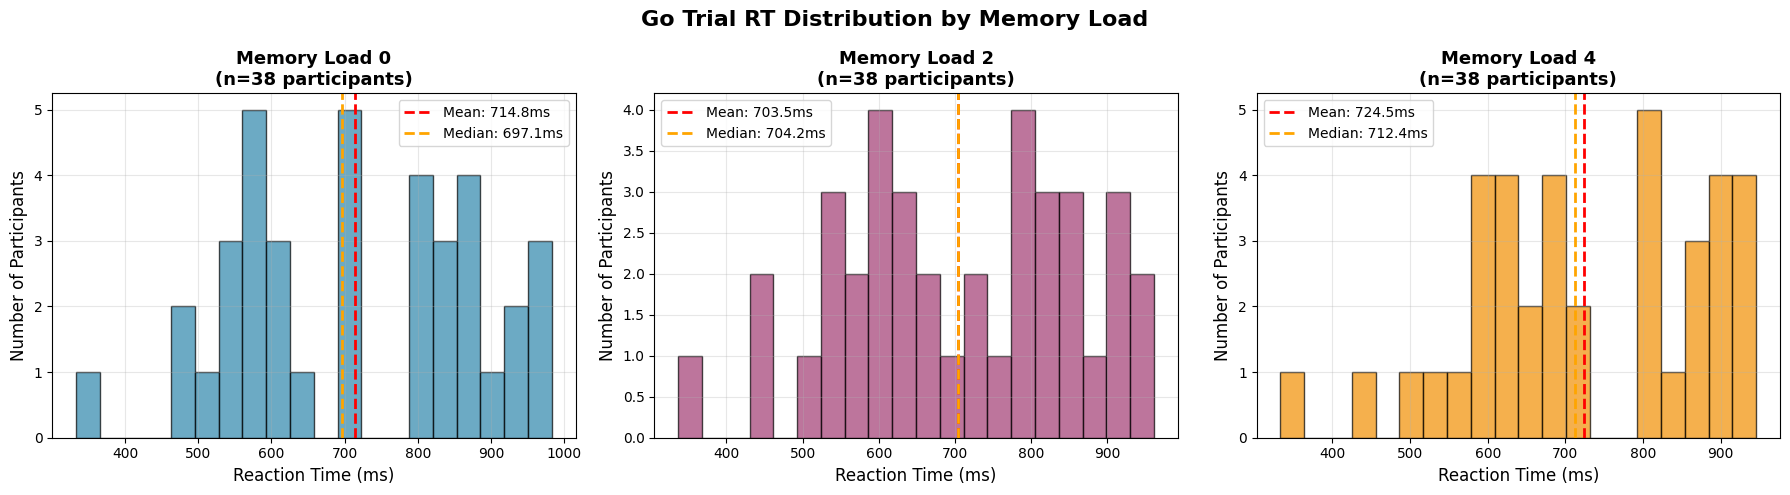


=== Go RT Summary Statistics ===
Memory Load 0: Mean=714.8ms, SD=166.1ms, Median=697.1ms, Range=[332.9, 983.2]ms
Memory Load 2: Mean=703.5ms, SD=158.7ms, Median=704.2ms, Range=[336.6, 961.3]ms
Memory Load 4: Mean=724.5ms, SD=152.7ms, Median=712.4ms, Range=[333.0, 945.7]ms


In [27]:
# Histogram: Go RT by Memory Load
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Go Trial RT Distribution by Memory Load', fontsize=16, fontweight='bold')

colors = ['#2E86AB', '#A23B72', '#F18F01']  # Blue, Purple, Orange
conditions = [
    ('Memory Load 0', 'dual_task_go_wm0_mean_rt', colors[0]),
    ('Memory Load 2', 'dual_task_go_wm2_mean_rt', colors[1]),
    ('Memory Load 4', 'dual_task_go_wm4_mean_rt', colors[2])
]

for idx, (label, column, color) in enumerate(conditions):
    ax = axes[idx]
    data = metrics_data_wm[column].dropna()
    
    # Create histogram
    ax.hist(data, bins=20, alpha=0.7, color=color, edgecolor='black')
    
    # Add mean and median lines
    mean_val = data.mean()
    median_val = data.median()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {mean_val:.1f}ms')
    ax.axvline(median_val, color='orange', linestyle='--', linewidth=2, 
               label=f'Median: {median_val:.1f}ms')
    
    ax.set_xlabel('Reaction Time (ms)', fontsize=12)
    ax.set_ylabel('Number of Participants', fontsize=12)
    ax.set_title(f'{label}\n(n={len(data)} participants)', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n=== Go RT Summary Statistics ===")
for label, column, _ in conditions:
    data = metrics_data_wm[column].dropna()
    print(f"{label}: Mean={data.mean():.1f}ms, SD={data.std():.1f}ms, "
          f"Median={data.median():.1f}ms, Range=[{data.min():.1f}, {data.max():.1f}]ms")


## 4. Go RT: Simple Stop Signal vs Memory Task

Comparison of Go trial RT distributions between basic stop signal task and memory task conditions.

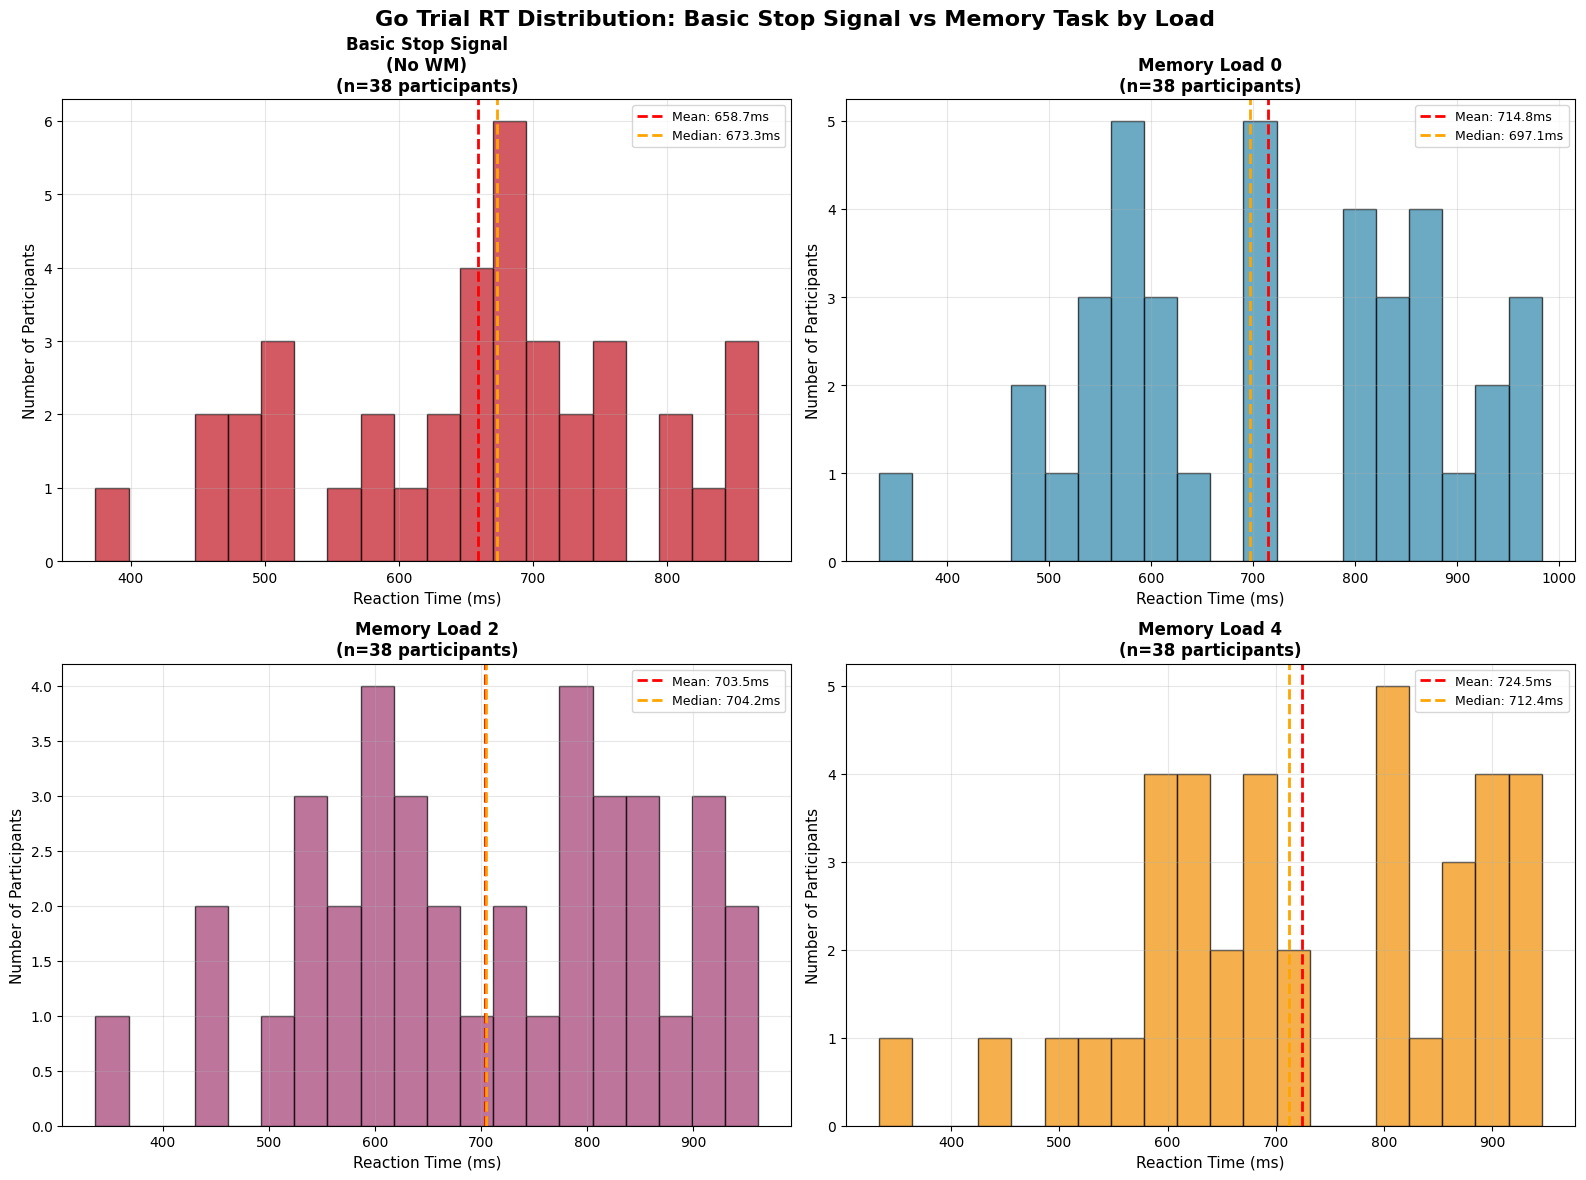


=== Go RT Summary Statistics: Basic Stop Signal vs Memory Task ===
Basic Stop Signal
(No WM): Mean=658.7ms, SD=122.2ms, Median=673.3ms, Range=[373.8, 868.1]ms, n=38
Memory Load 0: Mean=714.8ms, SD=166.1ms, Median=697.1ms, Range=[332.9, 983.2]ms, n=38
Memory Load 2: Mean=703.5ms, SD=158.7ms, Median=704.2ms, Range=[336.6, 961.3]ms, n=38
Memory Load 4: Mean=724.5ms, SD=152.7ms, Median=712.4ms, Range=[333.0, 945.7]ms, n=38

=== RT Cost of Memory Load ===
Memory Load 0 vs Basic Stop Signal: +56.0ms (8.5% increase)
Memory Load 2 vs Basic Stop Signal: +44.8ms (6.8% increase)
Memory Load 4 vs Basic Stop Signal: +65.8ms (10.0% increase)


In [28]:
# Histogram: Compare Basic Stop Signal Go RT with WM Task Go RTs
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Go Trial RT Distribution: Basic Stop Signal vs Memory Task by Load', 
             fontsize=16, fontweight='bold')

colors = ['#C1121F', '#2E86AB', '#A23B72', '#F18F01']  # Red, Blue, Purple, Orange
all_conditions = [
    ('Basic Stop Signal\n(No WM)', 'go_mean_rt', metrics_data_stop, colors[0], axes[0, 0]),
    ('Memory Load 0', 'dual_task_go_wm0_mean_rt', metrics_data_wm, colors[1], axes[0, 1]),
    ('Memory Load 2', 'dual_task_go_wm2_mean_rt', metrics_data_wm, colors[2], axes[1, 0]),
    ('Memory Load 4', 'dual_task_go_wm4_mean_rt', metrics_data_wm, colors[3], axes[1, 1])
]

rt_summary = {}

for label, column, data_source, color, ax in all_conditions:
    data = data_source[column].dropna()
    
    # Create histogram
    ax.hist(data, bins=20, alpha=0.7, color=color, edgecolor='black')
    
    # Add mean and median lines
    mean_val = data.mean()
    median_val = data.median()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {mean_val:.1f}ms')
    ax.axvline(median_val, color='orange', linestyle='--', linewidth=2, 
               label=f'Median: {median_val:.1f}ms')
    
    ax.set_xlabel('Reaction Time (ms)', fontsize=11)
    ax.set_ylabel('Number of Participants', fontsize=11)
    ax.set_title(f'{label}\n(n={len(data)} participants)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Store summary stats
    rt_summary[label] = {
        'mean': mean_val,
        'median': median_val,
        'sd': data.std(),
        'min': data.min(),
        'max': data.max(),
        'n': len(data)
    }

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n=== Go RT Summary Statistics: Basic Stop Signal vs Memory Task ===")
for label, stats in rt_summary.items():
    print(f"{label}: Mean={stats['mean']:.1f}ms, SD={stats['sd']:.1f}ms, "
          f"Median={stats['median']:.1f}ms, Range=[{stats['min']:.1f}, {stats['max']:.1f}]ms, n={stats['n']}")

# Calculate RT cost of WM load
print("\n=== RT Cost of Memory Load ===")
baseline_mean = rt_summary['Basic Stop Signal\n(No WM)']['mean']
for load in ['Memory Load 0', 'Memory Load 2', 'Memory Load 4']:
    cost = rt_summary[load]['mean'] - baseline_mean
    print(f"{load} vs Basic Stop Signal: +{cost:.1f}ms ({cost/baseline_mean*100:.1f}% increase)")


## 5. Stop Signal Delay (SSD) Distributions

SSD distributions by memory load and comparison between basic stop signal and memory task.

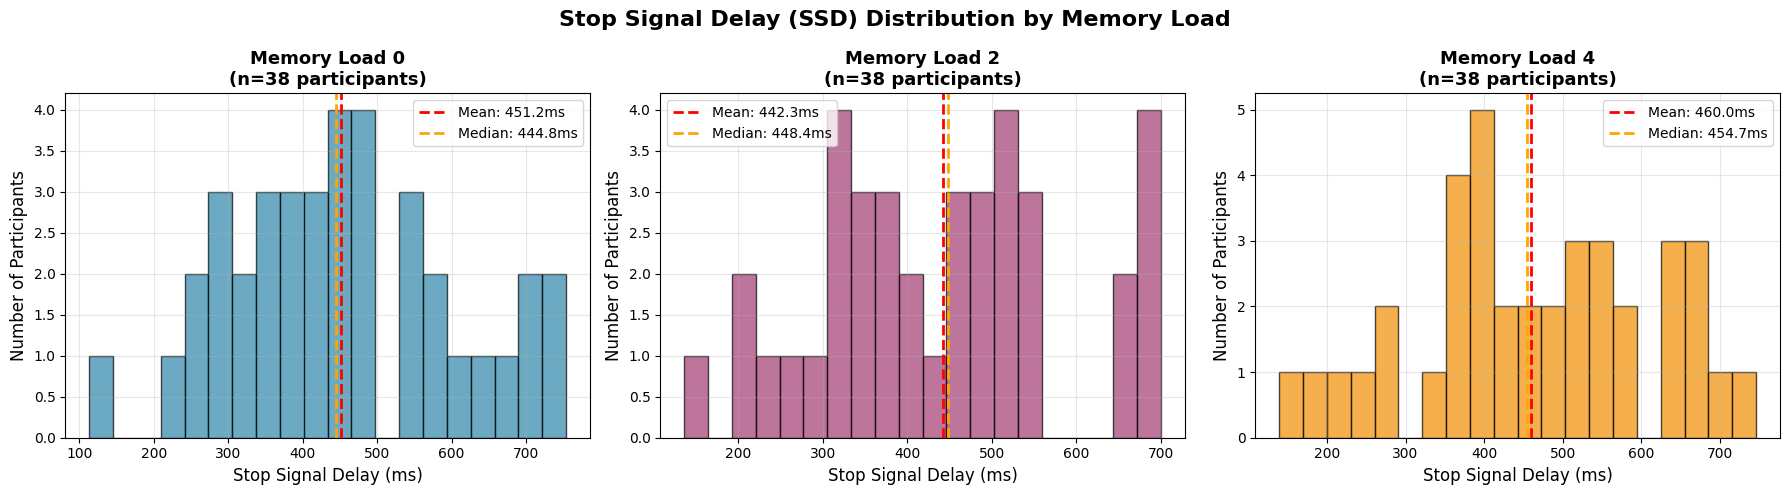


=== SSD Summary Statistics ===
Memory Load 0: Mean=451.2ms, SD=155.4ms, Median=444.8ms, Range=[113.2, 753.8]ms
Memory Load 2: Mean=442.3ms, SD=147.9ms, Median=448.4ms, Range=[135.8, 700.3]ms
Memory Load 4: Mean=460.0ms, SD=152.2ms, Median=454.7ms, Range=[139.2, 745.8]ms


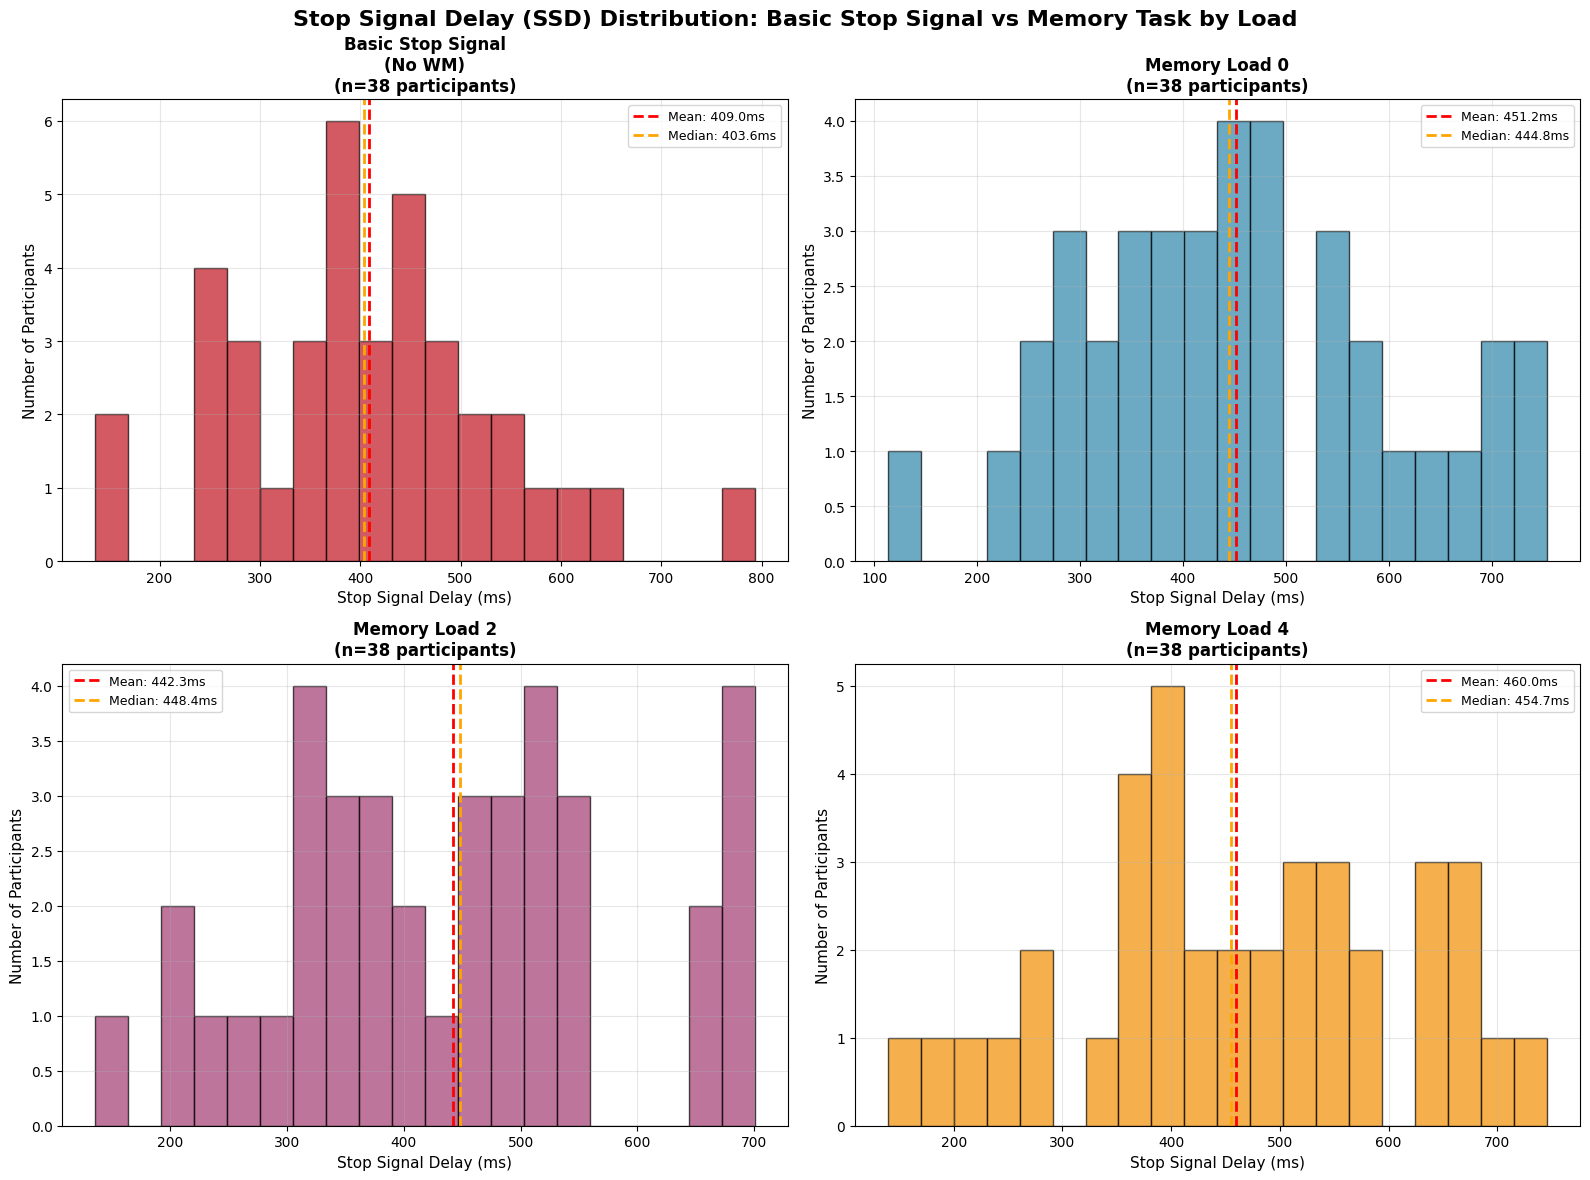


=== SSD Summary Statistics: Basic Stop Signal vs Memory Task ===
Basic Stop Signal
(No WM): Mean=409.0ms, SD=136.2ms, Median=403.6ms, Range=[135.8, 793.1]ms, n=38
Memory Load 0: Mean=451.2ms, SD=155.4ms, Median=444.8ms, Range=[113.2, 753.8]ms, n=38
Memory Load 2: Mean=442.3ms, SD=147.9ms, Median=448.4ms, Range=[135.8, 700.3]ms, n=38
Memory Load 4: Mean=460.0ms, SD=152.2ms, Median=454.7ms, Range=[139.2, 745.8]ms, n=38

=== SSD Difference from Basic Stop Signal ===
Memory Load 0 vs Basic Stop Signal: +42.2ms (+10.3% change)
Memory Load 2 vs Basic Stop Signal: +33.4ms (+8.2% change)
Memory Load 4 vs Basic Stop Signal: +51.0ms (+12.5% change)


In [29]:
# Histogram: SSD (Stop Signal Delay) by Memory Load
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Stop Signal Delay (SSD) Distribution by Memory Load', fontsize=16, fontweight='bold')

colors = ['#2E86AB', '#A23B72', '#F18F01']  # Blue, Purple, Orange
conditions = [
    ('Memory Load 0', 'mean_SSD_wm0', colors[0]),
    ('Memory Load 2', 'mean_SSD_wm2', colors[1]),
    ('Memory Load 4', 'mean_SSD_wm4', colors[2])
]

for idx, (label, column, color) in enumerate(conditions):
    ax = axes[idx]
    data = metrics_data_wm[column].dropna()
    
    # Create histogram
    ax.hist(data, bins=20, alpha=0.7, color=color, edgecolor='black')
    
    # Add mean and median lines
    mean_val = data.mean()
    median_val = data.median()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {mean_val:.1f}ms')
    ax.axvline(median_val, color='orange', linestyle='--', linewidth=2, 
               label=f'Median: {median_val:.1f}ms')
    
    ax.set_xlabel('Stop Signal Delay (ms)', fontsize=12)
    ax.set_ylabel('Number of Participants', fontsize=12)
    ax.set_title(f'{label}\n(n={len(data)} participants)', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n=== SSD Summary Statistics ===")
for label, column, _ in conditions:
    data = metrics_data_wm[column].dropna()
    print(f"{label}: Mean={data.mean():.1f}ms, SD={data.std():.1f}ms, "
          f"Median={data.median():.1f}ms, Range=[{data.min():.1f}, {data.max():.1f}]ms")

# Histogram: Compare Basic Stop Signal SSD with WM Task SSD by Load
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Stop Signal Delay (SSD) Distribution: Basic Stop Signal vs Memory Task by Load', 
             fontsize=16, fontweight='bold')

colors = ['#C1121F', '#2E86AB', '#A23B72', '#F18F01']  # Red, Blue, Purple, Orange
all_conditions = [
    ('Basic Stop Signal\n(No WM)', 'mean_SSD', metrics_data_stop, colors[0], axes[0, 0]),
    ('Memory Load 0', 'mean_SSD_wm0', metrics_data_wm, colors[1], axes[0, 1]),
    ('Memory Load 2', 'mean_SSD_wm2', metrics_data_wm, colors[2], axes[1, 0]),
    ('Memory Load 4', 'mean_SSD_wm4', metrics_data_wm, colors[3], axes[1, 1])
]

ssd_summary = {}

for label, column, data_source, color, ax in all_conditions:
    data = data_source[column].dropna()
    
    # Create histogram
    ax.hist(data, bins=20, alpha=0.7, color=color, edgecolor='black')
    
    # Add mean and median lines
    mean_val = data.mean()
    median_val = data.median()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {mean_val:.1f}ms')
    ax.axvline(median_val, color='orange', linestyle='--', linewidth=2, 
               label=f'Median: {median_val:.1f}ms')
    
    ax.set_xlabel('Stop Signal Delay (ms)', fontsize=11)
    ax.set_ylabel('Number of Participants', fontsize=11)
    ax.set_title(f'{label}\n(n={len(data)} participants)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Store summary stats
    ssd_summary[label] = {
        'mean': mean_val,
        'median': median_val,
        'sd': data.std(),
        'min': data.min(),
        'max': data.max(),
        'n': len(data)
    }

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n=== SSD Summary Statistics: Basic Stop Signal vs Memory Task ===")
for label, stats in ssd_summary.items():
    print(f"{label}: Mean={stats['mean']:.1f}ms, SD={stats['sd']:.1f}ms, "
          f"Median={stats['median']:.1f}ms, Range=[{stats['min']:.1f}, {stats['max']:.1f}]ms, n={stats['n']}")

# Calculate SSD difference from baseline
print("\n=== SSD Difference from Basic Stop Signal ===")
baseline_mean = ssd_summary['Basic Stop Signal\n(No WM)']['mean']
for load in ['Memory Load 0', 'Memory Load 2', 'Memory Load 4']:
    diff = ssd_summary[load]['mean'] - baseline_mean
    print(f"{load} vs Basic Stop Signal: {diff:+.1f}ms ({diff/baseline_mean*100:+.1f}% change)")


## 5. Simple Stop Signal vs Memory Task Go Accuracy by Load

Compare GO trial accuracy between the simple stop signal task (baseline) and the WM task across different load levels, with a horizontal line indicating the simple stop signal baseline mean.

Participants with complete data for both tasks: 38



/var/folders/4n/6xdj3h3x4v94vpyhm5330k280000gn/T/ipykernel_77513/576022261.py:73: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=11, loc='lower left')


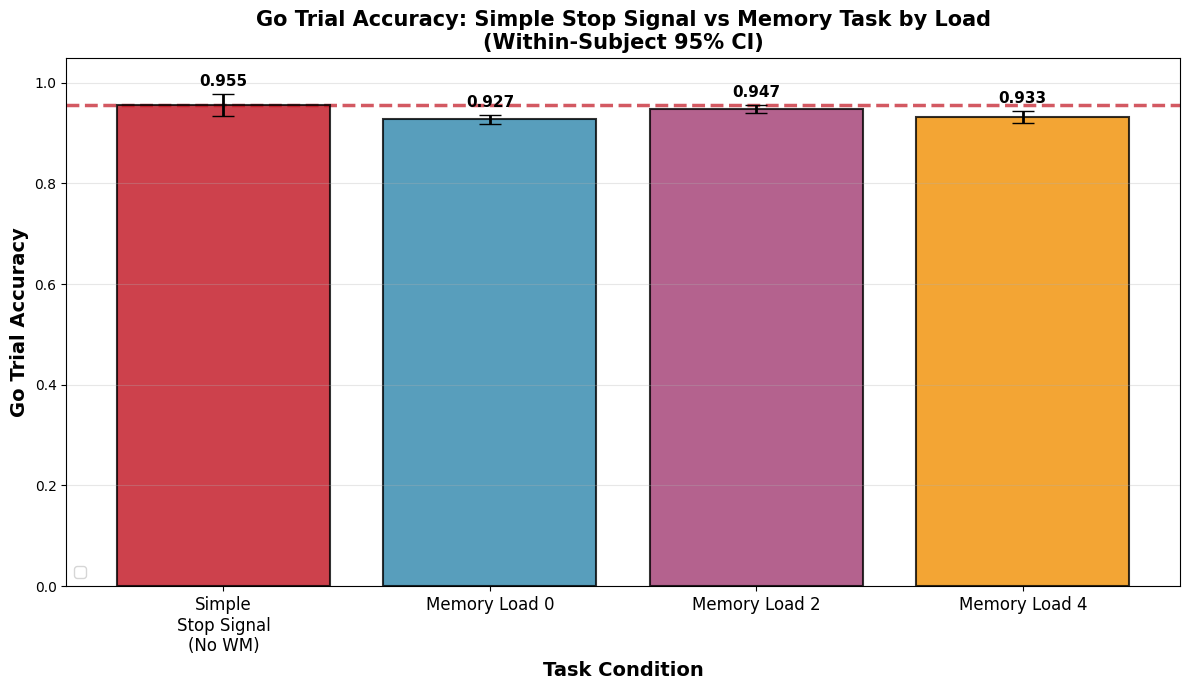


=== Go Trial Accuracy Summary (n=38 participants) ===

Descriptive Statistics:
  Simple Stop Signal (No WM): M=0.955 ± 0.022 (within-subject CI), SD=0.062
  Memory Load 0: M=0.927 ± 0.010 (within-subject CI), SD=0.069
  Memory Load 2: M=0.947 ± 0.008 (within-subject CI), SD=0.061
  Memory Load 4: M=0.933 ± 0.012 (within-subject CI), SD=0.072


In [30]:
# Bar plot comparing Simple Stop Signal GO Accuracy with WM Task GO Accuracy by Load
fig, ax = plt.subplots(1, 1, figsize=(12, 7))

# Find participants with data for both tasks
participants_both = list(set(metrics_data_stop['prolific_id']) & set(metrics_data_wm['prolific_id']))

# Filter for participants with complete data
stop_data = metrics_data_stop[metrics_data_stop['prolific_id'].isin(participants_both)]
stop_data = stop_data.dropna(subset=['go_choice_accuracy'])

wm_data = metrics_data_wm[metrics_data_wm['prolific_id'].isin(participants_both)]
wm_data = wm_data.dropna(subset=[
    'dual_task_go_wm0_choice_accuracy', 'dual_task_go_wm2_choice_accuracy', 'dual_task_go_wm4_choice_accuracy'
])

# Get overlapping participants
common_participants = list(set(stop_data['prolific_id']) & set(wm_data['prolific_id']))
stop_data_filtered = stop_data[stop_data['prolific_id'].isin(common_participants)]
wm_data_filtered = wm_data[wm_data['prolific_id'].isin(common_participants)]

print(f"Participants with complete data for both tasks: {len(common_participants)}\n")

# Prepare data for within-subject CI calculation
# Need to align participants and create a matrix with all conditions
stop_data_filtered = stop_data_filtered.set_index('prolific_id')
wm_data_filtered = wm_data_filtered.set_index('prolific_id')

# Create data matrix for within-subject CIs (participants x conditions)
accuracy_matrix = pd.DataFrame({
    'Simple_Stop': stop_data_filtered['go_choice_accuracy'],
    'WM_Load_0': wm_data_filtered['dual_task_go_wm0_choice_accuracy'],
    'WM_Load_2': wm_data_filtered['dual_task_go_wm2_choice_accuracy'],
    'WM_Load_4': wm_data_filtered['dual_task_go_wm4_choice_accuracy']
})

# Calculate within-subject CIs
all_cis = calculate_within_subject_ci(accuracy_matrix)

# Calculate means for each condition
all_means = np.array([
    accuracy_matrix['Simple_Stop'].mean(),
    accuracy_matrix['WM_Load_0'].mean(),
    accuracy_matrix['WM_Load_2'].mean(),
    accuracy_matrix['WM_Load_4'].mean()
])

# Store simple stop mean for reference line
simple_stop_mean = all_means[0]

# Set up bar positions and colors
conditions = ['Simple\nStop Signal\n(No WM)', 'Memory Load 0', 'Memory Load 2', 'Memory Load 4']
x_pos = np.arange(len(conditions))
colors = ['#C1121F', '#2E86AB', '#A23B72', '#F18F01']  # Red for baseline, then blue/purple/orange

# Create bar plot
bars = ax.bar(x_pos, all_means, yerr=all_cis, capsize=8,
              alpha=0.8, color=colors, edgecolor='black', linewidth=1.5,
              error_kw={'linewidth': 2, 'ecolor': 'black'})

# Add horizontal line for simple stop signal mean
ax.axhline(y=simple_stop_mean, color='#C1121F', linestyle='--', linewidth=2.5, 
           alpha=0.7, zorder=0)

# Formatting
ax.set_xlabel('Task Condition', fontsize=14, fontweight='bold')
ax.set_ylabel('Go Trial Accuracy', fontsize=14, fontweight='bold')
ax.set_title('Go Trial Accuracy: Simple Stop Signal vs Memory Task by Load\n(Within-Subject 95% CI)', 
             fontsize=15, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(conditions, fontsize=12)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3, axis='y')
ax.legend(fontsize=11, loc='lower left')

# Add value labels on bars
for i, (bar, mean, ci) in enumerate(zip(bars, all_means, all_cis)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2., height + ci + 0.01,
            f'{mean:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n=== Go Trial Accuracy Summary (n={len(common_participants)} participants) ===")
print("\nDescriptive Statistics:")
for i, condition in enumerate(conditions):
    condition_key = ['Simple_Stop', 'WM_Load_0', 'WM_Load_2', 'WM_Load_4'][i]
    print(f"  {condition.replace(chr(10), ' ')}: M={all_means[i]:.3f} ± {all_cis[i]:.3f} (within-subject CI), SD={accuracy_matrix[condition_key].std():.3f}")


## 6. Simple Stop Signal vs Memory Task GO RT by Load

Compare GO trial reaction times between the simple stop signal task (baseline) and the WM task across different load levels, with a horizontal line indicating the simple stop signal baseline mean.

Participants with complete data for both tasks: 38



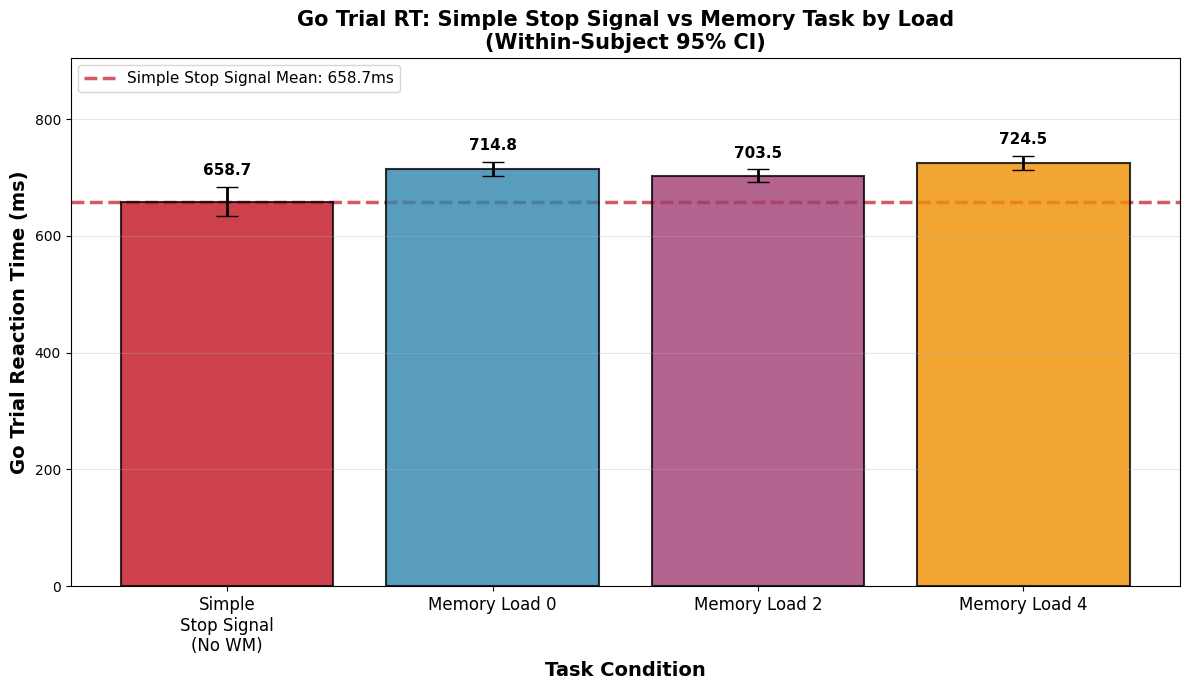


=== GO RT Comparison Summary (n=38 participants) ===

Simple Stop Signal (No WM): 658.7ms ± 25.0ms (within-subject 95% CI)
WM Load 0: 714.8ms ± 12.6ms (within-subject 95% CI)
WM Load 2: 703.5ms ± 10.7ms (within-subject 95% CI)
WM Load 4: 724.5ms ± 12.1ms (within-subject 95% CI)

=== RT Cost relative to Simple Stop Signal ===
WM Load 0: +56.0ms (8.5%)
WM Load 2: +44.8ms (6.8%)
WM Load 4: +65.8ms (10.0%)


In [31]:
# Bar plot comparing Simple Stop Signal GO RT with WM Task GO RT by Load
fig, ax = plt.subplots(1, 1, figsize=(12, 7))

# Find participants with data for both tasks
participants_both = list(set(metrics_data_stop['prolific_id']) & set(metrics_data_wm['prolific_id']))

# Filter for participants with complete data
stop_data = metrics_data_stop[metrics_data_stop['prolific_id'].isin(participants_both)]
stop_data = stop_data.dropna(subset=['go_mean_rt'])

wm_data = metrics_data_wm[metrics_data_wm['prolific_id'].isin(participants_both)]
wm_data = wm_data.dropna(subset=[
    'dual_task_go_wm0_mean_rt', 'dual_task_go_wm2_mean_rt', 'dual_task_go_wm4_mean_rt'
])

# Get overlapping participants
common_participants = list(set(stop_data['prolific_id']) & set(wm_data['prolific_id']))
stop_data_filtered = stop_data[stop_data['prolific_id'].isin(common_participants)]
wm_data_filtered = wm_data[wm_data['prolific_id'].isin(common_participants)]

print(f"Participants with complete data for both tasks: {len(common_participants)}\n")

# Prepare data for within-subject CI calculation
# Need to align participants and create a matrix with all conditions
stop_data_filtered = stop_data_filtered.set_index('prolific_id')
wm_data_filtered = wm_data_filtered.set_index('prolific_id')

# Create data matrix for within-subject CIs (participants x conditions)
rt_matrix = pd.DataFrame({
    'Simple_Stop': stop_data_filtered['go_mean_rt'],
    'WM_Load_0': wm_data_filtered['dual_task_go_wm0_mean_rt'],
    'WM_Load_2': wm_data_filtered['dual_task_go_wm2_mean_rt'],
    'WM_Load_4': wm_data_filtered['dual_task_go_wm4_mean_rt']
})

# Calculate within-subject CIs
all_cis = calculate_within_subject_ci(rt_matrix)

# Calculate means for each condition
all_means = np.array([
    rt_matrix['Simple_Stop'].mean(),
    rt_matrix['WM_Load_0'].mean(),
    rt_matrix['WM_Load_2'].mean(),
    rt_matrix['WM_Load_4'].mean()
])

# Store simple stop mean for reference line
simple_stop_mean = all_means[0]

# Set up bar positions and colors
conditions = ['Simple\nStop Signal\n(No WM)', 'Memory Load 0', 'Memory Load 2', 'Memory Load 4']
x_pos = np.arange(len(conditions))
colors = ['#C1121F', '#2E86AB', '#A23B72', '#F18F01']  # Red for baseline, then blue/purple/orange

# all_means and all_cis are already calculated above with within-subject CIs

# Create bar plot
bars = ax.bar(x_pos, all_means, yerr=all_cis, capsize=8,
              alpha=0.8, color=colors, edgecolor='black', linewidth=1.5,
              error_kw={'linewidth': 2, 'ecolor': 'black'})

# Add horizontal line for simple stop signal mean
ax.axhline(y=simple_stop_mean, color='#C1121F', linestyle='--', linewidth=2.5, 
           alpha=0.7, label=f'Simple Stop Signal Mean: {simple_stop_mean:.1f}ms', zorder=0)

# Formatting
ax.set_xlabel('Task Condition', fontsize=14, fontweight='bold')
ax.set_ylabel('Go Trial Reaction Time (ms)', fontsize=14, fontweight='bold')
ax.set_title('Go Trial RT: Simple Stop Signal vs Memory Task by Load\n(Within-Subject 95% CI)', 
             fontsize=15, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(conditions, fontsize=12)
ax.set_ylim(0, max(all_means) * 1.25)
ax.grid(True, alpha=0.3, axis='y')
ax.legend(fontsize=11, loc='upper left')

# Add value labels on bars
for i, (bar, mean, ci) in enumerate(zip(bars, all_means, all_cis)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2., height + ci + 15,
            f'{mean:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\n=== GO RT Comparison Summary (n={len(common_participants)} participants) ===\n")
print(f"Simple Stop Signal (No WM): {all_means[0]:.1f}ms ± {all_cis[0]:.1f}ms (within-subject 95% CI)")
print(f"WM Load 0: {all_means[1]:.1f}ms ± {all_cis[1]:.1f}ms (within-subject 95% CI)")
print(f"WM Load 2: {all_means[2]:.1f}ms ± {all_cis[2]:.1f}ms (within-subject 95% CI)")
print(f"WM Load 4: {all_means[3]:.1f}ms ± {all_cis[3]:.1f}ms (within-subject 95% CI)")

print(f"\n=== RT Cost relative to Simple Stop Signal ===")
print(f"WM Load 0: +{all_means[1] - simple_stop_mean:.1f}ms ({(all_means[1] - simple_stop_mean)/simple_stop_mean*100:.1f}%)")
print(f"WM Load 2: +{all_means[2] - simple_stop_mean:.1f}ms ({(all_means[2] - simple_stop_mean)/simple_stop_mean*100:.1f}%)")
print(f"WM Load 4: +{all_means[3] - simple_stop_mean:.1f}ms ({(all_means[3] - simple_stop_mean)/simple_stop_mean*100:.1f}%)")


## 7. Probe Response RT by Memory Load

Analyze probe (memory recognition) response times across different WM load levels.

Participants with complete probe RT data: 38



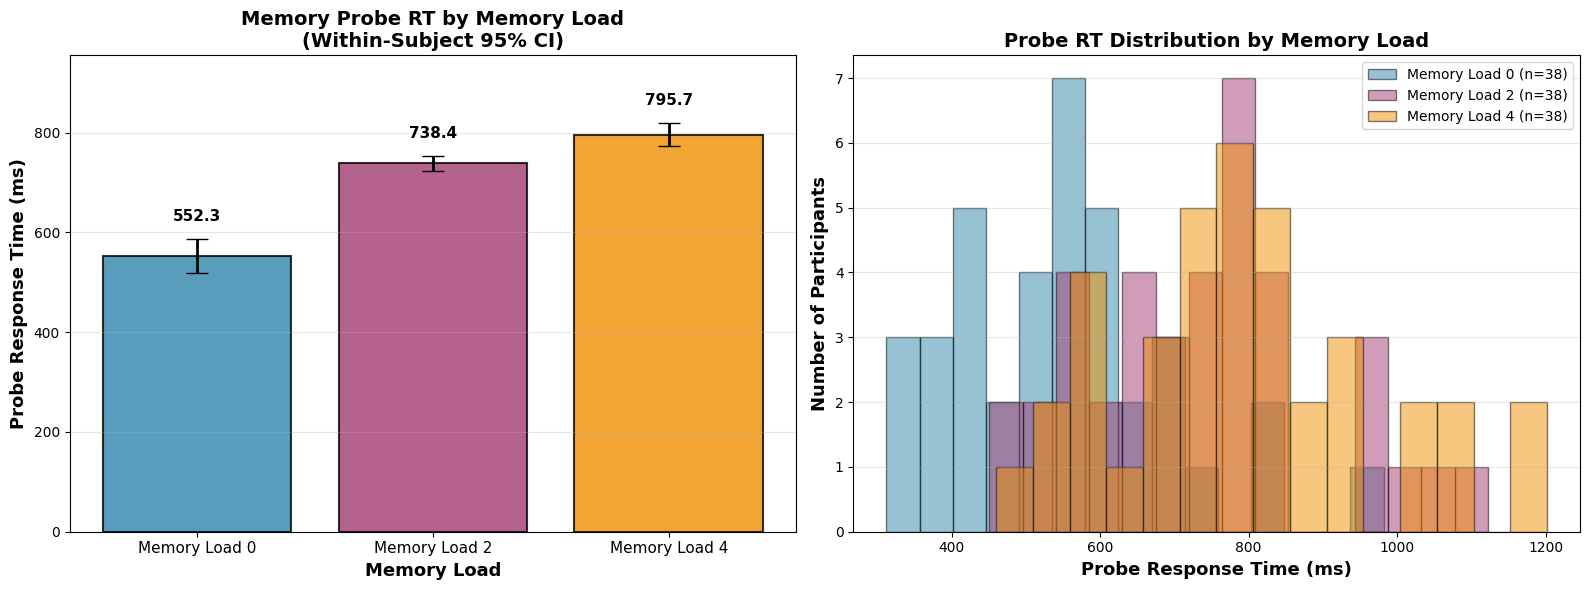

=== Probe RT Summary Statistics ===
Memory Load 0: 552.3ms ± 34.3ms (within-subject CI)
  SD=149.1ms, Range=[311.9, 981.9]ms, n=38
Memory Load 2: 738.4ms ± 15.6ms (within-subject CI)
  SD=159.1ms, Range=[450.7, 1122.3]ms, n=38
Memory Load 4: 795.7ms ± 23.1ms (within-subject CI)
  SD=176.3ms, Range=[459.6, 1202.0]ms, n=38

=== Probe RT Increase by Memory Load ===
Memory Load 2 vs Memory Load 0: +186.0ms (33.7% increase)
Memory Load 4 vs Memory Load 0: +243.4ms (44.1% increase)


In [32]:
# Probe RT Analysis by Memory Load
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Get participants with complete probe data
complete_probe_data = metrics_data_wm.dropna(subset=[
    'probe_wm0_mean_rt',
    'probe_wm2_mean_rt',
    'probe_wm4_mean_rt'
])

print(f"Participants with complete probe RT data: {len(complete_probe_data)}\n")

# Prepare data matrix for within-subject CI calculation
probe_rt_matrix = complete_probe_data[[
    'probe_wm0_mean_rt',
    'probe_wm2_mean_rt',
    'probe_wm4_mean_rt'
]]

# Calculate within-subject CIs
probe_rt_cis = calculate_within_subject_ci(probe_rt_matrix)

# Calculate means
probe_rt_means = np.array([
    probe_rt_matrix.iloc[:, 0].mean(),
    probe_rt_matrix.iloc[:, 1].mean(),
    probe_rt_matrix.iloc[:, 2].mean()
])

conditions = ['Memory Load 0', 'Memory Load 2', 'Memory Load 4']
x_pos = np.arange(len(conditions))
colors = ['#2E86AB', '#A23B72', '#F18F01']

# === BAR PLOT WITH WITHIN-SUBJECT CIs ===
ax1 = axes[0]
bars = ax1.bar(x_pos, probe_rt_means, yerr=probe_rt_cis, capsize=8,
               alpha=0.8, color=colors, edgecolor='black', linewidth=1.5,
               error_kw={'linewidth': 2, 'ecolor': 'black'})

ax1.set_xlabel('Memory Load', fontsize=13, fontweight='bold')
ax1.set_ylabel('Probe Response Time (ms)', fontsize=13, fontweight='bold')
ax1.set_title('Memory Probe RT by Memory Load\n(Within-Subject 95% CI)', 
              fontsize=14, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(conditions, fontsize=11)
ax1.set_ylim(0, max(probe_rt_means) * 1.2)
ax1.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, mean, ci) in enumerate(zip(bars, probe_rt_means, probe_rt_cis)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2., height + ci + 30,
             f'{mean:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# === HISTOGRAM OF PROBE RTs BY LOAD ===
ax2 = axes[1]

probe_data = [
    metrics_data_wm['probe_wm0_mean_rt'].dropna(),
    metrics_data_wm['probe_wm2_mean_rt'].dropna(),
    metrics_data_wm['probe_wm4_mean_rt'].dropna()
]

# Create overlapping histograms
for i, (data, color, label) in enumerate(zip(probe_data, colors, conditions)):
    ax2.hist(data, bins=15, alpha=0.5, color=color, edgecolor='black', 
             label=f'{label} (n={len(data)})', density=False)

ax2.set_xlabel('Probe Response Time (ms)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Number of Participants', fontsize=13, fontweight='bold')
ax2.set_title('Probe RT Distribution by Memory Load', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print summary statistics
print("=== Probe RT Summary Statistics ===")
for i, condition in enumerate(conditions):
    mean = probe_rt_means[i]
    ci = probe_rt_cis[i]
    data = probe_data[i]
    print(f"{condition}: {mean:.1f}ms ± {ci:.1f}ms (within-subject CI)")
    print(f"  SD={data.std():.1f}ms, Range=[{data.min():.1f}, {data.max():.1f}]ms, n={len(data)}")

# Calculate probe RT increase from load
print("\n=== Probe RT Increase by Memory Load ===")
baseline_probe = probe_rt_means[0]
for i in range(1, len(conditions)):
    increase = probe_rt_means[i] - baseline_probe
    percent = (increase / baseline_probe) * 100
    print(f"{conditions[i]} vs {conditions[0]}: +{increase:.1f}ms ({percent:.1f}% increase)")


## 8. Probe Response Accuracy by Memory Load

Analyze probe (memory recognition) accuracy across different WM load levels.

Participants with complete probe accuracy data: 38



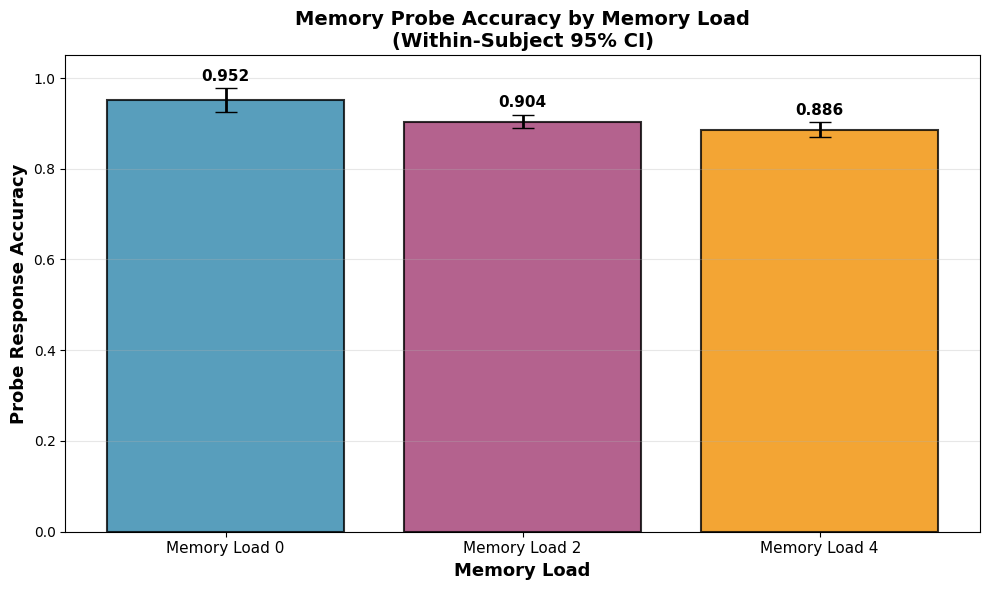

=== Probe Accuracy Summary Statistics ===
Memory Load 0: 0.952 ± 0.026 (within-subject CI)
  SD=0.079, Range=[0.694, 1.000], n=38
Memory Load 2: 0.904 ± 0.015 (within-subject CI)
  SD=0.090, Range=[0.674, 0.979], n=38
Memory Load 4: 0.886 ± 0.016 (within-subject CI)
  SD=0.100, Range=[0.646, 0.986], n=38

=== Probe Accuracy Decline by Memory Load ===
Memory Load 2 vs Memory Load 0: -0.048 (-5.0%)
Memory Load 4 vs Memory Load 0: -0.066 (-6.9%)


In [33]:
# Probe Accuracy Analysis by Memory Load
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Get participants with complete probe accuracy data
complete_probe_acc_data = metrics_data_wm.dropna(subset=[
    'probe_wm0_response_accuracy',
    'probe_wm2_response_accuracy',
    'probe_wm4_response_accuracy'
])

print(f"Participants with complete probe accuracy data: {len(complete_probe_acc_data)}\n")

# Prepare data matrix for within-subject CI calculation
probe_acc_matrix = complete_probe_acc_data[[
    'probe_wm0_response_accuracy',
    'probe_wm2_response_accuracy',
    'probe_wm4_response_accuracy'
]]

# Calculate within-subject CIs
probe_acc_cis = calculate_within_subject_ci(probe_acc_matrix)

# Calculate means
probe_acc_means = np.array([
    probe_acc_matrix.iloc[:, 0].mean(),
    probe_acc_matrix.iloc[:, 1].mean(),
    probe_acc_matrix.iloc[:, 2].mean()
])

conditions = ['Memory Load 0', 'Memory Load 2', 'Memory Load 4']
x_pos = np.arange(len(conditions))
colors = ['#2E86AB', '#A23B72', '#F18F01']

# === BAR PLOT WITH WITHIN-SUBJECT CIs ===
bars = ax.bar(x_pos, probe_acc_means, yerr=probe_acc_cis, capsize=8,
              alpha=0.8, color=colors, edgecolor='black', linewidth=1.5,
              error_kw={'linewidth': 2, 'ecolor': 'black'})

ax.set_xlabel('Memory Load', fontsize=13, fontweight='bold')
ax.set_ylabel('Probe Response Accuracy', fontsize=13, fontweight='bold')
ax.set_title('Memory Probe Accuracy by Memory Load\n(Within-Subject 95% CI)', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(conditions, fontsize=11)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, mean, ci) in enumerate(zip(bars, probe_acc_means, probe_acc_cis)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2., height + ci + 0.01,
            f'{mean:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary statistics
print("=== Probe Accuracy Summary Statistics ===")
for i, condition in enumerate(conditions):
    mean = probe_acc_means[i]
    ci = probe_acc_cis[i]
    data = metrics_data_wm[f'probe_wm{[0,2,4][i]}_response_accuracy'].dropna()
    print(f"{condition}: {mean:.3f} ± {ci:.3f} (within-subject CI)")
    print(f"  SD={data.std():.3f}, Range=[{data.min():.3f}, {data.max():.3f}], n={len(data)}")

# Calculate accuracy decline from load
print("\n=== Probe Accuracy Decline by Memory Load ===")
baseline_acc = probe_acc_means[0]
for i in range(1, len(conditions)):
    decline = probe_acc_means[i] - baseline_acc
    percent = (decline / baseline_acc) * 100
    print(f"{conditions[i]} vs {conditions[0]}: {decline:+.3f} ({percent:+.1f}%)")


## 9. SSRT (Stop Signal Reaction Time) by Memory Load

Analyze SSRT across simple stop signal task and WM task by load level. SSRT = Mean Go RT - Mean SSD, representing the time required to inhibit a response.

Bar plot uses within-subject 95% CIs (Cousineau–Morey). Pairwise comparisons use Bonferroni-corrected paired *t*-tests (same logic as `analysis_notebook.ipynb`, Section 7). Bayes factor BF₁₀ is from ΔBIC (null vs. full condition means) via `stop_wm.bic_bayes`, matching the SSRT BIC block in the analysis notebook.

Participants with complete SSRT data for both tasks: 38



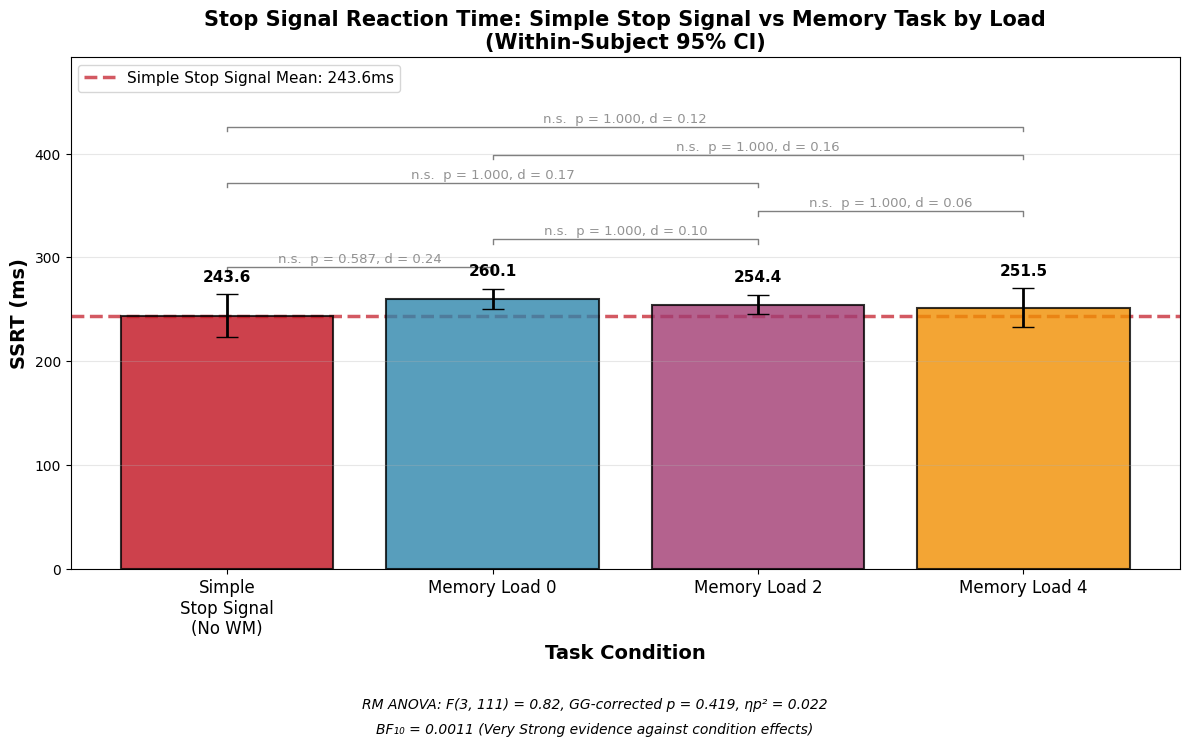


=== SSRT Comparison Summary (n=38 participants) ===

Simple Stop Signal (No WM): 243.6ms ± 20.6ms (within-subject 95% CI)
WM Load 0: 260.1ms ± 9.4ms (within-subject 95% CI)
WM Load 2: 254.4ms ± 9.0ms (within-subject 95% CI)
WM Load 4: 251.5ms ± 18.5ms (within-subject 95% CI)

=== SSRT Change relative to Simple Stop Signal ===
WM Load 0: +16.4ms (+6.7%)
WM Load 2: +10.8ms (+4.4%)
WM Load 4: +7.8ms (+3.2%)

=== SSRT Change across WM Loads ===
WM Load 2 vs WM Load 0: -5.6ms (-2.2%)
WM Load 4 vs WM Load 0: -8.6ms (-3.3%)
WM Load 4 vs WM Load 2: -3.0ms (-1.2%)


In [34]:
# SSRT Comparison: Simple Stop Signal vs Memory Task by Load
fig, ax = plt.subplots(1, 1, figsize=(12, 7))

# Find participants with data for both tasks
participants_both = list(set(metrics_data_stop['prolific_id']) & set(metrics_data_wm['prolific_id']))

# Filter for participants with complete SSRT data
stop_data = metrics_data_stop[metrics_data_stop['prolific_id'].isin(participants_both)]
stop_data = stop_data.dropna(subset=['SSRT'])

wm_data = metrics_data_wm[metrics_data_wm['prolific_id'].isin(participants_both)]
wm_data = wm_data.dropna(subset=['SSRT_wm0', 'SSRT_wm2', 'SSRT_wm4'])

# Get overlapping participants
common_participants = list(set(stop_data['prolific_id']) & set(wm_data['prolific_id']))
stop_data_filtered = stop_data[stop_data['prolific_id'].isin(common_participants)]
wm_data_filtered = wm_data[wm_data['prolific_id'].isin(common_participants)]

print(f"Participants with complete SSRT data for both tasks: {len(common_participants)}\n")

# Prepare data for within-subject CI calculation
# Need to align participants and create a matrix with all conditions
stop_data_filtered = stop_data_filtered.set_index('prolific_id')
wm_data_filtered = wm_data_filtered.set_index('prolific_id')

# Create data matrix for within-subject CIs (participants x conditions)
ssrt_matrix = pd.DataFrame({
    'Simple_Stop': stop_data_filtered['SSRT'],
    'WM_Load_0': wm_data_filtered['SSRT_wm0'],
    'WM_Load_2': wm_data_filtered['SSRT_wm2'],
    'WM_Load_4': wm_data_filtered['SSRT_wm4']
})

# Calculate within-subject CIs
all_cis = np.asarray(calculate_within_subject_ci(ssrt_matrix), dtype=float)

# Calculate means for each condition
all_means = np.array([
    ssrt_matrix['Simple_Stop'].mean(),
    ssrt_matrix['WM_Load_0'].mean(),
    ssrt_matrix['WM_Load_2'].mean(),
    ssrt_matrix['WM_Load_4'].mean()
])

# Store simple stop mean for reference line
simple_stop_mean = all_means[0]

# Set up bar positions and colors
conditions = ['Simple\nStop Signal\n(No WM)', 'Memory Load 0', 'Memory Load 2', 'Memory Load 4']
x_pos = np.arange(len(conditions))
colors = ['#C1121F', '#2E86AB', '#A23B72', '#F18F01']  # Red for baseline, then blue/purple/orange

# all_means and all_cis are already calculated above with within-subject CIs

# Create bar plot
bars = ax.bar(x_pos, all_means, yerr=all_cis, capsize=8,
              alpha=0.8, color=colors, edgecolor='black', linewidth=1.5,
              error_kw={'linewidth': 2, 'ecolor': 'black'})

# Add horizontal line for simple stop signal mean
ax.axhline(y=simple_stop_mean, color='#C1121F', linestyle='--', linewidth=2.5, 
           alpha=0.7, label=f'Simple Stop Signal Mean: {simple_stop_mean:.1f}ms', zorder=0)

# Formatting
ax.set_xlabel('Task Condition', fontsize=14, fontweight='bold')
ax.set_ylabel('SSRT (ms)', fontsize=14, fontweight='bold')
ax.set_title('Stop Signal Reaction Time: Simple Stop Signal vs Memory Task by Load\n(Within-Subject 95% CI)', 
             fontsize=15, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(conditions, fontsize=12)
ax.set_ylim(0, max(all_means) * 1.3)
ax.grid(True, alpha=0.3, axis='y')
ax.legend(fontsize=11, loc='upper left')

# Add value labels on bars
for i, (bar, mean, ci) in enumerate(zip(bars, all_means, all_cis)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2., height + ci + 10,
            f'{mean:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# === SIGNIFICANCE ANNOTATIONS (Bonferroni-corrected paired t-tests) ===
n_subj = len(ssrt_matrix)
cond_labels = ['Simple', 'WM0', 'WM2', 'WM4']
df_long_sig = pd.DataFrame({
    'subject': list(range(n_subj)) * 4,
    'condition': cond_labels[0:1] * n_subj + cond_labels[1:2] * n_subj + cond_labels[2:3] * n_subj + cond_labels[3:4] * n_subj,
    'ssrt': np.concatenate([ssrt_matrix.iloc[:, c].values for c in range(4)])
})
bar_tops = all_means + all_cis
annotate_pairwise_bonferroni_brackets(
    ax, df_long_sig, dv='ssrt', within='condition', subject='subject',
    x_positions=x_pos, bar_tops=bar_tops, show_nonsignificant=True)

# === Omnibus RM ANOVA (matches analysis_notebook: GG p if sphericity violated) ===
n_subj_rm = len(ssrt_matrix)
subj_rm = ssrt_matrix.index.astype(str).tolist()
df_long_rm = pd.DataFrame({
    'subject': subj_rm * 4,
    'condition': ['Simple'] * n_subj_rm + ['WM0'] * n_subj_rm + ['WM2'] * n_subj_rm + ['WM4'] * n_subj_rm,
    'ssrt': np.concatenate([ssrt_matrix.iloc[:, c].values for c in range(4)])
})
aov_rm = pg.rm_anova(data=df_long_rm, dv='ssrt', within='condition', subject='subject', detailed=True)
spher_rm = pg.sphericity(data=df_long_rm, dv='ssrt', within='condition', subject='subject')
p_rm = float(aov_rm['p_GG_corr'].values[0]) if spher_rm.pval < 0.05 else float(aov_rm['p_unc'].values[0])
f_rm = float(aov_rm['F'].values[0])
df1_rm = float(aov_rm['DF'].values[0])
df2_rm = float(aov_rm['DF'].values[1])
ss_eff = float(aov_rm['SS'].values[0])
ss_err = float(aov_rm['SS'].values[1])
np2_rm = ss_eff / (ss_eff + ss_err)
if spher_rm.pval < 0.05:
    p_part = 'GG-corrected p < .001' if p_rm < 0.001 else f'GG-corrected p = {p_rm:.3f}'
else:
    p_part = 'p < .001' if p_rm < 0.001 else f'p = {p_rm:.3f}'
rm_line = (
    f'RM ANOVA: F({df1_rm:.0f}, {df2_rm:.0f}) = {f_rm:.2f}, {p_part}, '
    f'\u03b7p\u00b2 = {np2_rm:.3f}'
)

# === BF₁₀ (ΔBIC, same specification as analysis notebook SSRT BIC block) ===
n_conditions_bf = 4
ssrt_data_bf = ssrt_matrix.values
n_obs_bf = ssrt_data_bf.size
grand_mean_bf = np.mean(ssrt_data_bf)
residuals_null_bf = ssrt_data_bf.flatten() - grand_mean_bf
bic_null_bf = calculate_bic(residuals_null_bf, 1, n_obs_bf)
condition_means_bf = np.mean(ssrt_data_bf, axis=0)
residuals_full_bf = (ssrt_data_bf - condition_means_bf).flatten()
bic_full_bf = calculate_bic(residuals_full_bf, n_conditions_bf, n_obs_bf)
delta_bic_bf = bic_null_bf - bic_full_bf
bf10_val = calculate_bf10(delta_bic_bf)
bf10_interp = interpret_bic_delta(delta_bic_bf)
bf_line = f'BF\u2081\u2080 = {bf10_val:.4f} ({bf10_interp})'
fig.text(0.5, -0.02, rm_line, ha='center', fontsize=10, style='italic', transform=fig.transFigure)
fig.text(0.5, -0.055, bf_line, ha='center', fontsize=10, style='italic', transform=fig.transFigure)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.show()

# Print summary statistics
print(f"\n=== SSRT Comparison Summary (n={len(common_participants)} participants) ===\n")
print(f"Simple Stop Signal (No WM): {all_means[0]:.1f}ms ± {all_cis[0]:.1f}ms (within-subject 95% CI)")
print(f"WM Load 0: {all_means[1]:.1f}ms ± {all_cis[1]:.1f}ms (within-subject 95% CI)")
print(f"WM Load 2: {all_means[2]:.1f}ms ± {all_cis[2]:.1f}ms (within-subject 95% CI)")
print(f"WM Load 4: {all_means[3]:.1f}ms ± {all_cis[3]:.1f}ms (within-subject 95% CI)")

print(f"\n=== SSRT Change relative to Simple Stop Signal ===")
print(f"WM Load 0: {all_means[1] - simple_stop_mean:+.1f}ms ({(all_means[1] - simple_stop_mean)/simple_stop_mean*100:+.1f}%)")
print(f"WM Load 2: {all_means[2] - simple_stop_mean:+.1f}ms ({(all_means[2] - simple_stop_mean)/simple_stop_mean*100:+.1f}%)")
print(f"WM Load 4: {all_means[3] - simple_stop_mean:+.1f}ms ({(all_means[3] - simple_stop_mean)/simple_stop_mean*100:+.1f}%)")

print(f"\n=== SSRT Change across WM Loads ===")
print(f"WM Load 2 vs WM Load 0: {all_means[2] - all_means[1]:+.1f}ms ({(all_means[2] - all_means[1])/all_means[1]*100:+.1f}%)")
print(f"WM Load 4 vs WM Load 0: {all_means[3] - all_means[1]:+.1f}ms ({(all_means[3] - all_means[1])/all_means[1]*100:+.1f}%)")
print(f"WM Load 4 vs WM Load 2: {all_means[3] - all_means[2]:+.1f}ms ({(all_means[3] - all_means[2])/all_means[2]*100:+.1f}%)")


## 11. Stop Signal Success Rate by Memory Load (bar)

Bar graph showing stop signal inhibition success rate across the three working memory load conditions (0, 2, 4 items), with within-subject confidence intervals.

=== Stop Signal Success Rate: Simple Stop vs Memory Task by Load ===

Participants with complete stop signal success rate data for all conditions: 38

Descriptive Statistics:
  Simple Stop Signal: M=0.522, SD=0.030
  WM Load 0: M=0.522, SD=0.040
  WM Load 2: M=0.527, SD=0.038
  WM Load 4: M=0.522, SD=0.039

Within-subject 95% CI half-widths:
  Simple Stop Signal: ±0.012
  WM Load 0: ±0.008
  WM Load 2: ±0.008
  WM Load 4: ±0.008


/var/folders/4n/6xdj3h3x4v94vpyhm5330k280000gn/T/ipykernel_77513/1005347543.py:89: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=11, loc='lower left')


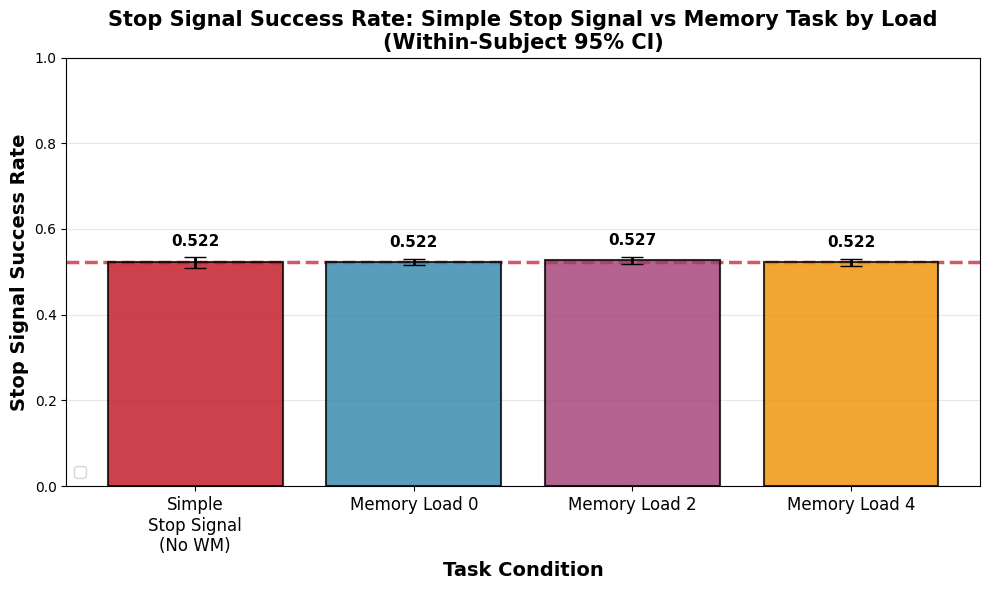


✓ Figure created successfully


In [35]:
# Prepare data for stop signal success rate by memory load
print("=== Stop Signal Success Rate: Simple Stop vs Memory Task by Load ===\n")

# Find participants with complete stop signal success rate data for both tasks
participants_both = list(set(metrics_data_stop['prolific_id']) & set(metrics_data_wm['prolific_id']))

# Filter for participants with complete data
stop_data = metrics_data_stop[metrics_data_stop['prolific_id'].isin(participants_both)]
stop_data = stop_data.dropna(subset=['stop_inhibition_success_rate'])

wm_data = metrics_data_wm[metrics_data_wm['prolific_id'].isin(participants_both)]
wm_data = wm_data.dropna(subset=[
    'dual_task_stop_wm0_inhibition_success_rate',
    'dual_task_stop_wm2_inhibition_success_rate',
    'dual_task_stop_wm4_inhibition_success_rate'
])

# Get overlapping participants with complete data
common_participants = list(set(stop_data['prolific_id']) & set(wm_data['prolific_id']))
stop_data_complete = stop_data[stop_data['prolific_id'].isin(common_participants)].set_index('prolific_id')
wm_data_complete = wm_data[wm_data['prolific_id'].isin(common_participants)].set_index('prolific_id')

print(f"Participants with complete stop signal success rate data for all conditions: {len(common_participants)}\n")

# Create data matrix for within-subject CI calculation
# Rows = participants, Columns = conditions
stop_success_matrix = pd.DataFrame({
    'Simple_Stop': stop_data_complete['stop_inhibition_success_rate'],
    'WM_Load_0': wm_data_complete['dual_task_stop_wm0_inhibition_success_rate'],
    'WM_Load_2': wm_data_complete['dual_task_stop_wm2_inhibition_success_rate'],
    'WM_Load_4': wm_data_complete['dual_task_stop_wm4_inhibition_success_rate']
})

# Calculate within-subject confidence intervals
all_cis = calculate_within_subject_ci(stop_success_matrix)

# Calculate means for each condition
all_means = np.array([
    stop_success_matrix['Simple_Stop'].mean(),
    stop_success_matrix['WM_Load_0'].mean(),
    stop_success_matrix['WM_Load_2'].mean(),
    stop_success_matrix['WM_Load_4'].mean()
])

# Store simple stop mean for reference line
simple_stop_mean = all_means[0]

# Print descriptive statistics
print("Descriptive Statistics:")
print(f"  Simple Stop Signal: M={all_means[0]:.3f}, SD={stop_success_matrix['Simple_Stop'].std():.3f}")
print(f"  WM Load 0: M={all_means[1]:.3f}, SD={stop_success_matrix['WM_Load_0'].std():.3f}")
print(f"  WM Load 2: M={all_means[2]:.3f}, SD={stop_success_matrix['WM_Load_2'].std():.3f}")
print(f"  WM Load 4: M={all_means[3]:.3f}, SD={stop_success_matrix['WM_Load_4'].std():.3f}")
print(f"\nWithin-subject 95% CI half-widths:")
print(f"  Simple Stop Signal: ±{all_cis[0]:.3f}")
print(f"  WM Load 0: ±{all_cis[1]:.3f}")
print(f"  WM Load 2: ±{all_cis[2]:.3f}")
print(f"  WM Load 4: ±{all_cis[3]:.3f}")

# Create the figure
fig, ax = plt.subplots(figsize=(10, 6))

# Set up bar positions and colors
conditions = ['Simple\nStop Signal\n(No WM)', 'Memory Load 0', 'Memory Load 2', 'Memory Load 4']
x_pos = np.arange(len(conditions))
colors = ['#C1121F', '#2E86AB', '#A23B72', '#F18F01']  # Red for baseline, then blue/purple/orange

# Create bar plot
bars = ax.bar(x_pos, all_means, yerr=all_cis, capsize=8,
              alpha=0.8, color=colors, edgecolor='black', linewidth=1.5,
              error_kw={'linewidth': 2, 'ecolor': 'black'})

# Add horizontal line for simple stop signal mean
ax.axhline(y=simple_stop_mean, color='#C1121F', linestyle='--', linewidth=2.5, 
           alpha=0.7, zorder=0)

# Customize the plot
ax.set_xlabel('Task Condition', fontsize=14, fontweight='bold')
ax.set_ylabel('Stop Signal Success Rate', fontsize=14, fontweight='bold')
ax.set_title('Stop Signal Success Rate: Simple Stop Signal vs Memory Task by Load\n(Within-Subject 95% CI)', 
             fontsize=15, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(conditions, fontsize=12)
ax.set_ylim([0, 1.0])

# Add grid for readability
ax.grid(True, alpha=0.3, axis='y')
ax.set_axisbelow(True)
ax.legend(fontsize=11, loc='lower left')

# Add value labels on bars
for i, (bar, mean, ci) in enumerate(zip(bars, all_means, all_cis)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + ci + 0.02,
            f'{mean:.3f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add note about within-subject CIs
#ax.text(0.98, 0.02, 'Error bars show within-subject 95% CIs\n(Cousineau, 2005; Morey, 2008)',
#        transform=ax.transAxes, fontsize=9, style='italic',
#        ha='right', va='bottom', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()

print("\n✓ Figure created successfully")


## 15. Probe Accuracy by Stop Signal Outcome

Visualization of probe accuracy conditional on stop signal outcome:
- **Successful Stop**: Trials where a stop signal was presented and the participant successfully inhibited their response
- **Failed Stop**: Trials where a stop signal was presented but the participant failed to inhibit
- **Go Trials**: Trials with no stop signal

This examines whether successful response inhibition is associated with better or worse memory performance.

**Statistical tests** (RM ANOVA + Bonferroni post-hoc) are in `analysis_notebook.ipynb`, Section 15.

> ⚠️ **Commission + omission errors are combined here.** The subject-level probe accuracy metric counts omission errors (no response) as incorrect alongside commission errors (wrong response). These are not distinguished in this section. See Sections 22–26 for omission-only analyses.

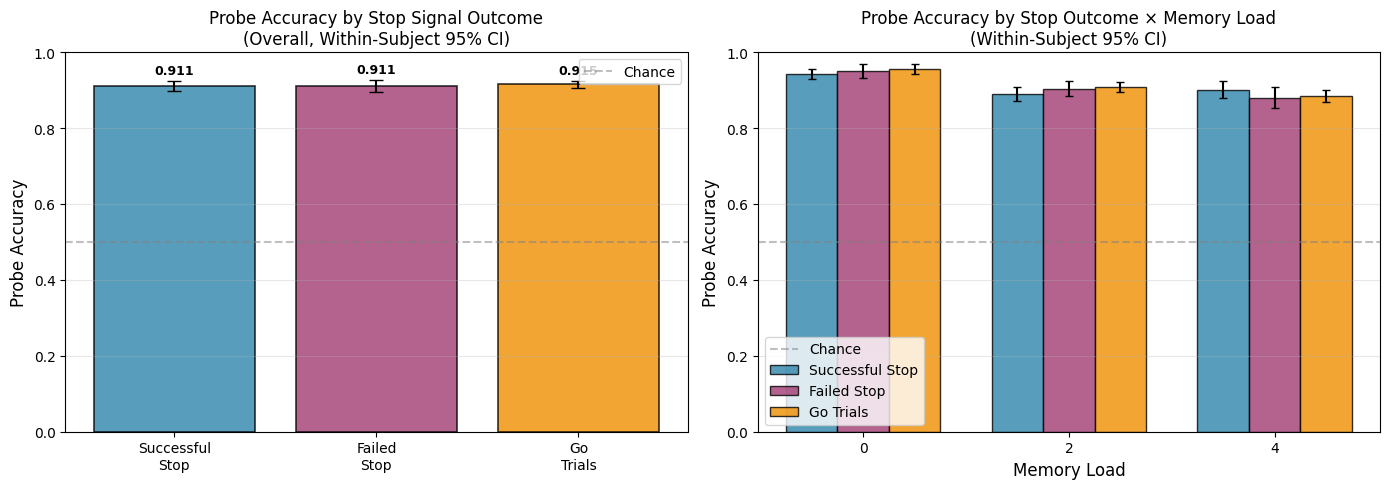


Note: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).


In [36]:
# === PROBE ACCURACY BY STOP SIGNAL OUTCOME — VISUALIZATION ===
# Statistical analysis (RM ANOVA + Bonferroni post-hoc) is in analysis_notebook.ipynb, Section 15.
metrics_data_wm = pd.read_csv('../data/results/post_qc_stop_signal_wm_metrics.csv')

wm_loads = [0, 2, 4]
results_by_load = {}
for wm_load in wm_loads:
    successful = metrics_data_wm[f'probe_wm{wm_load}_accuracy_on_successful_stop'].dropna()
    failed = metrics_data_wm[f'probe_wm{wm_load}_accuracy_on_failed_stop'].dropna()
    go = metrics_data_wm[f'probe_wm{wm_load}_accuracy_on_go_trials'].dropna()
    results_by_load[wm_load] = {
        'successful': {'mean': successful.mean(), 'std': successful.std(), 'n': len(successful)},
        'failed': {'mean': failed.mean(), 'std': failed.std(), 'n': len(failed)},
        'go': {'mean': go.mean(), 'std': go.std(), 'n': len(go)}
    }

# Use the same color palette as the rest of the notebook
colors_outcome = ['#2E86AB', '#A23B72', '#F18F01']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Overall comparison (bar chart) with within-subject CIs
ax1 = axes[0]
conditions = ['Successful\nStop', 'Failed\nStop', 'Go\nTrials']

# Build within-subject CI for the overall plot
# Use only participants who have data for all three outcome types
overall_all_mask = (
    metrics_data_wm['probe_accuracy_on_successful_stop'].notna() &
    metrics_data_wm['probe_accuracy_on_failed_stop'].notna() &
    metrics_data_wm['probe_accuracy_on_go_trials'].notna()
)
overall_sub = metrics_data_wm.loc[overall_all_mask]
overall_matrix = pd.DataFrame({
    'Successful_Stop': overall_sub['probe_accuracy_on_successful_stop'].values,
    'Failed_Stop':     overall_sub['probe_accuracy_on_failed_stop'].values,
    'Go_Trials':       overall_sub['probe_accuracy_on_go_trials'].values,
})
overall_ws_cis = calculate_within_subject_ci(overall_matrix)
means = [overall_matrix.iloc[:, c].mean() for c in range(3)]
cis   = [overall_ws_cis.iloc[c] if hasattr(overall_ws_cis, 'iloc') else overall_ws_cis[c] for c in range(3)]

bars = ax1.bar(conditions, means, yerr=cis, capsize=5, color=colors_outcome, alpha=0.8,
               edgecolor='black', linewidth=1.2, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax1.set_ylabel('Probe Accuracy', fontsize=12)
ax1.set_title('Probe Accuracy by Stop Signal Outcome\n(Overall, Within-Subject 95% CI)', fontsize=12)
ax1.set_ylim(0, 1)
ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Chance')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, mean, ci in zip(bars, means, cis):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2., height + ci + 0.01,
             f'{mean:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 2: By WM load (grouped bar chart) with within-subject CIs
ax2 = axes[1]
x = np.arange(len(wm_loads))
width = 0.25

successful_means = [results_by_load[wm]['successful']['mean'] for wm in wm_loads]
failed_means = [results_by_load[wm]['failed']['mean'] for wm in wm_loads]
go_means = [results_by_load[wm]['go']['mean'] for wm in wm_loads]

# Calculate within-subject CIs for each WM load level
load_cis = {'successful': [], 'failed': [], 'go': []}
for wm_load in wm_loads:
    load_mask = (
        metrics_data_wm[f'probe_wm{wm_load}_accuracy_on_successful_stop'].notna() &
        metrics_data_wm[f'probe_wm{wm_load}_accuracy_on_failed_stop'].notna() &
        metrics_data_wm[f'probe_wm{wm_load}_accuracy_on_go_trials'].notna()
    )
    load_sub = metrics_data_wm.loc[load_mask]
    load_matrix = pd.DataFrame({
        'Successful_Stop': load_sub[f'probe_wm{wm_load}_accuracy_on_successful_stop'].values,
        'Failed_Stop':     load_sub[f'probe_wm{wm_load}_accuracy_on_failed_stop'].values,
        'Go_Trials':       load_sub[f'probe_wm{wm_load}_accuracy_on_go_trials'].values,
    })
    ws_ci = calculate_within_subject_ci(load_matrix)
    load_cis['successful'].append(ws_ci.iloc[0] if hasattr(ws_ci, 'iloc') else ws_ci[0])
    load_cis['failed'].append(ws_ci.iloc[1] if hasattr(ws_ci, 'iloc') else ws_ci[1])
    load_cis['go'].append(ws_ci.iloc[2] if hasattr(ws_ci, 'iloc') else ws_ci[2])

bars1 = ax2.bar(x - width, successful_means, width, yerr=load_cis['successful'], capsize=3, 
                label='Successful Stop', color=colors_outcome[0], alpha=0.8,
                edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
bars2 = ax2.bar(x, failed_means, width, yerr=load_cis['failed'], capsize=3,
                label='Failed Stop', color=colors_outcome[1], alpha=0.8,
                edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
bars3 = ax2.bar(x + width, go_means, width, yerr=load_cis['go'], capsize=3,
                label='Go Trials', color=colors_outcome[2], alpha=0.8,
                edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})

ax2.set_xlabel('Memory Load', fontsize=12)
ax2.set_ylabel('Probe Accuracy', fontsize=12)
ax2.set_title('Probe Accuracy by Stop Outcome × Memory Load\n(Within-Subject 95% CI)', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(['0', '2', '4'])
ax2.set_ylim(0, 1)
ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Chance')
ax2.legend(loc='lower left')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nNote: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).")

## 16. Does Prior-Trial Probe Outcome Predict Stop Success?

Sequential dependency analysis: does the memory probe outcome on trial t-1 (correct vs. incorrect) predict whether the participant successfully inhibits on a stop trial at trial t?

- **t-1 Probe Correct → Stop trial**: stop success rate
- **t-1 Probe Incorrect → Stop trial**: stop success rate

Only consecutive trials *within the same block* are considered (no cross-block lag). Trial counts are reported because the conditions are likely unbalanced (most probes are correct).

> ⚠️ **Commission + omission errors are combined here.** The "probe incorrect" group (`memory_recognition_correct_trial == 0`) includes **both commission errors** (wrong response given, RT present) and **omission errors** (no response, RT is NaN). These are not distinguished in this analysis. See Sections 22–26 for omission-only analyses.

DOES PRIOR-TRIAL PROBE OUTCOME (t-1) PREDICT STOP SUCCESS?

--- OVERALL (collapsed across WM load) ---

Subjects with data in both conditions: 37

After t-1 Probe CORRECT:
  Stop success rate: M = 0.514, SD = 0.039
  Avg stop trials per subject: 127.7  (range: 106-140)
  Total stop trials: 4726

After t-1 Probe INCORRECT:
  Stop success rate: M = 0.609, SD = 0.235
  Avg stop trials per subject: 11.8  (range: 1-35)
  Total stop trials: 438

Paired t-test: t(36) = -2.347, p = 0.0245, Cohen's d = -0.391

--- t-1 Probe Incorrect trials per participant (Section 16: stop trials) ---
                          t-1_probe_incorrect_trials
participant_id                                      
63f82a4ff43ec144ca3622a8                          35
67cb51b23d74b436185a20eb                          34
676a24c4766af0941f2060db                          34
583b397f54686200010f1d20                          32
6838df8389ee2a2823f6964a                          31
5a09ebdf087f2e0001eae39f                     

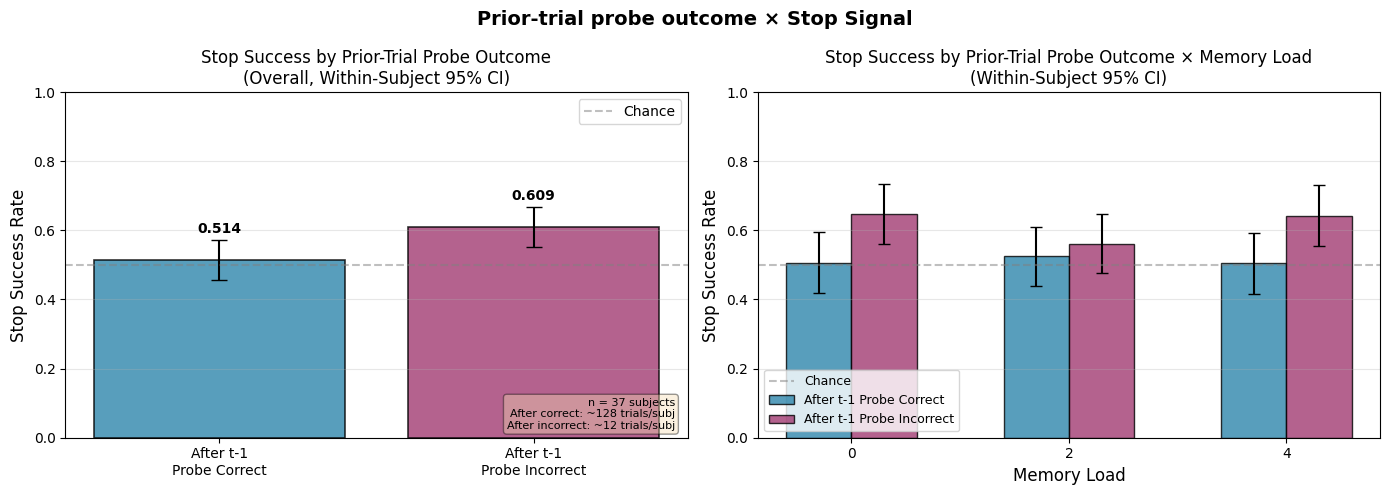


Note: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).
Trial counts are likely unbalanced because most probes are answered correctly.


In [37]:
# === DOES PRIOR-TRIAL PROBE OUTCOME PREDICT STOP SUCCESS? ===
from scipy.stats import ttest_rel

trial_data = trial_wise_data_wm.copy()

trial_data = trial_data.sort_values(['participant_id', 'block_num', 'current_trial']).reset_index(drop=True)

# Lag the probe accuracy within each subject × block
trial_data['prev_probe_correct'] = (
    trial_data
    .groupby(['participant_id', 'block_num'])['memory_recognition_correct_trial']
    .shift(1)
)

# Determine stop success: on stop trials, correct_trial == 1 means successful inhibition
trial_data['is_stop'] = (trial_data['stop_trial_SS_trial_type'] == 'stop')
trial_data['stop_success'] = (
    trial_data['is_stop'] & (trial_data['stop_trial_correct_trial'] == 1)
).astype(float)

# Keep only stop trials that have a valid previous-trial probe outcome
stop_with_lag = trial_data.loc[
    trial_data['is_stop'] & trial_data['prev_probe_correct'].notna()
].copy()

print("=" * 70)
print("DOES PRIOR-TRIAL PROBE OUTCOME (t-1) PREDICT STOP SUCCESS?")
print("=" * 70)

# --- Overall (collapsed across WM load) ---
print("\n--- OVERALL (collapsed across WM load) ---\n")

# Per-subject stop success rate by previous-trial probe outcome
subj_stats = (
    stop_with_lag
    .groupby(['participant_id', 'prev_probe_correct'])
    .agg(
        stop_success_rate=('stop_success', 'mean'),
        n_trials=('stop_success', 'count'),
    )
    .reset_index()
)

after_correct = subj_stats.loc[subj_stats['prev_probe_correct'] == 1].set_index('participant_id')
after_incorrect = subj_stats.loc[subj_stats['prev_probe_correct'] == 0].set_index('participant_id')

# Only keep subjects who have data in BOTH conditions
common_subjs = after_correct.index.intersection(after_incorrect.index)
ac = after_correct.loc[common_subjs]
ai = after_incorrect.loc[common_subjs]

n_subj = len(common_subjs)
print(f"Subjects with data in both conditions: {n_subj}")
print(f"\nAfter t-1 Probe CORRECT:")
print(f"  Stop success rate: M = {ac['stop_success_rate'].mean():.3f}, SD = {ac['stop_success_rate'].std():.3f}")
print(f"  Avg stop trials per subject: {ac['n_trials'].mean():.1f}  (range: {ac['n_trials'].min()}-{ac['n_trials'].max()})")
print(f"  Total stop trials: {ac['n_trials'].sum()}")

print(f"\nAfter t-1 Probe INCORRECT:")
print(f"  Stop success rate: M = {ai['stop_success_rate'].mean():.3f}, SD = {ai['stop_success_rate'].std():.3f}")
print(f"  Avg stop trials per subject: {ai['n_trials'].mean():.1f}  (range: {ai['n_trials'].min()}-{ai['n_trials'].max()})")
print(f"  Total stop trials: {ai['n_trials'].sum()}")

# Paired t-test
t_val, p_val = ttest_rel(ac['stop_success_rate'], ai['stop_success_rate'])
diff = ac['stop_success_rate'].values - ai['stop_success_rate'].values
cohens_d = diff.mean() / diff.std() if diff.std() > 0 else np.nan
print(f"\nPaired t-test: t({n_subj - 1}) = {t_val:.3f}, p = {p_val:.4f}, Cohen's d = {cohens_d:.3f}")

# Per-participant t-1 probe incorrect trial counts (Section 16: stop trials)
print("\n--- t-1 Probe Incorrect trials per participant (Section 16: stop trials) ---")
ai_n = ai[['n_trials']].copy()
ai_n.columns = ['t-1_probe_incorrect_trials']
print(ai_n.sort_values('t-1_probe_incorrect_trials', ascending=False).to_string())

# --- By WM Load ---
print("\n" + "=" * 70)
print("BY MEMORY LOAD LEVEL")
print("=" * 70)

wm_loads_lag = [0, 2, 4]
results_by_load_lag = {}

for wm_load in wm_loads_lag:
    print(f"\n--- WM Load = {wm_load} ---\n")
    load_data = stop_with_lag.loc[stop_with_lag['memory_trial_stimLength'] == wm_load]

    load_subj_stats = (
        load_data
        .groupby(['participant_id', 'prev_probe_correct'])
        .agg(stop_success_rate=('stop_success', 'mean'), n_trials=('stop_success', 'count'))
        .reset_index()
    )
    lac = load_subj_stats.loc[load_subj_stats['prev_probe_correct'] == 1].set_index('participant_id')
    lai = load_subj_stats.loc[load_subj_stats['prev_probe_correct'] == 0].set_index('participant_id')
    lc = lac.index.intersection(lai.index)
    lac_c = lac.loc[lc]
    lai_c = lai.loc[lc]

    results_by_load_lag[wm_load] = {
        'after_correct':   {'mean': lac_c['stop_success_rate'].mean(), 'std': lac_c['stop_success_rate'].std(), 'n': len(lc), 'avg_trials': lac_c['n_trials'].mean()},
        'after_incorrect': {'mean': lai_c['stop_success_rate'].mean(), 'std': lai_c['stop_success_rate'].std(), 'n': len(lc), 'avg_trials': lai_c['n_trials'].mean()},
    }

    print(f"  Subjects with both conditions: {len(lc)}")
    print(f"  After t-1 Correct:   M = {lac_c['stop_success_rate'].mean():.3f}, SD = {lac_c['stop_success_rate'].std():.3f}, avg trials = {lac_c['n_trials'].mean():.1f}")
    print(f"  After t-1 Incorrect: M = {lai_c['stop_success_rate'].mean():.3f}, SD = {lai_c['stop_success_rate'].std():.3f}, avg trials = {lai_c['n_trials'].mean():.1f}")

    if len(lc) > 2:
        t_l, p_l = ttest_rel(lac_c['stop_success_rate'], lai_c['stop_success_rate'])
        d_l = (lac_c['stop_success_rate'].values - lai_c['stop_success_rate'].values)
        cd_l = d_l.mean() / d_l.std() if d_l.std() > 0 else np.nan
        print(f"  Paired t-test: t({len(lc)-1}) = {t_l:.3f}, p = {p_l:.4f}, Cohen's d = {cd_l:.3f}")
    else:
        print("  Not enough subjects for paired t-test")

# --- Visualization ---
print("\n" + "=" * 70)
print("VISUALIZATION")
print("=" * 70)

colors_lag = ['#2E86AB', '#A23B72']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Prior-trial probe outcome × Stop Signal', fontsize=14, fontweight='bold')

# --- Plot 1: Overall ---
ax1 = axes[0]

overall_matrix_lag = pd.DataFrame({
    't-1 Correct':   ac['stop_success_rate'].values,
    't-1 Incorrect': ai['stop_success_rate'].values,
})
ws_ci_overall = calculate_within_subject_ci(overall_matrix_lag)
means_ov = [overall_matrix_lag.iloc[:, c].mean() for c in range(2)]
cis_ov = [ws_ci_overall.iloc[c] if hasattr(ws_ci_overall, 'iloc') else ws_ci_overall[c] for c in range(2)]

cond_labels = ['After t-1\nProbe Correct', 'After t-1\nProbe Incorrect']
bars = ax1.bar(cond_labels, means_ov, yerr=cis_ov, capsize=6, color=colors_lag, alpha=0.8,
               edgecolor='black', linewidth=1.2, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax1.set_ylabel('Stop Success Rate', fontsize=12)
ax1.set_title('Stop Success by Prior-Trial Probe Outcome\n(Overall, Within-Subject 95% CI)', fontsize=12)
ax1.set_ylim(0, 1)
ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Chance')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

for bar, mean, ci in zip(bars, means_ov, cis_ov):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2., height + ci + 0.01,
             f'{mean:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Trial count annotation
ax1.text(0.98, 0.02,
         f'n = {n_subj} subjects\n'
         f'After correct: ~{ac["n_trials"].mean():.0f} trials/subj\n'
         f'After incorrect: ~{ai["n_trials"].mean():.0f} trials/subj',
         transform=ax1.transAxes, ha='right', va='bottom', fontsize=8,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.4))

# --- Plot 2: By WM Load ---
ax2 = axes[1]
x = np.arange(len(wm_loads_lag))
width = 0.3

correct_means = [results_by_load_lag[wm]['after_correct']['mean'] for wm in wm_loads_lag]
incorrect_means = [results_by_load_lag[wm]['after_incorrect']['mean'] for wm in wm_loads_lag]

load_cis_lag = {'correct': [], 'incorrect': []}
for wm_load in wm_loads_lag:
    r = results_by_load_lag[wm_load]
    load_data_wm = stop_with_lag.loc[stop_with_lag['memory_trial_stimLength'] == wm_load]
    load_subj_wm = (
        load_data_wm
        .groupby(['participant_id', 'prev_probe_correct'])
        .agg(stop_success_rate=('stop_success', 'mean'))
        .reset_index()
    )
    lac_wm = load_subj_wm.loc[load_subj_wm['prev_probe_correct'] == 1].set_index('participant_id')
    lai_wm = load_subj_wm.loc[load_subj_wm['prev_probe_correct'] == 0].set_index('participant_id')
    lc_wm = lac_wm.index.intersection(lai_wm.index)
    if len(lc_wm) > 2:
        wm_matrix = pd.DataFrame({
            'correct':   lac_wm.loc[lc_wm, 'stop_success_rate'].values,
            'incorrect': lai_wm.loc[lc_wm, 'stop_success_rate'].values,
        })
        ws_ci_wm = calculate_within_subject_ci(wm_matrix)
        load_cis_lag['correct'].append(ws_ci_wm.iloc[0] if hasattr(ws_ci_wm, 'iloc') else ws_ci_wm[0])
        load_cis_lag['incorrect'].append(ws_ci_wm.iloc[1] if hasattr(ws_ci_wm, 'iloc') else ws_ci_wm[1])
    else:
        load_cis_lag['correct'].append(0)
        load_cis_lag['incorrect'].append(0)

bars1 = ax2.bar(x - width/2, correct_means, width, yerr=load_cis_lag['correct'], capsize=4,
                label='After t-1 Probe Correct', color=colors_lag[0], alpha=0.8,
                edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
bars2 = ax2.bar(x + width/2, incorrect_means, width, yerr=load_cis_lag['incorrect'], capsize=4,
                label='After t-1 Probe Incorrect', color=colors_lag[1], alpha=0.8,
                edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})

ax2.set_xlabel('Memory Load', fontsize=12)
ax2.set_ylabel('Stop Success Rate', fontsize=12)
ax2.set_title('Stop Success by Prior-Trial Probe Outcome × Memory Load\n(Within-Subject 95% CI)', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(['0', '2', '4'])
ax2.set_ylim(0, 1)
ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Chance')
ax2.legend(loc='lower left', fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nNote: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).")
print("Trial counts are likely unbalanced because most probes are answered correctly.")

## 16b. Prior-Trial Probe Outcome and Probe RT

Sequential dependency: does the memory probe outcome on trial t-1 (correct vs. incorrect) predict **probe RT** on trial t?

- **t-1 Probe Correct → trial t**: mean probe RT
- **t-1 Probe Incorrect → trial t**: mean probe RT

> ⚠️ **Commission + omission errors are combined here.** The "probe incorrect" group (`memory_recognition_correct_trial == 0`) includes **both commission errors** (wrong response given, RT present) and **omission errors** (no response, RT is NaN). These are not distinguished in this analysis. See Sections 22–26 for omission-only analyses.

Overall: Paired t-test: t(37) = -2.321, p = 0.0259, Cohen's d = -0.382

By WM Load:
  WM Load 0: Paired t-test: t(37) = -1.434, p = 0.1601, Cohen's d = -0.236
  WM Load 2: Paired t-test: t(37) = -2.554, p = 0.0149, Cohen's d = -0.420
  WM Load 4: Paired t-test: t(35) = -1.526, p = 0.1361, Cohen's d = -0.258


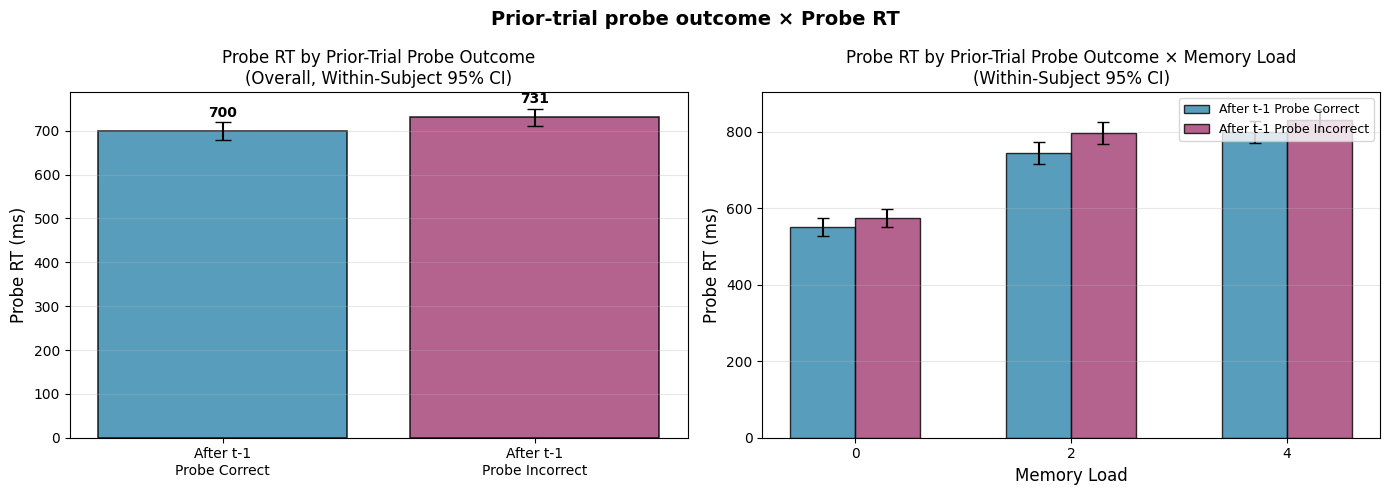


Note: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).


In [38]:
# === PRIOR-TRIAL PROBE OUTCOME AND PROBE RT ===
from scipy.stats import ttest_rel

trial_data_pr = trial_wise_data_wm.copy()
trial_data_pr = trial_data_pr.sort_values(['participant_id', 'block_num', 'current_trial']).reset_index(drop=True)

trial_data_pr['prev_probe_correct'] = (
    trial_data_pr
    .groupby(['participant_id', 'block_num'])['memory_recognition_correct_trial']
    .shift(1)
)

probe_rt_with_lag = trial_data_pr.loc[
    trial_data_pr['prev_probe_correct'].notna() & trial_data_pr['memory_recognition_rt'].notna()
].copy()

# Per-subject mean probe RT by previous-trial probe outcome
subj_prt = (
    probe_rt_with_lag
    .groupby(['participant_id', 'prev_probe_correct'])
    .agg(mean_probe_rt=('memory_recognition_rt', 'mean'), n_trials=('memory_recognition_rt', 'count'))
    .reset_index()
)

prt_after_correct = subj_prt.loc[subj_prt['prev_probe_correct'] == 1].set_index('participant_id')
prt_after_incorrect = subj_prt.loc[subj_prt['prev_probe_correct'] == 0].set_index('participant_id')
common_subjs_prt = prt_after_correct.index.intersection(prt_after_incorrect.index)
pac = prt_after_correct.loc[common_subjs_prt]
pai = prt_after_incorrect.loc[common_subjs_prt]

# Overall matrix for within-subject CI
overall_matrix_prt = pd.DataFrame({
    't-1 Correct': pac['mean_probe_rt'].values,
    't-1 Incorrect': pai['mean_probe_rt'].values,
})
ws_ci_prt = calculate_within_subject_ci(overall_matrix_prt)
means_prt = [overall_matrix_prt.iloc[:, c].mean() for c in range(2)]
cis_prt = [ws_ci_prt.iloc[c] if hasattr(ws_ci_prt, 'iloc') else ws_ci_prt[c] for c in range(2)]

# Paired t-test (overall)
n_prt = len(common_subjs_prt)
t_prt, p_prt = ttest_rel(pac['mean_probe_rt'], pai['mean_probe_rt'])
diff_prt = pac['mean_probe_rt'].values - pai['mean_probe_rt'].values
cd_prt = diff_prt.mean() / diff_prt.std() if diff_prt.std() > 0 else np.nan
print(f"Overall: Paired t-test: t({n_prt - 1}) = {t_prt:.3f}, p = {p_prt:.4f}, Cohen's d = {cd_prt:.3f}")
print("\nBy WM Load:")
# By WM load
wm_loads_prt = [0, 2, 4]
results_by_load_prt = {}
for wm_load in wm_loads_prt:
    load_data = probe_rt_with_lag.loc[probe_rt_with_lag['memory_trial_stimLength'] == wm_load]
    load_subj = (
        load_data
        .groupby(['participant_id', 'prev_probe_correct'])
        .agg(mean_probe_rt=('memory_recognition_rt', 'mean'), n_trials=('memory_recognition_rt', 'count'))
        .reset_index()
    )
    lac = load_subj.loc[load_subj['prev_probe_correct'] == 1].set_index('participant_id')
    lai = load_subj.loc[load_subj['prev_probe_correct'] == 0].set_index('participant_id')
    lc = lac.index.intersection(lai.index)
    lac_c = lac.loc[lc]
    lai_c = lai.loc[lc]
    if len(lc) > 2:
        t_l, p_l = ttest_rel(lac_c['mean_probe_rt'], lai_c['mean_probe_rt'])
        d_l = lac_c['mean_probe_rt'].values - lai_c['mean_probe_rt'].values
        cd_l = d_l.mean() / d_l.std() if d_l.std() > 0 else np.nan
        print(f"  WM Load {wm_load}: Paired t-test: t({len(lc)-1}) = {t_l:.3f}, p = {p_l:.4f}, Cohen's d = {cd_l:.3f}")
    if len(lc) > 2:
        wm_matrix = pd.DataFrame({
            'correct': lac.loc[lc, 'mean_probe_rt'].values,
            'incorrect': lai.loc[lc, 'mean_probe_rt'].values,
        })
        ws_ci_wm = calculate_within_subject_ci(wm_matrix)
        results_by_load_prt[wm_load] = {
            'after_correct': {'mean': lac.loc[lc, 'mean_probe_rt'].mean(), 'ci': ws_ci_wm.iloc[0] if hasattr(ws_ci_wm, 'iloc') else ws_ci_wm[0]},
            'after_incorrect': {'mean': lai.loc[lc, 'mean_probe_rt'].mean(), 'ci': ws_ci_wm.iloc[1] if hasattr(ws_ci_wm, 'iloc') else ws_ci_wm[1]},
        }
    else:
        results_by_load_prt[wm_load] = {
            'after_correct': {'mean': lac['mean_probe_rt'].mean(), 'ci': 0},
            'after_incorrect': {'mean': lai['mean_probe_rt'].mean(), 'ci': 0},
        }

colors_lag = ['#2E86AB', '#A23B72']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Prior-trial probe outcome × Probe RT', fontsize=14, fontweight='bold')

# Plot 1: Overall
ax1 = axes[0]
cond_labels = ['After t-1\nProbe Correct', 'After t-1\nProbe Incorrect']
bars = ax1.bar(cond_labels, means_prt, yerr=cis_prt, capsize=6, color=colors_lag, alpha=0.8,
               edgecolor='black', linewidth=1.2, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax1.set_ylabel('Probe RT (ms)', fontsize=12)
ax1.set_title('Probe RT by Prior-Trial Probe Outcome\n(Overall, Within-Subject 95% CI)', fontsize=12)
ax1.grid(True, alpha=0.3, axis='y')
for bar, mean, ci in zip(bars, means_prt, cis_prt):
    ax1.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + ci + 5,
             f'{mean:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 2: By WM Load
ax2 = axes[1]
x = np.arange(len(wm_loads_prt))
width = 0.3
correct_means = [results_by_load_prt[wm]['after_correct']['mean'] for wm in wm_loads_prt]
incorrect_means = [results_by_load_prt[wm]['after_incorrect']['mean'] for wm in wm_loads_prt]
correct_cis = [results_by_load_prt[wm]['after_correct']['ci'] for wm in wm_loads_prt]
incorrect_cis = [results_by_load_prt[wm]['after_incorrect']['ci'] for wm in wm_loads_prt]

ax2.bar(x - width/2, correct_means, width, yerr=correct_cis, capsize=4,
        label='After t-1 Probe Correct', color=colors_lag[0], alpha=0.8,
        edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax2.bar(x + width/2, incorrect_means, width, yerr=incorrect_cis, capsize=4,
        label='After t-1 Probe Incorrect', color=colors_lag[1], alpha=0.8,
        edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax2.set_xlabel('Memory Load', fontsize=12)
ax2.set_ylabel('Probe RT (ms)', fontsize=12)
ax2.set_title('Probe RT by Prior-Trial Probe Outcome × Memory Load\n(Within-Subject 95% CI)', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(['0', '2', '4'])
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nNote: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).")

## 17. Prior-Trial Probe Outcome and Go RT

Sequential dependency: does the memory probe outcome on trial t-1 (correct vs. incorrect) predict **go trial RT** on trial t?

- **t-1 Probe Correct → Go trial**: mean RT
- **t-1 Probe Incorrect → Go trial**: mean RT

Only consecutive trials *within the same block* are considered. Within-subject 95% CIs (Cousineau-Morey).

> ⚠️ **Commission + omission errors are combined here.** The "probe incorrect" group (`memory_recognition_correct_trial == 0`) includes **both commission errors** (wrong response given, RT present) and **omission errors** (no response, RT is NaN). These are not distinguished in this analysis. See Sections 22–26 for omission-only analyses.

Overall: Paired t-test: t(37) = -0.941, p = 0.3529, Cohen's d = -0.155

By WM Load:
  WM Load 0: Paired t-test: t(35) = -0.992, p = 0.3281, Cohen's d = -0.168
  WM Load 2: Paired t-test: t(36) = 0.335, p = 0.7396, Cohen's d = 0.056
  WM Load 4: Paired t-test: t(35) = -0.645, p = 0.5231, Cohen's d = -0.109


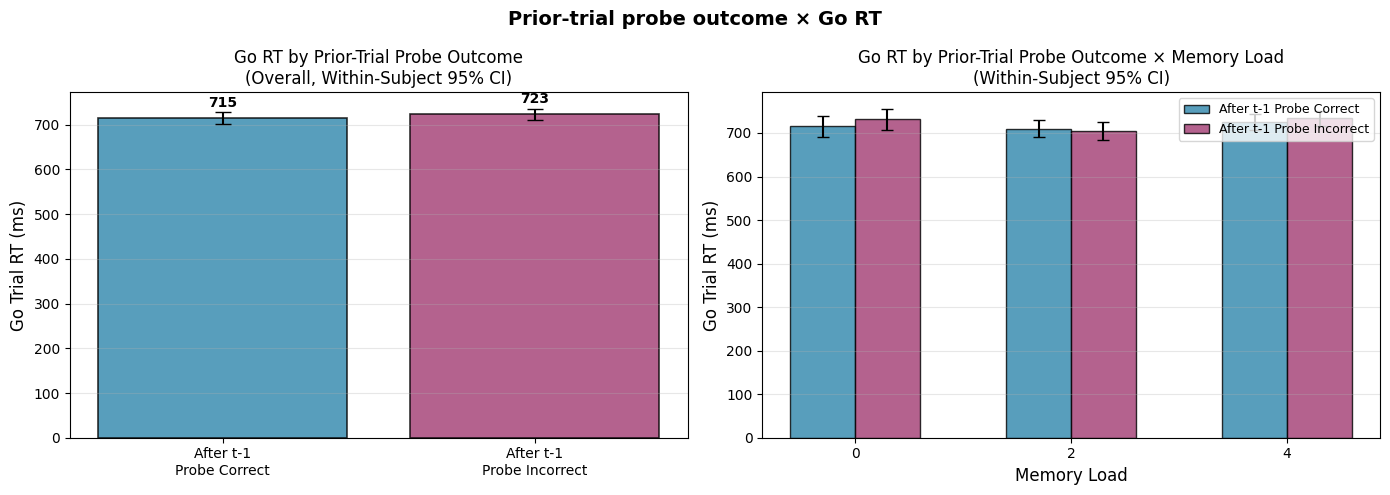


Note: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).


In [39]:
# === PRIOR-TRIAL PROBE OUTCOME AND GO RT ===
from scipy.stats import ttest_rel

trial_data = trial_wise_data_wm.copy()
trial_data = trial_data.sort_values(['participant_id', 'block_num', 'current_trial']).reset_index(drop=True)

trial_data['prev_probe_correct'] = (
    trial_data
    .groupby(['participant_id', 'block_num'])['memory_recognition_correct_trial']
    .shift(1)
)

trial_data['is_stop'] = trial_data['stop_trial_SS_trial_type'].str.lower() == 'stop'
trial_data['go_rt'] = trial_data['stop_trial_rt'].astype(float)

go_with_lag = trial_data.loc[
    (~trial_data['is_stop']) & trial_data['prev_probe_correct'].notna() & trial_data['go_rt'].notna()
].copy()

# Per-subject mean go RT by previous-trial probe outcome
subj_rt = (
    go_with_lag
    .groupby(['participant_id', 'prev_probe_correct'])
    .agg(mean_go_rt=('go_rt', 'mean'), n_trials=('go_rt', 'count'))
    .reset_index()
)

rt_after_correct = subj_rt.loc[subj_rt['prev_probe_correct'] == 1].set_index('participant_id')
rt_after_incorrect = subj_rt.loc[subj_rt['prev_probe_correct'] == 0].set_index('participant_id')
common_subjs_rt = rt_after_correct.index.intersection(rt_after_incorrect.index)
rac = rt_after_correct.loc[common_subjs_rt]
rai = rt_after_incorrect.loc[common_subjs_rt]

# Overall matrix for within-subject CI
overall_matrix_rt = pd.DataFrame({
    't-1 Correct': rac['mean_go_rt'].values,
    't-1 Incorrect': rai['mean_go_rt'].values,
})
ws_ci_rt = calculate_within_subject_ci(overall_matrix_rt)
means_rt = [overall_matrix_rt.iloc[:, c].mean() for c in range(2)]
cis_rt = [ws_ci_rt.iloc[c] if hasattr(ws_ci_rt, 'iloc') else ws_ci_rt[c] for c in range(2)]

# Paired t-test (overall)
n_rt = len(common_subjs_rt)
t_rt, p_rt = ttest_rel(rac['mean_go_rt'], rai['mean_go_rt'])
diff_rt = rac['mean_go_rt'].values - rai['mean_go_rt'].values
cd_rt = diff_rt.mean() / diff_rt.std() if diff_rt.std() > 0 else np.nan
print(f"Overall: Paired t-test: t({n_rt - 1}) = {t_rt:.3f}, p = {p_rt:.4f}, Cohen's d = {cd_rt:.3f}")
print("\nBy WM Load:")
# By WM load
wm_loads_rt = [0, 2, 4]
results_by_load_rt = {}
for wm_load in wm_loads_rt:
    load_data = go_with_lag.loc[go_with_lag['memory_trial_stimLength'] == wm_load]
    load_subj = (
        load_data
        .groupby(['participant_id', 'prev_probe_correct'])
        .agg(mean_go_rt=('go_rt', 'mean'), n_trials=('go_rt', 'count'))
        .reset_index()
    )
    lac = load_subj.loc[load_subj['prev_probe_correct'] == 1].set_index('participant_id')
    lai = load_subj.loc[load_subj['prev_probe_correct'] == 0].set_index('participant_id')
    lc = lac.index.intersection(lai.index)
    lac_c = lac.loc[lc]
    lai_c = lai.loc[lc]
    if len(lc) > 2:
        t_l, p_l = ttest_rel(lac_c['mean_go_rt'], lai_c['mean_go_rt'])
        d_l = lac_c['mean_go_rt'].values - lai_c['mean_go_rt'].values
        cd_l = d_l.mean() / d_l.std() if d_l.std() > 0 else np.nan
        print(f"  WM Load {wm_load}: Paired t-test: t({len(lc)-1}) = {t_l:.3f}, p = {p_l:.4f}, Cohen's d = {cd_l:.3f}")
    if len(lc) > 2:
        wm_matrix = pd.DataFrame({
            'correct': lac.loc[lc, 'mean_go_rt'].values,
            'incorrect': lai.loc[lc, 'mean_go_rt'].values,
        })
        ws_ci_wm = calculate_within_subject_ci(wm_matrix)
        results_by_load_rt[wm_load] = {
            'after_correct': {'mean': lac.loc[lc, 'mean_go_rt'].mean(), 'ci': ws_ci_wm.iloc[0] if hasattr(ws_ci_wm, 'iloc') else ws_ci_wm[0]},
            'after_incorrect': {'mean': lai.loc[lc, 'mean_go_rt'].mean(), 'ci': ws_ci_wm.iloc[1] if hasattr(ws_ci_wm, 'iloc') else ws_ci_wm[1]},
        }
    else:
        results_by_load_rt[wm_load] = {
            'after_correct': {'mean': lac['mean_go_rt'].mean(), 'ci': 0},
            'after_incorrect': {'mean': lai['mean_go_rt'].mean(), 'ci': 0},
        }

colors_lag = ['#2E86AB', '#A23B72']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Prior-trial probe outcome × Go RT', fontsize=14, fontweight='bold')

# Plot 1: Overall
ax1 = axes[0]
cond_labels = ['After t-1\nProbe Correct', 'After t-1\nProbe Incorrect']
bars = ax1.bar(cond_labels, means_rt, yerr=cis_rt, capsize=6, color=colors_lag, alpha=0.8,
               edgecolor='black', linewidth=1.2, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax1.set_ylabel('Go Trial RT (ms)', fontsize=12)
ax1.set_title('Go RT by Prior-Trial Probe Outcome\n(Overall, Within-Subject 95% CI)', fontsize=12)
ax1.grid(True, alpha=0.3, axis='y')
for bar, mean, ci in zip(bars, means_rt, cis_rt):
    ax1.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + ci + 5,
             f'{mean:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 2: By WM Load
ax2 = axes[1]
x = np.arange(len(wm_loads_rt))
width = 0.3
correct_means = [results_by_load_rt[wm]['after_correct']['mean'] for wm in wm_loads_rt]
incorrect_means = [results_by_load_rt[wm]['after_incorrect']['mean'] for wm in wm_loads_rt]
correct_cis = [results_by_load_rt[wm]['after_correct']['ci'] for wm in wm_loads_rt]
incorrect_cis = [results_by_load_rt[wm]['after_incorrect']['ci'] for wm in wm_loads_rt]

ax2.bar(x - width/2, correct_means, width, yerr=correct_cis, capsize=4,
        label='After t-1 Probe Correct', color=colors_lag[0], alpha=0.8,
        edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax2.bar(x + width/2, incorrect_means, width, yerr=incorrect_cis, capsize=4,
        label='After t-1 Probe Incorrect', color=colors_lag[1], alpha=0.8,
        edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax2.set_xlabel('Memory Load', fontsize=12)
ax2.set_ylabel('Go Trial RT (ms)', fontsize=12)
ax2.set_title('Go RT by Prior-Trial Probe Outcome × Memory Load\n(Within-Subject 95% CI)', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(['0', '2', '4'])
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nNote: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).")

## 17b. Go RT Correct vs Incorrect by Prior-Trial Probe Outcome

Disambiguates section 17 by splitting Go RT into:
- **Go RT Correct**: mean RT on Go trials where the participant responded correctly (`stop_trial_correct_trial == 1`)
- **Go RT Incorrect**: mean RT on Go trials where the participant responded but was incorrect (commission errors; `stop_trial_correct_trial == 0`)

Each is analyzed by prior-trial probe outcome (t-1 correct vs t-1 incorrect). **Figure legend**: bar color = t-1 outcome; diagonal hatching = Go Incorrect.

> ⚠️ **Commission + omission errors are combined here.** The "probe incorrect" group (`memory_recognition_correct_trial == 0`) includes **both commission errors** (wrong response given, RT present) and **omission errors** (no response, RT is NaN). These are not distinguished in this analysis. See Sections 22–26 for omission-only analyses.

Go RT Correct: Paired t-test: t(2) = -0.965, p = 0.3409, Cohen's d = -0.159
Go RT Incorrect: Paired t-test: t(2) = 0.397, p = 0.6961, Cohen's d = 0.094


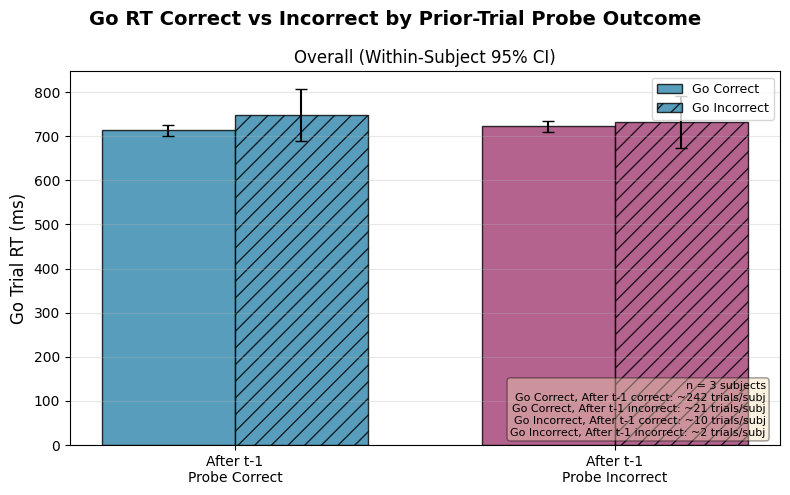


Note: Color = t-1 outcome; Hatching = Go Correct (solid) vs Go Incorrect (diagonal lines). Trial counts = avg per subject.


In [40]:
# === GO RT CORRECT vs INCORRECT BY PRIOR-TRIAL PROBE OUTCOME ===
from scipy.stats import ttest_rel

trial_data_17b = trial_wise_data_wm.copy()
trial_data_17b = trial_data_17b.sort_values(['participant_id', 'block_num', 'current_trial']).reset_index(drop=True)

trial_data_17b['prev_probe_correct'] = (
    trial_data_17b
    .groupby(['participant_id', 'block_num'])['memory_recognition_correct_trial']
    .shift(1)
)

trial_data_17b['is_stop'] = trial_data_17b['stop_trial_SS_trial_type'].str.lower() == 'stop'
trial_data_17b['go_rt'] = trial_data_17b['stop_trial_rt'].astype(float)
trial_data_17b['go_correct'] = pd.to_numeric(trial_data_17b['stop_trial_correct_trial'], errors='coerce')

# Go trials with response, split by correctness
base_filter = (~trial_data_17b['is_stop']) & trial_data_17b['prev_probe_correct'].notna() & trial_data_17b['go_rt'].notna()
go_correct_trials = trial_data_17b.loc[base_filter & (trial_data_17b['go_correct'] == 1)].copy()
go_incorrect_trials = trial_data_17b.loc[base_filter & (trial_data_17b['go_correct'] == 0)].copy()

def run_go_rt_analysis(go_df, label):
    """Run prior-trial probe outcome analysis for a subset of go trials."""
    subj_rt = (
        go_df
        .groupby(['participant_id', 'prev_probe_correct'])
        .agg(mean_go_rt=('go_rt', 'mean'), n_trials=('go_rt', 'count'))
        .reset_index()
    )
    rt_after_correct = subj_rt.loc[subj_rt['prev_probe_correct'] == 1].set_index('participant_id')
    rt_after_incorrect = subj_rt.loc[subj_rt['prev_probe_correct'] == 0].set_index('participant_id')
    common = rt_after_correct.index.intersection(rt_after_incorrect.index)
    rac = rt_after_correct.loc[common]
    rai = rt_after_incorrect.loc[common]
    if len(common) < 3:
        return None, None, None, None, None, None, None
    overall_matrix = pd.DataFrame({'t-1 Correct': rac['mean_go_rt'].values, 't-1 Incorrect': rai['mean_go_rt'].values})
    ws_ci = calculate_within_subject_ci(overall_matrix)
    means = [overall_matrix.iloc[:, c].mean() for c in range(2)]
    cis = [ws_ci.iloc[c] if hasattr(ws_ci, 'iloc') else ws_ci[c] for c in range(2)]
    t_val, p_val = ttest_rel(rac['mean_go_rt'], rai['mean_go_rt'])
    diff = rac['mean_go_rt'].values - rai['mean_go_rt'].values
    cd = diff.mean() / diff.std() if diff.std() > 0 else np.nan
    results_by_load = {}
    for wm_load in [0, 2, 4]:
        load_data = go_df.loc[go_df['memory_trial_stimLength'] == wm_load]
        load_subj = load_data.groupby(['participant_id', 'prev_probe_correct']).agg(mean_go_rt=('go_rt', 'mean')).reset_index()
        lac = load_subj.loc[load_subj['prev_probe_correct'] == 1].set_index('participant_id')
        lai = load_subj.loc[load_subj['prev_probe_correct'] == 0].set_index('participant_id')
        lc = lac.index.intersection(lai.index)
        if len(lc) > 2:
            wm_matrix = pd.DataFrame({'correct': lac.loc[lc, 'mean_go_rt'].values, 'incorrect': lai.loc[lc, 'mean_go_rt'].values})
            ws_ci_wm = calculate_within_subject_ci(wm_matrix)
            results_by_load[wm_load] = {
                'after_correct': {'mean': lac.loc[lc, 'mean_go_rt'].mean(), 'ci': ws_ci_wm.iloc[0] if hasattr(ws_ci_wm, 'iloc') else ws_ci_wm[0]},
                'after_incorrect': {'mean': lai.loc[lc, 'mean_go_rt'].mean(), 'ci': ws_ci_wm.iloc[1] if hasattr(ws_ci_wm, 'iloc') else ws_ci_wm[1]},
            }
        else:
            results_by_load[wm_load] = {'after_correct': {'mean': lac['mean_go_rt'].mean(), 'ci': 0}, 'after_incorrect': {'mean': lai['mean_go_rt'].mean(), 'ci': 0}}
    return means, cis, t_val, p_val, cd, results_by_load, common

# Run for correct and incorrect go trials
res_correct = run_go_rt_analysis(go_correct_trials, 'Go Correct')
res_incorrect = run_go_rt_analysis(go_incorrect_trials, 'Go Incorrect')

# Trial counts (avg per subject) for each of the 4 conditions (like Section 16)
subj_gc = go_correct_trials.groupby(['participant_id', 'prev_probe_correct']).size().reset_index(name='n_trials')
subj_gi = go_incorrect_trials.groupby(['participant_id', 'prev_probe_correct']).size().reset_index(name='n_trials')
n_gc_t1c = subj_gc[subj_gc['prev_probe_correct']==1]['n_trials'].mean()
n_gc_t1i = subj_gc[subj_gc['prev_probe_correct']==0]['n_trials'].mean()
n_gi_t1c = subj_gi[subj_gi['prev_probe_correct']==1]['n_trials'].mean()
n_gi_t1i = subj_gi[subj_gi['prev_probe_correct']==0]['n_trials'].mean()
n_subj_17b = len(res_correct[5]) if res_correct[5] is not None else 0

colors_17b = ['#2E86AB', '#A23B72']  # t-1 Correct, t-1 Incorrect
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
fig.suptitle('Go RT Correct vs Incorrect by Prior-Trial Probe Outcome', fontsize=14, fontweight='bold')

# Overall: Color = t-1 outcome; Hatching = Go Correct (none) vs Go Incorrect (//)
x = np.arange(2)  # After t-1 Correct, After t-1 Incorrect
width = 0.35
if res_correct[0] is not None:
    ax.bar(x - width/2, res_correct[0], width, yerr=res_correct[1], capsize=4, label='Go Correct', color=colors_17b, alpha=0.8, edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
    print(f"Go RT Correct: Paired t-test: t({len(res_correct[5])-1}) = {res_correct[2]:.3f}, p = {res_correct[3]:.4f}, Cohen's d = {res_correct[4]:.3f}")
if res_incorrect[0] is not None:
    ax.bar(x + width/2, res_incorrect[0], width, yerr=res_incorrect[1], capsize=4, label='Go Incorrect', color=colors_17b, alpha=0.8, edgecolor='black', linewidth=1.0, hatch='//', error_kw={'linewidth': 1.5, 'ecolor': 'black'})
    print(f"Go RT Incorrect: Paired t-test: t({len(res_incorrect[5])-1}) = {res_incorrect[2]:.3f}, p = {res_incorrect[3]:.4f}, Cohen's d = {res_incorrect[4]:.3f}")

# Trial count annotation (like Section 16: corner text box)
ax.text(0.98, 0.02,
        f'n = {n_subj_17b} subjects\n'
        f'Go Correct, After t-1 correct: ~{n_gc_t1c:.0f} trials/subj\n'
        f'Go Correct, After t-1 incorrect: ~{n_gc_t1i:.0f} trials/subj\n'
        f'Go Incorrect, After t-1 correct: ~{n_gi_t1c:.0f} trials/subj\n'
        f'Go Incorrect, After t-1 incorrect: ~{n_gi_t1i:.0f} trials/subj',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=8,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.4))

ax.set_xticks(x)
ax.set_xticklabels(['After t-1\nProbe Correct', 'After t-1\nProbe Incorrect'])
ax.set_ylabel('Go Trial RT (ms)', fontsize=12)
ax.set_title('Overall (Within-Subject 95% CI)', fontsize=12)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print("\nNote: Color = t-1 outcome; Hatching = Go Correct (solid) vs Go Incorrect (diagonal lines). Trial counts = avg per subject.")

## 18. SSD by Prior-Trial Probe Outcome

Sequential dependency: does the memory probe outcome on trial t-1 (correct vs. incorrect) predict **SSD** (stop-signal delay) on trial t?

- **t-1 Probe Correct → Stop trial**: mean SSD
- **t-1 Probe Incorrect → Stop trial**: mean SSD

> ⚠️ **Commission + omission errors are combined here.** The "probe incorrect" group (`memory_recognition_correct_trial == 0`) includes **both commission errors** (wrong response given, RT present) and **omission errors** (no response, RT is NaN). These are not distinguished in this analysis. See Sections 22–26 for omission-only analyses.

Overall: Paired t-test: t(36) = 0.651, p = 0.5190, Cohen's d = 0.109

By WM Load:
  WM Load 0: Paired t-test: t(33) = -1.034, p = 0.3089, Cohen's d = -0.180
  WM Load 2: Paired t-test: t(33) = 1.199, p = 0.2393, Cohen's d = 0.209
  WM Load 4: Paired t-test: t(32) = -0.211, p = 0.8342, Cohen's d = -0.037


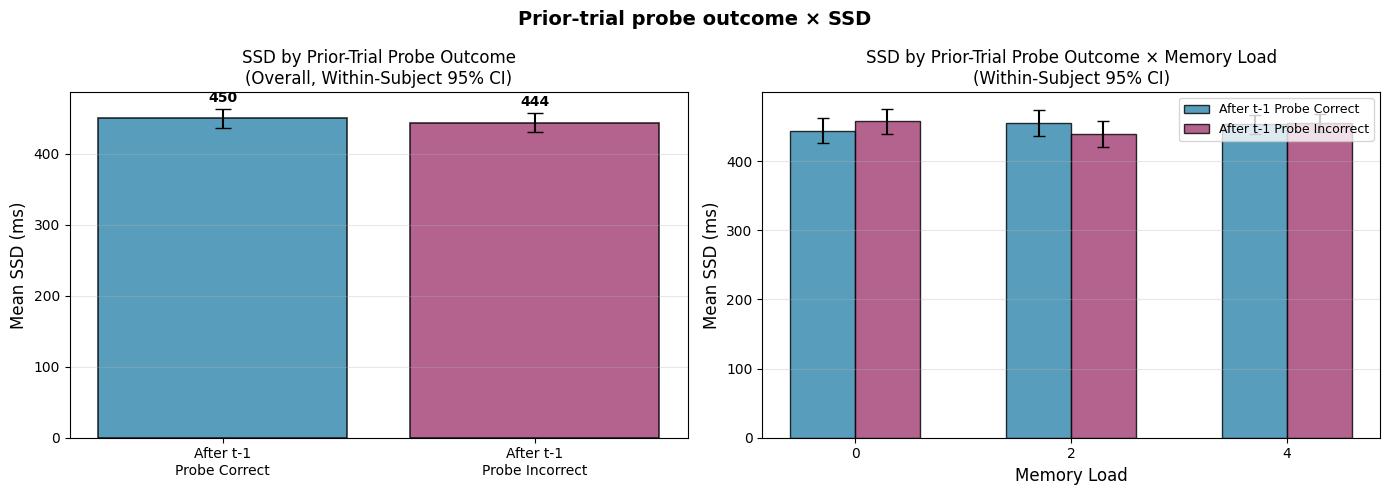


Note: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).


In [41]:
# === SSD BY PRIOR-TRIAL PROBE OUTCOME ===
from scipy.stats import ttest_rel

trial_data_ssd = trial_wise_data_wm.copy()
trial_data_ssd = trial_data_ssd.sort_values(['participant_id', 'block_num', 'current_trial']).reset_index(drop=True)

trial_data_ssd['prev_probe_correct'] = (
    trial_data_ssd
    .groupby(['participant_id', 'block_num'])['memory_recognition_correct_trial']
    .shift(1)
)

trial_data_ssd['is_stop'] = trial_data_ssd['stop_trial_SS_trial_type'].str.lower() == 'stop'
trial_data_ssd['SSD'] = pd.to_numeric(trial_data_ssd['stop_trial_SSD'], errors='coerce')

stop_ssd = trial_data_ssd.loc[
    trial_data_ssd['is_stop'] & trial_data_ssd['prev_probe_correct'].notna() & trial_data_ssd['SSD'].notna()
].copy()

# Per-subject mean SSD by previous-trial probe outcome
subj_ssd = (
    stop_ssd
    .groupby(['participant_id', 'prev_probe_correct'])
    .agg(mean_SSD=('SSD', 'mean'), n_trials=('SSD', 'count'))
    .reset_index()
)

ssd_after_correct = subj_ssd.loc[subj_ssd['prev_probe_correct'] == 1].set_index('participant_id')
ssd_after_incorrect = subj_ssd.loc[subj_ssd['prev_probe_correct'] == 0].set_index('participant_id')
common_ssd = ssd_after_correct.index.intersection(ssd_after_incorrect.index)
sac = ssd_after_correct.loc[common_ssd]
sai = ssd_after_incorrect.loc[common_ssd]

# Overall within-subject CI
overall_matrix_ssd = pd.DataFrame({
    't-1 Correct': sac['mean_SSD'].values,
    't-1 Incorrect': sai['mean_SSD'].values,
})
ws_ci_ssd = calculate_within_subject_ci(overall_matrix_ssd)
means_ssd = [overall_matrix_ssd.iloc[:, c].mean() for c in range(2)]
cis_ssd = [ws_ci_ssd.iloc[c] if hasattr(ws_ci_ssd, 'iloc') else ws_ci_ssd[c] for c in range(2)]

# Paired t-test (overall)
n_ssd = len(common_ssd)
t_ssd, p_ssd = ttest_rel(sac['mean_SSD'], sai['mean_SSD'])
diff_ssd = sac['mean_SSD'].values - sai['mean_SSD'].values
cd_ssd = diff_ssd.mean() / diff_ssd.std() if diff_ssd.std() > 0 else np.nan
print(f"Overall: Paired t-test: t({n_ssd - 1}) = {t_ssd:.3f}, p = {p_ssd:.4f}, Cohen's d = {cd_ssd:.3f}")
print("\nBy WM Load:")
# By WM load
wm_loads_ssd = [0, 2, 4]
results_by_load_ssd = {}
for wm_load in wm_loads_ssd:
    load_data = stop_ssd.loc[stop_ssd['memory_trial_stimLength'] == wm_load]
    load_subj = (
        load_data
        .groupby(['participant_id', 'prev_probe_correct'])
        .agg(mean_SSD=('SSD', 'mean'))
        .reset_index()
    )
    lac = load_subj.loc[load_subj['prev_probe_correct'] == 1].set_index('participant_id')
    lai = load_subj.loc[load_subj['prev_probe_correct'] == 0].set_index('participant_id')
    lc = lac.index.intersection(lai.index)
    lac_c = lac.loc[lc]
    lai_c = lai.loc[lc]
    if len(lc) > 2:
        t_l, p_l = ttest_rel(lac_c['mean_SSD'], lai_c['mean_SSD'])
        d_l = lac_c['mean_SSD'].values - lai_c['mean_SSD'].values
        cd_l = d_l.mean() / d_l.std() if d_l.std() > 0 else np.nan
        print(f"  WM Load {wm_load}: Paired t-test: t({len(lc)-1}) = {t_l:.3f}, p = {p_l:.4f}, Cohen's d = {cd_l:.3f}")
    if len(lc) > 2:
        wm_matrix = pd.DataFrame({
            'correct': lac.loc[lc, 'mean_SSD'].values,
            'incorrect': lai.loc[lc, 'mean_SSD'].values,
        })
        ws_ci_wm = calculate_within_subject_ci(wm_matrix)
        results_by_load_ssd[wm_load] = {
            'after_correct': {'mean': lac.loc[lc, 'mean_SSD'].mean(), 'ci': ws_ci_wm.iloc[0] if hasattr(ws_ci_wm, 'iloc') else ws_ci_wm[0]},
            'after_incorrect': {'mean': lai.loc[lc, 'mean_SSD'].mean(), 'ci': ws_ci_wm.iloc[1] if hasattr(ws_ci_wm, 'iloc') else ws_ci_wm[1]},
        }
    else:
        results_by_load_ssd[wm_load] = {
            'after_correct': {'mean': lac['mean_SSD'].mean(), 'ci': 0},
            'after_incorrect': {'mean': lai['mean_SSD'].mean(), 'ci': 0},
        }

colors_lag = ['#2E86AB', '#A23B72']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Prior-trial probe outcome × SSD', fontsize=14, fontweight='bold')

# Plot 1: Overall
ax1 = axes[0]
cond_labels = ['After t-1\nProbe Correct', 'After t-1\nProbe Incorrect']
bars = ax1.bar(cond_labels, means_ssd, yerr=cis_ssd, capsize=6, color=colors_lag, alpha=0.8,
               edgecolor='black', linewidth=1.2, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax1.set_ylabel('Mean SSD (ms)', fontsize=12)
ax1.set_title('SSD by Prior-Trial Probe Outcome\n(Overall, Within-Subject 95% CI)', fontsize=12)
ax1.grid(True, alpha=0.3, axis='y')
for bar, mean, ci in zip(bars, means_ssd, cis_ssd):
    ax1.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + ci + 5,
             f'{mean:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 2: By WM Load
ax2 = axes[1]
x = np.arange(len(wm_loads_ssd))
width = 0.3
correct_means = [results_by_load_ssd[wm]['after_correct']['mean'] for wm in wm_loads_ssd]
incorrect_means = [results_by_load_ssd[wm]['after_incorrect']['mean'] for wm in wm_loads_ssd]
correct_cis = [results_by_load_ssd[wm]['after_correct']['ci'] for wm in wm_loads_ssd]
incorrect_cis = [results_by_load_ssd[wm]['after_incorrect']['ci'] for wm in wm_loads_ssd]

ax2.bar(x - width/2, correct_means, width, yerr=correct_cis, capsize=4,
        label='After t-1 Probe Correct', color=colors_lag[0], alpha=0.8,
        edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax2.bar(x + width/2, incorrect_means, width, yerr=incorrect_cis, capsize=4,
        label='After t-1 Probe Incorrect', color=colors_lag[1], alpha=0.8,
        edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax2.set_xlabel('Memory Load', fontsize=12)
ax2.set_ylabel('Mean SSD (ms)', fontsize=12)
ax2.set_title('SSD by Prior-Trial Probe Outcome × Memory Load\n(Within-Subject 95% CI)', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(['0', '2', '4'])
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print("\nNote: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).")

## 20. Prior-Trial Outcome and Go Accuracy

Whether the prior trial's outcome (correct vs incorrect on the stop-signal task) predicts go accuracy on the current trial. For go trials, accuracy = correct key press; prior trial outcome = whether t-1 was correct (go: right key; stop: successful inhibition) or incorrect.

Overall: Paired t-test: t(37) = 1.726, p = 0.0927, Cohen's d = 0.284

By WM Load:
  WM Load 0: Paired t-test: t(37) = 1.222, p = 0.2296, Cohen's d = 0.201
  WM Load 2: Paired t-test: t(37) = 1.193, p = 0.2404, Cohen's d = 0.196
  WM Load 4: Paired t-test: t(37) = 2.084, p = 0.0441, Cohen's d = 0.343


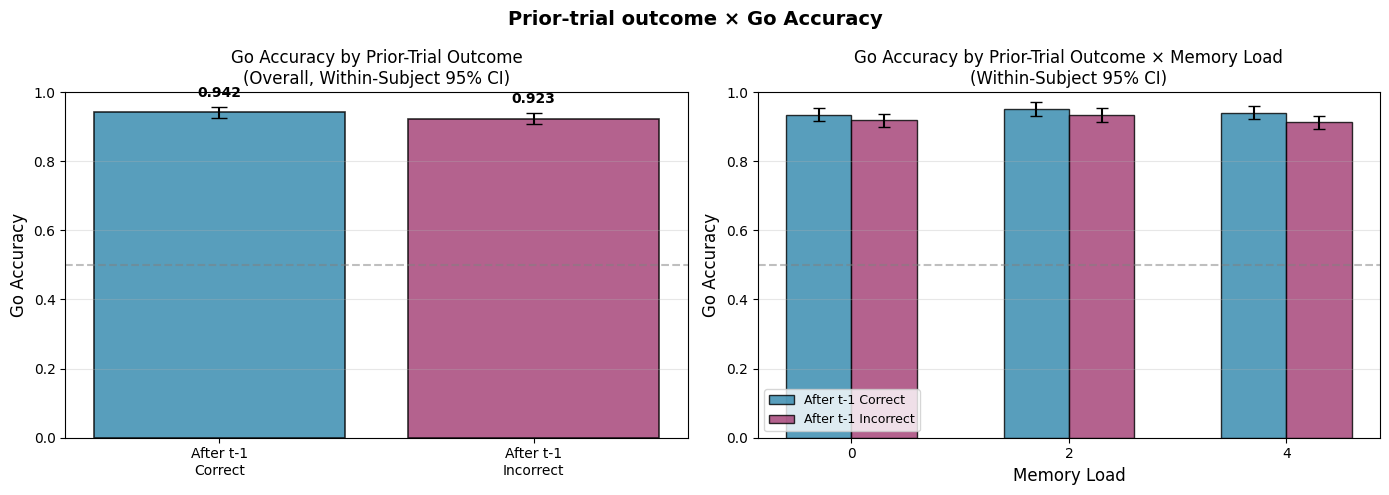


Note: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).


In [42]:
# === PRIOR-TRIAL OUTCOME AND GO ACCURACY ===
from scipy.stats import ttest_rel

trial_data_acc = trial_wise_data_wm.copy()
trial_data_acc = trial_data_acc.sort_values(['participant_id', 'block_num', 'current_trial']).reset_index(drop=True)

trial_data_acc['prev_trial_correct'] = (
    trial_data_acc
    .groupby(['participant_id', 'block_num'])['stop_trial_correct_trial']
    .shift(1)
)

trial_data_acc['is_stop'] = trial_data_acc['stop_trial_SS_trial_type'].str.lower() == 'stop'
trial_data_acc['go_correct'] = pd.to_numeric(trial_data_acc['stop_trial_correct_trial'], errors='coerce')

go_with_prev = trial_data_acc.loc[
    (~trial_data_acc['is_stop']) & trial_data_acc['prev_trial_correct'].notna() & trial_data_acc['go_correct'].notna()
].copy()

# Per-subject mean go accuracy by previous-trial outcome
subj_acc = (
    go_with_prev
    .groupby(['participant_id', 'prev_trial_correct'])
    .agg(mean_go_acc=('go_correct', 'mean'), n_trials=('go_correct', 'count'))
    .reset_index()
)

acc_after_correct = subj_acc.loc[subj_acc['prev_trial_correct'] == 1].set_index('participant_id')
acc_after_incorrect = subj_acc.loc[subj_acc['prev_trial_correct'] == 0].set_index('participant_id')
common_acc = acc_after_correct.index.intersection(acc_after_incorrect.index)
aac = acc_after_correct.loc[common_acc]
aai = acc_after_incorrect.loc[common_acc]

# Overall within-subject CI
overall_matrix_acc = pd.DataFrame({
    't-1 Correct': aac['mean_go_acc'].values,
    't-1 Incorrect': aai['mean_go_acc'].values,
})
ws_ci_acc = calculate_within_subject_ci(overall_matrix_acc)
means_acc = [overall_matrix_acc.iloc[:, c].mean() for c in range(2)]
cis_acc = [ws_ci_acc.iloc[c] if hasattr(ws_ci_acc, 'iloc') else ws_ci_acc[c] for c in range(2)]

# Paired t-test (overall)
n_acc = len(common_acc)
t_acc, p_acc = ttest_rel(aac['mean_go_acc'], aai['mean_go_acc'])
diff_acc = aac['mean_go_acc'].values - aai['mean_go_acc'].values
cd_acc = diff_acc.mean() / diff_acc.std() if diff_acc.std() > 0 else np.nan
print(f"Overall: Paired t-test: t({n_acc - 1}) = {t_acc:.3f}, p = {p_acc:.4f}, Cohen's d = {cd_acc:.3f}")
print("\nBy WM Load:")

# By WM load
wm_loads_acc = [0, 2, 4]
results_by_load_acc = {}
for wm_load in wm_loads_acc:
    load_data = go_with_prev.loc[go_with_prev['memory_trial_stimLength'] == wm_load]
    load_subj = (
        load_data
        .groupby(['participant_id', 'prev_trial_correct'])
        .agg(mean_go_acc=('go_correct', 'mean'))
        .reset_index()
    )
    lac = load_subj.loc[load_subj['prev_trial_correct'] == 1].set_index('participant_id')
    lai = load_subj.loc[load_subj['prev_trial_correct'] == 0].set_index('participant_id')
    lc = lac.index.intersection(lai.index)
    if len(lc) > 2:
        wm_matrix = pd.DataFrame({
            'correct': lac.loc[lc, 'mean_go_acc'].values,
            'incorrect': lai.loc[lc, 'mean_go_acc'].values,
        })
        ws_ci_wm = calculate_within_subject_ci(wm_matrix)
        results_by_load_acc[wm_load] = {
            'after_correct': {'mean': lac.loc[lc, 'mean_go_acc'].mean(), 'ci': ws_ci_wm.iloc[0] if hasattr(ws_ci_wm, 'iloc') else ws_ci_wm[0]},
            'after_incorrect': {'mean': lai.loc[lc, 'mean_go_acc'].mean(), 'ci': ws_ci_wm.iloc[1] if hasattr(ws_ci_wm, 'iloc') else ws_ci_wm[1]},
        }
        t_l, p_l = ttest_rel(lac.loc[lc, 'mean_go_acc'], lai.loc[lc, 'mean_go_acc'])
        d_l = lac.loc[lc, 'mean_go_acc'].values - lai.loc[lc, 'mean_go_acc'].values
        cd_l = d_l.mean() / d_l.std() if d_l.std() > 0 else np.nan
        print(f"  WM Load {wm_load}: Paired t-test: t({len(lc)-1}) = {t_l:.3f}, p = {p_l:.4f}, Cohen's d = {cd_l:.3f}")
    else:
        results_by_load_acc[wm_load] = {
            'after_correct': {'mean': lac['mean_go_acc'].mean(), 'ci': 0},
            'after_incorrect': {'mean': lai['mean_go_acc'].mean(), 'ci': 0},
        }

colors_lag = ['#2E86AB', '#A23B72']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Prior-trial outcome × Go Accuracy', fontsize=14, fontweight='bold')

# Plot 1: Overall
ax1 = axes[0]
cond_labels = ['After t-1\nCorrect', 'After t-1\nIncorrect']
bars = ax1.bar(cond_labels, means_acc, yerr=cis_acc, capsize=6, color=colors_lag, alpha=0.8,
               edgecolor='black', linewidth=1.2, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax1.set_ylabel('Go Accuracy', fontsize=12)
ax1.set_title('Go Accuracy by Prior-Trial Outcome\n(Overall, Within-Subject 95% CI)', fontsize=12)
ax1.set_ylim(0, 1)
ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax1.grid(True, alpha=0.3, axis='y')
for bar, mean, ci in zip(bars, means_acc, cis_acc):
    ax1.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + ci + 0.02,
             f'{mean:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 2: By WM Load
ax2 = axes[1]
x = np.arange(len(wm_loads_acc))
width = 0.3
correct_means = [results_by_load_acc[wm]['after_correct']['mean'] for wm in wm_loads_acc]
incorrect_means = [results_by_load_acc[wm]['after_incorrect']['mean'] for wm in wm_loads_acc]
correct_cis = [results_by_load_acc[wm]['after_correct']['ci'] for wm in wm_loads_acc]
incorrect_cis = [results_by_load_acc[wm]['after_incorrect']['ci'] for wm in wm_loads_acc]

ax2.bar(x - width/2, correct_means, width, yerr=correct_cis, capsize=4,
        label='After t-1 Correct', color=colors_lag[0], alpha=0.8,
        edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax2.bar(x + width/2, incorrect_means, width, yerr=incorrect_cis, capsize=4,
        label='After t-1 Incorrect', color=colors_lag[1], alpha=0.8,
        edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax2.set_xlabel('Memory Load', fontsize=12)
ax2.set_ylabel('Go Accuracy', fontsize=12)
ax2.set_title('Go Accuracy by Prior-Trial Outcome × Memory Load\n(Within-Subject 95% CI)', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(['0', '2', '4'])
ax2.set_ylim(0, 1)
ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax2.legend(loc='lower left', fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print("\nNote: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).")

## 21. Does Prior Probe Outcome Predict Next Probe Outcome?

Sequential dependency analysis: does the memory probe outcome on trial t-1 (correct vs. incorrect) predict the memory probe outcome on trial t?

- **t-1 Probe Correct → Probe trial t**: probe accuracy
- **t-1 Probe Incorrect → Probe trial t**: probe accuracy

Only consecutive trials *within the same block* are considered (no cross-block lag). Trial counts are reported because the conditions are likely unbalanced (most probes are correct).

> ⚠️ **Commission + omission errors are combined here.** The "probe incorrect" group (`memory_recognition_correct_trial == 0`) includes **both commission errors** (wrong response given, RT present) and **omission errors** (no response, RT is NaN). These are not distinguished in this analysis. See Sections 22–26 for omission-only analyses.

DOES PRIOR PROBE OUTCOME (trial t-1) PREDICT NEXT PROBE OUTCOME (trial t)?

--- OVERALL (collapsed across WM load) ---

Subjects with data in both conditions: 38

After t-1 Probe CORRECT:
  Probe accuracy (trial t): M = 0.926, SD = 0.064
  Avg probe trials per subject: 383.8  (range: 310-414)

After t-1 Probe INCORRECT:
  Probe accuracy (trial t): M = 0.850, SD = 0.190
  Avg probe trials per subject: 36.2  (range: 6-110)

Paired t-test: t(37) = 2.748, p = 0.0092, Cohen's d = 0.452

--- t-1 Probe Incorrect trials per participant (Section 21: probe trials) ---
                          t-1_probe_incorrect_trials
participant_id                                      
676a24c4766af0941f2060db                         110
6838df8389ee2a2823f6964a                         100
63f82a4ff43ec144ca3622a8                          97
67cb51b23d74b436185a20eb                          95
6640be7edc706d4622dbab1c                          90
583b397f54686200010f1d20                          83
5a09ebdf087

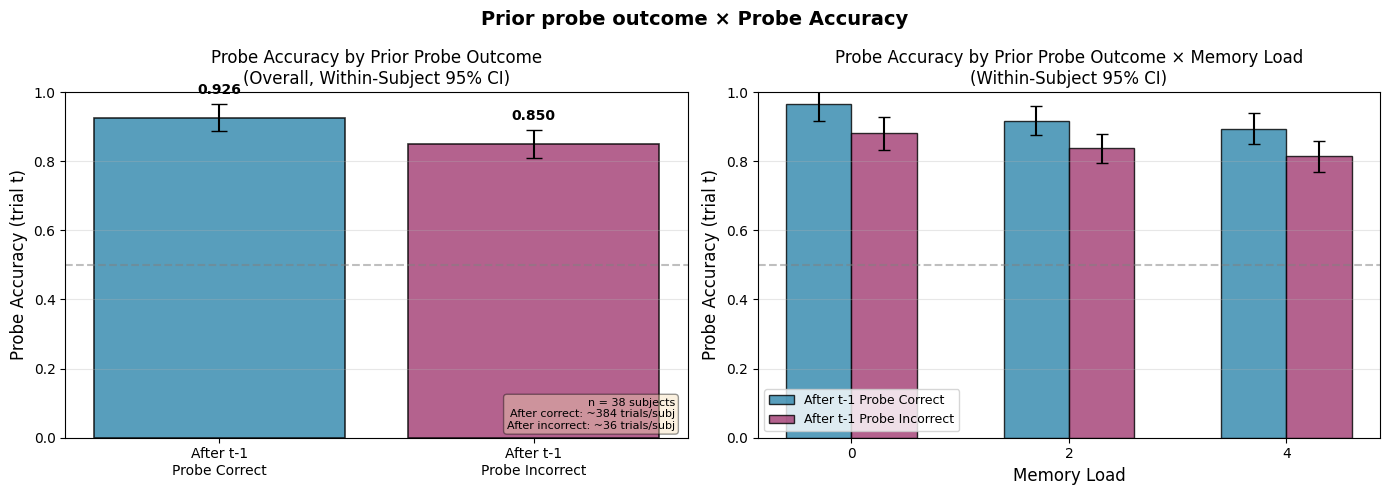


Note: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).
Trial counts are likely unbalanced because most probes are answered correctly.


In [43]:
# === DOES PRIOR PROBE OUTCOME (trial t-1) PREDICT NEXT PROBE OUTCOME (trial t)? ===
from scipy.stats import ttest_rel

trial_data_pp = trial_wise_data_wm.copy()
trial_data_pp = trial_data_pp.sort_values(['participant_id', 'block_num', 'current_trial']).reset_index(drop=True)

# Lag the probe accuracy within each subject × block
trial_data_pp['prev_probe_correct'] = (
    trial_data_pp
    .groupby(['participant_id', 'block_num'])['memory_recognition_correct_trial']
    .shift(1)
)

# Keep only probe trials (trial t) that have a valid previous-trial probe outcome (trial t-1)
probe_with_prev = trial_data_pp.loc[
    trial_data_pp['memory_recognition_correct_trial'].notna() & trial_data_pp['prev_probe_correct'].notna()
].copy()

print("=" * 70)
print("DOES PRIOR PROBE OUTCOME (trial t-1) PREDICT NEXT PROBE OUTCOME (trial t)?")
print("=" * 70)

# --- Overall (collapsed across WM load) ---
print("\n--- OVERALL (collapsed across WM load) ---\n")

subj_pp = (
    probe_with_prev
    .groupby(['participant_id', 'prev_probe_correct'])
    .agg(
        mean_probe_acc=('memory_recognition_correct_trial', 'mean'),
        n_trials=('memory_recognition_correct_trial', 'count'),
    )
    .reset_index()
)

pac = subj_pp.loc[subj_pp['prev_probe_correct'] == 1].set_index('participant_id')
pai = subj_pp.loc[subj_pp['prev_probe_correct'] == 0].set_index('participant_id')
common_pp = pac.index.intersection(pai.index)
pac = pac.loc[common_pp]
pai = pai.loc[common_pp]

n_pp = len(common_pp)
print(f"Subjects with data in both conditions: {n_pp}")
print(f"\nAfter t-1 Probe CORRECT:")
print(f"  Probe accuracy (trial t): M = {pac['mean_probe_acc'].mean():.3f}, SD = {pac['mean_probe_acc'].std():.3f}")
print(f"  Avg probe trials per subject: {pac['n_trials'].mean():.1f}  (range: {pac['n_trials'].min()}-{pac['n_trials'].max()})")

print(f"\nAfter t-1 Probe INCORRECT:")
print(f"  Probe accuracy (trial t): M = {pai['mean_probe_acc'].mean():.3f}, SD = {pai['mean_probe_acc'].std():.3f}")
print(f"  Avg probe trials per subject: {pai['n_trials'].mean():.1f}  (range: {pai['n_trials'].min()}-{pai['n_trials'].max()})")

# Paired t-test
t_pp, p_pp = ttest_rel(pac['mean_probe_acc'], pai['mean_probe_acc'])
diff_pp = pac['mean_probe_acc'].values - pai['mean_probe_acc'].values
cd_pp = diff_pp.mean() / diff_pp.std() if diff_pp.std() > 0 else np.nan
print(f"\nPaired t-test: t({n_pp - 1}) = {t_pp:.3f}, p = {p_pp:.4f}, Cohen's d = {cd_pp:.3f}")

# Per-participant t-1 probe incorrect trial counts (Section 21: probe trials)
print("\n--- t-1 Probe Incorrect trials per participant (Section 21: probe trials) ---")
pai_n = pai[['n_trials']].copy()
pai_n.columns = ['t-1_probe_incorrect_trials']
print(pai_n.sort_values('t-1_probe_incorrect_trials', ascending=False).to_string())

# --- By WM Load ---
print("\n" + "=" * 70)
print("BY MEMORY LOAD LEVEL")
print("=" * 70)

wm_loads_pp = [0, 2, 4]
results_by_load_pp = {}

for wm_load in wm_loads_pp:
    print(f"\n--- WM Load = {wm_load} ---\n")
    load_data = probe_with_prev.loc[probe_with_prev['memory_trial_stimLength'] == wm_load]

    load_subj = (
        load_data
        .groupby(['participant_id', 'prev_probe_correct'])
        .agg(mean_probe_acc=('memory_recognition_correct_trial', 'mean'), n_trials=('memory_recognition_correct_trial', 'count'))
        .reset_index()
    )
    lac = load_subj.loc[load_subj['prev_probe_correct'] == 1].set_index('participant_id')
    lai = load_subj.loc[load_subj['prev_probe_correct'] == 0].set_index('participant_id')
    lc = lac.index.intersection(lai.index)
    lac_c = lac.loc[lc]
    lai_c = lai.loc[lc]

    results_by_load_pp[wm_load] = {
        'after_correct':   {'mean': lac_c['mean_probe_acc'].mean(), 'ci': 0},
        'after_incorrect': {'mean': lai_c['mean_probe_acc'].mean(), 'ci': 0},
    }

    if len(lc) > 2:
        wm_matrix = pd.DataFrame({
            'correct': lac_c['mean_probe_acc'].values,
            'incorrect': lai_c['mean_probe_acc'].values,
        })
        ws_ci_wm = calculate_within_subject_ci(wm_matrix)
        results_by_load_pp[wm_load]['after_correct']['ci'] = ws_ci_wm.iloc[0] if hasattr(ws_ci_wm, 'iloc') else ws_ci_wm[0]
        results_by_load_pp[wm_load]['after_incorrect']['ci'] = ws_ci_wm.iloc[1] if hasattr(ws_ci_wm, 'iloc') else ws_ci_wm[1]
        t_l, p_l = ttest_rel(lac_c['mean_probe_acc'], lai_c['mean_probe_acc'])
        d_l = lac_c['mean_probe_acc'].values - lai_c['mean_probe_acc'].values
        cd_l = d_l.mean() / d_l.std() if d_l.std() > 0 else np.nan
        print(f"  Subjects with both conditions: {len(lc)}")
        print(f"  After t-1 Correct:   M = {lac_c['mean_probe_acc'].mean():.3f}, SD = {lac_c['mean_probe_acc'].std():.3f}, avg trials = {lac_c['n_trials'].mean():.1f}")
        print(f"  After t-1 Incorrect: M = {lai_c['mean_probe_acc'].mean():.3f}, SD = {lai_c['mean_probe_acc'].std():.3f}, avg trials = {lai_c['n_trials'].mean():.1f}")
        print(f"  Paired t-test: t({len(lc)-1}) = {t_l:.3f}, p = {p_l:.4f}, Cohen's d = {cd_l:.3f}")
    else:
        print(f"  Not enough subjects for paired t-test")

# --- Visualization ---
print("\n" + "=" * 70)
print("VISUALIZATION")
print("=" * 70)

colors_lag = ['#2E86AB', '#A23B72']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Prior probe outcome × Probe Accuracy', fontsize=14, fontweight='bold')

# Plot 1: Overall
ax1 = axes[0]
overall_matrix_pp = pd.DataFrame({
    't-1 Correct':   pac['mean_probe_acc'].values,
    't-1 Incorrect': pai['mean_probe_acc'].values,
})
ws_ci_pp = calculate_within_subject_ci(overall_matrix_pp)
means_pp = [overall_matrix_pp.iloc[:, c].mean() for c in range(2)]
cis_pp = [ws_ci_pp.iloc[c] if hasattr(ws_ci_pp, 'iloc') else ws_ci_pp[c] for c in range(2)]

cond_labels = ['After t-1\nProbe Correct', 'After t-1\nProbe Incorrect']
bars = ax1.bar(cond_labels, means_pp, yerr=cis_pp, capsize=6, color=colors_lag, alpha=0.8,
               edgecolor='black', linewidth=1.2, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax1.set_ylabel('Probe Accuracy (trial t)', fontsize=12)
ax1.set_title('Probe Accuracy by Prior Probe Outcome\n(Overall, Within-Subject 95% CI)', fontsize=12)
ax1.set_ylim(0, 1)
ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax1.grid(True, alpha=0.3, axis='y')

for bar, mean, ci in zip(bars, means_pp, cis_pp):
    ax1.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + ci + 0.02,
             f'{mean:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.text(0.98, 0.02,
         f'n = {n_pp} subjects\n'
         f'After correct: ~{pac["n_trials"].mean():.0f} trials/subj\n'
         f'After incorrect: ~{pai["n_trials"].mean():.0f} trials/subj',
         transform=ax1.transAxes, ha='right', va='bottom', fontsize=8,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.4))

# Plot 2: By WM Load
ax2 = axes[1]
x = np.arange(len(wm_loads_pp))
width = 0.3
correct_means = [results_by_load_pp[wm]['after_correct']['mean'] for wm in wm_loads_pp]
incorrect_means = [results_by_load_pp[wm]['after_incorrect']['mean'] for wm in wm_loads_pp]
correct_cis = [results_by_load_pp[wm]['after_correct']['ci'] for wm in wm_loads_pp]
incorrect_cis = [results_by_load_pp[wm]['after_incorrect']['ci'] for wm in wm_loads_pp]

ax2.bar(x - width/2, correct_means, width, yerr=correct_cis, capsize=4,
        label='After t-1 Probe Correct', color=colors_lag[0], alpha=0.8,
        edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax2.bar(x + width/2, incorrect_means, width, yerr=incorrect_cis, capsize=4,
        label='After t-1 Probe Incorrect', color=colors_lag[1], alpha=0.8,
        edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax2.set_xlabel('Memory Load', fontsize=12)
ax2.set_ylabel('Probe Accuracy (trial t)', fontsize=12)
ax2.set_title('Probe Accuracy by Prior Probe Outcome × Memory Load\n(Within-Subject 95% CI)', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(['0', '2', '4'])
ax2.set_ylim(0, 1)
ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax2.legend(loc='lower left', fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nNote: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).")
print("Trial counts are likely unbalanced because most probes are answered correctly.")

## 22. Does a Probe Omission on Trial t-1 Predict Stop Signal Success?

Sequential dependency analysis: does a probe omission (no response) on trial t-1 predict whether the participant successfully inhibits on a stop trial at trial t?

- **t-1 Probe Omission → Stop trial t**: stop success rate
- **t-1 Probe Response → Stop trial t**: stop success rate

Only consecutive trials *within the same block* are considered (no cross-block lag). Trial counts are reported because the conditions are likely unbalanced (most probes are answered).

DOES PROBE OMISSION ON TRIAL t-1 PREDICT STOP SUCCESS?

--- OVERALL (collapsed across WM load) ---

Subjects with data in both conditions: 25

After t-1 Probe OMISSION:
  Stop success rate: M = 0.696, SD = 0.298
  Avg stop trials per subject: 6.2  (range: 1-28)

After t-1 Probe RESPONSE:
  Stop success rate: M = 0.516, SD = 0.037
  Avg stop trials per subject: 133.5  (range: 112-143)

Paired t-test: t(24) = 2.978, p = 0.0065, Cohen's d = 0.608

--- t-1 Probe Omission trials per participant (Section 22: stop trials) ---
                          t-1_probe_omission_trials
participant_id                                     
676a24c4766af0941f2060db                         28
63f82a4ff43ec144ca3622a8                         16
6838df8389ee2a2823f6964a                         15
665762fdab6df18f5032505b                         13
67cb51b23d74b436185a20eb                         11
583b397f54686200010f1d20                         11
665f21efc77b50aba76c3258                          8
60c6cd8

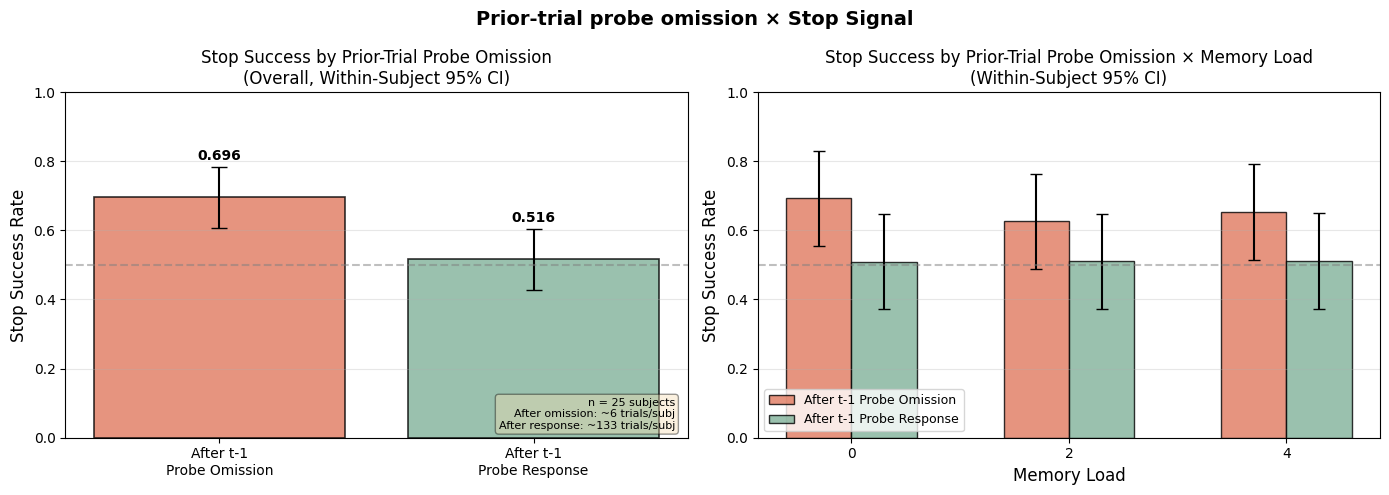


Note: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).
Trial counts are likely unbalanced because most probes are answered.


In [44]:
# === DOES PROBE OMISSION ON TRIAL t-1 PREDICT STOP SUCCESS? ===
from scipy.stats import ttest_rel

trial_data_om = trial_wise_data_wm.copy()
trial_data_om = trial_data_om.sort_values(['participant_id', 'block_num', 'current_trial']).reset_index(drop=True)

# Probe omission = no response (memory_recognition_rt is NaN)
trial_data_om['probe_omission'] = trial_data_om['memory_recognition_rt'].isna().astype(int)
trial_data_om['prev_probe_omission'] = (
    trial_data_om
    .groupby(['participant_id', 'block_num'])['probe_omission']
    .shift(1)
)

trial_data_om['is_stop'] = (trial_data_om['stop_trial_SS_trial_type'] == 'stop')
trial_data_om['stop_success'] = (
    trial_data_om['is_stop'] & (trial_data_om['stop_trial_correct_trial'] == 1)
).astype(float)

stop_with_om = trial_data_om.loc[
    trial_data_om['is_stop'] & trial_data_om['prev_probe_omission'].notna()
].copy()

print("=" * 70)
print("DOES PROBE OMISSION ON TRIAL t-1 PREDICT STOP SUCCESS?")
print("=" * 70)

# --- Overall ---
print("\n--- OVERALL (collapsed across WM load) ---\n")

subj_om = (
    stop_with_om
    .groupby(['participant_id', 'prev_probe_omission'])
    .agg(
        stop_success_rate=('stop_success', 'mean'),
        n_trials=('stop_success', 'count'),
    )
    .reset_index()
)

after_omission = subj_om.loc[subj_om['prev_probe_omission'] == 1].set_index('participant_id')
after_response = subj_om.loc[subj_om['prev_probe_omission'] == 0].set_index('participant_id')
common_om = after_omission.index.intersection(after_response.index)
ao = after_omission.loc[common_om]
ar = after_response.loc[common_om]

n_om = len(common_om)
print(f"Subjects with data in both conditions: {n_om}")
print(f"\nAfter t-1 Probe OMISSION:")
print(f"  Stop success rate: M = {ao['stop_success_rate'].mean():.3f}, SD = {ao['stop_success_rate'].std():.3f}")
print(f"  Avg stop trials per subject: {ao['n_trials'].mean():.1f}  (range: {ao['n_trials'].min()}-{ao['n_trials'].max()})")

print(f"\nAfter t-1 Probe RESPONSE:")
print(f"  Stop success rate: M = {ar['stop_success_rate'].mean():.3f}, SD = {ar['stop_success_rate'].std():.3f}")
print(f"  Avg stop trials per subject: {ar['n_trials'].mean():.1f}  (range: {ar['n_trials'].min()}-{ar['n_trials'].max()})")

t_om, p_om = ttest_rel(ao['stop_success_rate'], ar['stop_success_rate'])
diff_om = ao['stop_success_rate'].values - ar['stop_success_rate'].values
cd_om = diff_om.mean() / diff_om.std() if diff_om.std() > 0 else np.nan
print(f"\nPaired t-test: t({n_om - 1}) = {t_om:.3f}, p = {p_om:.4f}, Cohen's d = {cd_om:.3f}")

# Per-participant t-1 probe omission trial counts
print("\n--- t-1 Probe Omission trials per participant (Section 22: stop trials) ---")
ao_n = ao[['n_trials']].copy()
ao_n.columns = ['t-1_probe_omission_trials']
print(ao_n.sort_values('t-1_probe_omission_trials', ascending=False).to_string())

# --- By WM Load ---
print("\n" + "=" * 70)
print("BY MEMORY LOAD LEVEL")
print("=" * 70)

wm_loads_om = [0, 2, 4]
results_by_load_om = {}

for wm_load in wm_loads_om:
    print(f"\n--- WM Load = {wm_load} ---\n")
    load_data = stop_with_om.loc[stop_with_om['memory_trial_stimLength'] == wm_load]

    load_subj = (
        load_data
        .groupby(['participant_id', 'prev_probe_omission'])
        .agg(stop_success_rate=('stop_success', 'mean'), n_trials=('stop_success', 'count'))
        .reset_index()
    )
    lac = load_subj.loc[load_subj['prev_probe_omission'] == 1].set_index('participant_id')
    lai = load_subj.loc[load_subj['prev_probe_omission'] == 0].set_index('participant_id')
    lc = lac.index.intersection(lai.index)
    lac_c = lac.loc[lc]
    lai_c = lai.loc[lc]

    results_by_load_om[wm_load] = {
        'after_omission': {'mean': lac_c['stop_success_rate'].mean(), 'ci': 0},
        'after_response': {'mean': lai_c['stop_success_rate'].mean(), 'ci': 0},
    }

    if len(lc) > 2:
        wm_matrix = pd.DataFrame({
            'omission': lac_c['stop_success_rate'].values,
            'response': lai_c['stop_success_rate'].values,
        })
        ws_ci_wm = calculate_within_subject_ci(wm_matrix)
        results_by_load_om[wm_load]['after_omission']['ci'] = ws_ci_wm.iloc[0] if hasattr(ws_ci_wm, 'iloc') else ws_ci_wm[0]
        results_by_load_om[wm_load]['after_response']['ci'] = ws_ci_wm.iloc[1] if hasattr(ws_ci_wm, 'iloc') else ws_ci_wm[1]
        t_l, p_l = ttest_rel(lac_c['stop_success_rate'], lai_c['stop_success_rate'])
        d_l = lac_c['stop_success_rate'].values - lai_c['stop_success_rate'].values
        cd_l = d_l.mean() / d_l.std() if d_l.std() > 0 else np.nan
        print(f"  Subjects with both conditions: {len(lc)}")
        print(f"  After t-1 Omission: M = {lac_c['stop_success_rate'].mean():.3f}, SD = {lac_c['stop_success_rate'].std():.3f}, avg trials = {lac_c['n_trials'].mean():.1f}")
        print(f"  After t-1 Response: M = {lai_c['stop_success_rate'].mean():.3f}, SD = {lai_c['stop_success_rate'].std():.3f}, avg trials = {lai_c['n_trials'].mean():.1f}")
        print(f"  Paired t-test: t({len(lc)-1}) = {t_l:.3f}, p = {p_l:.4f}, Cohen's d = {cd_l:.3f}")
    else:
        print(f"  Not enough subjects for paired t-test")

# --- Visualization ---
print("\n" + "=" * 70)
print("VISUALIZATION")
print("=" * 70)

colors_om = ['#E07A5F', '#81B29A']  # omission vs response
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Prior-trial probe omission × Stop Signal', fontsize=14, fontweight='bold')

# Plot 1: Overall
ax1 = axes[0]
overall_matrix_om = pd.DataFrame({
    't-1 Omission': ao['stop_success_rate'].values,
    't-1 Response': ar['stop_success_rate'].values,
})
ws_ci_om = calculate_within_subject_ci(overall_matrix_om)
means_om = [overall_matrix_om.iloc[:, c].mean() for c in range(2)]
cis_om = [ws_ci_om.iloc[c] if hasattr(ws_ci_om, 'iloc') else ws_ci_om[c] for c in range(2)]

cond_labels = ['After t-1\nProbe Omission', 'After t-1\nProbe Response']
bars = ax1.bar(cond_labels, means_om, yerr=cis_om, capsize=6, color=colors_om, alpha=0.8,
               edgecolor='black', linewidth=1.2, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax1.set_ylabel('Stop Success Rate', fontsize=12)
ax1.set_title('Stop Success by Prior-Trial Probe Omission\n(Overall, Within-Subject 95% CI)', fontsize=12)
ax1.set_ylim(0, 1)
ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax1.grid(True, alpha=0.3, axis='y')

for bar, mean, ci in zip(bars, means_om, cis_om):
    ax1.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + ci + 0.01,
             f'{mean:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.text(0.98, 0.02,
         f'n = {n_om} subjects\n'
         f'After omission: ~{ao["n_trials"].mean():.0f} trials/subj\n'
         f'After response: ~{ar["n_trials"].mean():.0f} trials/subj',
         transform=ax1.transAxes, ha='right', va='bottom', fontsize=8,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.4))

# Plot 2: By WM Load
ax2 = axes[1]
x = np.arange(len(wm_loads_om))
width = 0.3
omission_means = [results_by_load_om[wm]['after_omission']['mean'] for wm in wm_loads_om]
response_means = [results_by_load_om[wm]['after_response']['mean'] for wm in wm_loads_om]
omission_cis = [results_by_load_om[wm]['after_omission']['ci'] for wm in wm_loads_om]
response_cis = [results_by_load_om[wm]['after_response']['ci'] for wm in wm_loads_om]

ax2.bar(x - width/2, omission_means, width, yerr=omission_cis, capsize=4,
        label='After t-1 Probe Omission', color=colors_om[0], alpha=0.8,
        edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax2.bar(x + width/2, response_means, width, yerr=response_cis, capsize=4,
        label='After t-1 Probe Response', color=colors_om[1], alpha=0.8,
        edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax2.set_xlabel('Memory Load', fontsize=12)
ax2.set_ylabel('Stop Success Rate', fontsize=12)
ax2.set_title('Stop Success by Prior-Trial Probe Omission × Memory Load\n(Within-Subject 95% CI)', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(['0', '2', '4'])
ax2.set_ylim(0, 1)
ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax2.legend(loc='lower left', fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nNote: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).")
print("Trial counts are likely unbalanced because most probes are answered.")

## 23. Does a Probe Omission on Trial t-1 Predict Go Omission?

Sequential dependency analysis: does a probe omission (no response) on trial t-1 predict whether the participant omits (fails to respond) on a go trial at trial t?

- **t-1 Probe Omission → Go trial t**: go omission rate
- **t-1 Probe Response → Go trial t**: go omission rate

Only consecutive trials *within the same block* are considered (no cross-block lag). Go omission = no response on the go trial (`stop_trial_rt` is NaN).

DOES PROBE OMISSION ON TRIAL t-1 PREDICT GO OMISSION?

--- OVERALL (collapsed across WM load) ---

Subjects with data in both conditions: 30

After t-1 Probe OMISSION:
  Go omission rate: M = 0.116, SD = 0.247
  Avg go trials per subject: 10.6  (range: 1-52)

After t-1 Probe RESPONSE:
  Go omission rate: M = 0.022, SD = 0.026
  Avg go trials per subject: 269.9  (range: 228-283)

Paired t-test: t(29) = 2.115, p = 0.0432, Cohen's d = 0.393

--- t-1 Probe Omission trials per participant (Section 23: go trials) ---
                          t-1_probe_omission_trials
participant_id                                     
676a24c4766af0941f2060db                         52
644f162cac2c2b8aa0583b89                         43
6838df8389ee2a2823f6964a                         33
63f82a4ff43ec144ca3622a8                         27
67cb51b23d74b436185a20eb                         24
665762fdab6df18f5032505b                         22
66fd930f1849a200d65a6996                         16
665f21efc77b50a

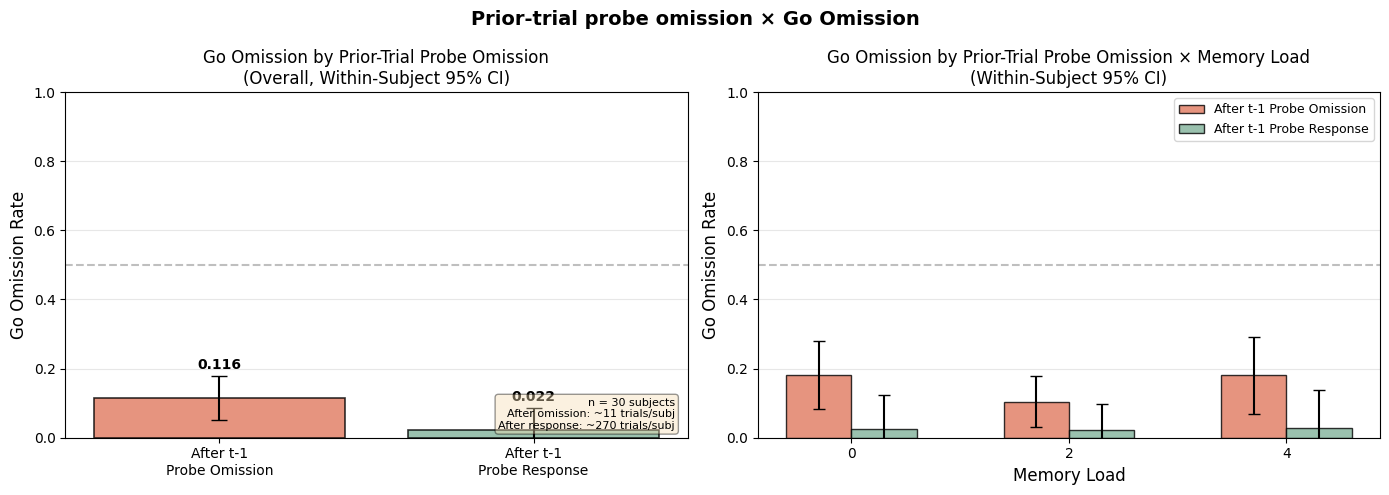


Note: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).
Trial counts are likely unbalanced because most probes are answered.


In [45]:
# === DOES PROBE OMISSION ON TRIAL t-1 PREDICT GO OMISSION? ===
from scipy.stats import ttest_rel

trial_data_goom = trial_wise_data_wm.copy()
trial_data_goom = trial_data_goom.sort_values(['participant_id', 'block_num', 'current_trial']).reset_index(drop=True)

# Probe omission = no response (memory_recognition_rt is NaN)
trial_data_goom['probe_omission'] = trial_data_goom['memory_recognition_rt'].isna().astype(int)
trial_data_goom['prev_probe_omission'] = (
    trial_data_goom
    .groupby(['participant_id', 'block_num'])['probe_omission']
    .shift(1)
)

trial_data_goom['is_go'] = (trial_data_goom['stop_trial_SS_trial_type'] == 'go')
trial_data_goom['go_omission'] = (
    trial_data_goom['is_go'] & trial_data_goom['stop_trial_rt'].isna()
).astype(float)

go_with_om = trial_data_goom.loc[
    trial_data_goom['is_go'] & trial_data_goom['prev_probe_omission'].notna()
].copy()

print("=" * 70)
print("DOES PROBE OMISSION ON TRIAL t-1 PREDICT GO OMISSION?")
print("=" * 70)

# --- Overall ---
print("\n--- OVERALL (collapsed across WM load) ---\n")

subj_goom = (
    go_with_om
    .groupby(['participant_id', 'prev_probe_omission'])
    .agg(
        go_omission_rate=('go_omission', 'mean'),
        n_trials=('go_omission', 'count'),
    )
    .reset_index()
)

after_om_go = subj_goom.loc[subj_goom['prev_probe_omission'] == 1].set_index('participant_id')
after_resp_go = subj_goom.loc[subj_goom['prev_probe_omission'] == 0].set_index('participant_id')
common_goom = after_om_go.index.intersection(after_resp_go.index)
aog = after_om_go.loc[common_goom]
arg = after_resp_go.loc[common_goom]

n_goom = len(common_goom)
print(f"Subjects with data in both conditions: {n_goom}")
print(f"\nAfter t-1 Probe OMISSION:")
print(f"  Go omission rate: M = {aog['go_omission_rate'].mean():.3f}, SD = {aog['go_omission_rate'].std():.3f}")
print(f"  Avg go trials per subject: {aog['n_trials'].mean():.1f}  (range: {aog['n_trials'].min()}-{aog['n_trials'].max()})")

print(f"\nAfter t-1 Probe RESPONSE:")
print(f"  Go omission rate: M = {arg['go_omission_rate'].mean():.3f}, SD = {arg['go_omission_rate'].std():.3f}")
print(f"  Avg go trials per subject: {arg['n_trials'].mean():.1f}  (range: {arg['n_trials'].min()}-{arg['n_trials'].max()})")

t_goom, p_goom = ttest_rel(aog['go_omission_rate'], arg['go_omission_rate'])
diff_goom = aog['go_omission_rate'].values - arg['go_omission_rate'].values
cd_goom = diff_goom.mean() / diff_goom.std() if diff_goom.std() > 0 else np.nan
print(f"\nPaired t-test: t({n_goom - 1}) = {t_goom:.3f}, p = {p_goom:.4f}, Cohen's d = {cd_goom:.3f}")

# Per-participant t-1 probe omission trial counts
print("\n--- t-1 Probe Omission trials per participant (Section 23: go trials) ---")
aog_n = aog[['n_trials']].copy()
aog_n.columns = ['t-1_probe_omission_trials']
print(aog_n.sort_values('t-1_probe_omission_trials', ascending=False).to_string())

# --- By WM Load ---
print("\n" + "=" * 70)
print("BY MEMORY LOAD LEVEL")
print("=" * 70)

wm_loads_goom = [0, 2, 4]
results_by_load_goom = {}

for wm_load in wm_loads_goom:
    print(f"\n--- WM Load = {wm_load} ---\n")
    load_data = go_with_om.loc[go_with_om['memory_trial_stimLength'] == wm_load]

    load_subj = (
        load_data
        .groupby(['participant_id', 'prev_probe_omission'])
        .agg(go_omission_rate=('go_omission', 'mean'), n_trials=('go_omission', 'count'))
        .reset_index()
    )
    loc = load_subj.loc[load_subj['prev_probe_omission'] == 1].set_index('participant_id')
    lorc = load_subj.loc[load_subj['prev_probe_omission'] == 0].set_index('participant_id')
    lc_goom = loc.index.intersection(lorc.index)
    loc_c = loc.loc[lc_goom]
    lorc_c = lorc.loc[lc_goom]

    results_by_load_goom[wm_load] = {
        'after_omission': {'mean': loc_c['go_omission_rate'].mean(), 'ci': 0},
        'after_response': {'mean': lorc_c['go_omission_rate'].mean(), 'ci': 0},
    }

    if len(lc_goom) > 2:
        wm_matrix = pd.DataFrame({
            'omission': loc_c['go_omission_rate'].values,
            'response': lorc_c['go_omission_rate'].values,
        })
        ws_ci_wm = calculate_within_subject_ci(wm_matrix)
        results_by_load_goom[wm_load]['after_omission']['ci'] = ws_ci_wm[0]
        results_by_load_goom[wm_load]['after_response']['ci'] = ws_ci_wm[1]
        t_l, p_l = ttest_rel(loc_c['go_omission_rate'], lorc_c['go_omission_rate'])
        d_l = loc_c['go_omission_rate'].values - lorc_c['go_omission_rate'].values
        cd_l = d_l.mean() / d_l.std() if d_l.std() > 0 else np.nan
        print(f"  Subjects with both conditions: {len(lc_goom)}")
        print(f"  After t-1 Omission: M = {loc_c['go_omission_rate'].mean():.3f}, SD = {loc_c['go_omission_rate'].std():.3f}, avg trials = {loc_c['n_trials'].mean():.1f}")
        print(f"  After t-1 Response: M = {lorc_c['go_omission_rate'].mean():.3f}, SD = {lorc_c['go_omission_rate'].std():.3f}, avg trials = {lorc_c['n_trials'].mean():.1f}")
        print(f"  Paired t-test: t({len(lc_goom)-1}) = {t_l:.3f}, p = {p_l:.4f}, Cohen's d = {cd_l:.3f}")
    else:
        print(f"  Not enough subjects for paired t-test")

# --- Visualization ---
print("\n" + "=" * 70)
print("VISUALIZATION")
print("=" * 70)

colors_goom = ['#E07A5F', '#81B29A']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Prior-trial probe omission × Go Omission', fontsize=14, fontweight='bold')

# Plot 1: Overall
ax1 = axes[0]
overall_matrix_goom = pd.DataFrame({
    't-1 Omission': aog['go_omission_rate'].values,
    't-1 Response': arg['go_omission_rate'].values,
})
ws_ci_goom = calculate_within_subject_ci(overall_matrix_goom)
means_goom = [overall_matrix_goom.iloc[:, c].mean() for c in range(2)]
cis_goom = [ws_ci_goom[c] for c in range(2)]

cond_labels = ['After t-1\nProbe Omission', 'After t-1\nProbe Response']
bars = ax1.bar(cond_labels, means_goom, yerr=cis_goom, capsize=6, color=colors_goom, alpha=0.8,
               edgecolor='black', linewidth=1.2, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax1.set_ylabel('Go Omission Rate', fontsize=12)
ax1.set_title('Go Omission by Prior-Trial Probe Omission\n(Overall, Within-Subject 95% CI)', fontsize=12)
ax1.set_ylim(0, 1)
ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax1.grid(True, alpha=0.3, axis='y')

for bar, mean, ci in zip(bars, means_goom, cis_goom):
    ax1.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + ci + 0.01,
             f'{mean:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.text(0.98, 0.02,
         f'n = {n_goom} subjects\n'
         f'After omission: ~{aog["n_trials"].mean():.0f} trials/subj\n'
         f'After response: ~{arg["n_trials"].mean():.0f} trials/subj',
         transform=ax1.transAxes, ha='right', va='bottom', fontsize=8,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.4))

# Plot 2: By WM Load
ax2 = axes[1]
x = np.arange(len(wm_loads_goom))
width = 0.3
omission_means = [results_by_load_goom[wm]['after_omission']['mean'] for wm in wm_loads_goom]
response_means = [results_by_load_goom[wm]['after_response']['mean'] for wm in wm_loads_goom]
omission_cis = [results_by_load_goom[wm]['after_omission']['ci'] for wm in wm_loads_goom]
response_cis = [results_by_load_goom[wm]['after_response']['ci'] for wm in wm_loads_goom]

ax2.bar(x - width/2, omission_means, width, yerr=omission_cis, capsize=4,
        label='After t-1 Probe Omission', color=colors_goom[0], alpha=0.8,
        edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax2.bar(x + width/2, response_means, width, yerr=response_cis, capsize=4,
        label='After t-1 Probe Response', color=colors_goom[1], alpha=0.8,
        edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax2.set_xlabel('Memory Load', fontsize=12)
ax2.set_ylabel('Go Omission Rate', fontsize=12)
ax2.set_title('Go Omission by Prior-Trial Probe Omission × Memory Load\n(Within-Subject 95% CI)', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(['0', '2', '4'])
ax2.set_ylim(0, 1)
ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nNote: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).")
print("Trial counts are likely unbalanced because most probes are answered.")

## 24. Does a Probe Omission on Trial t-1 Predict Go RT?

Sequential dependency analysis: does a probe omission (no response) on trial t-1 predict **mean go trial RT** on trial t?

- **t-1 Probe Omission → Go trial t**: mean RT (ms)
- **t-1 Probe Response → Go trial t**: mean RT (ms)

Only consecutive trials *within the same block* are considered. Go trials with valid RT (non-omission) only.

DOES PROBE OMISSION ON TRIAL t-1 PREDICT GO RT?

--- OVERALL (collapsed across WM load) ---

Subjects with data in both conditions: 30

After t-1 Probe OMISSION: M = 753 ms, SD = 135
After t-1 Probe RESPONSE: M = 744 ms, SD = 133

Paired t-test: t(29) = 0.441, p = 0.6622, Cohen's d = 0.082

--- t-1 Probe Omission trials per participant (Section 24: go RT trials) ---
                          t-1_probe_omission_trials
participant_id                                     
644f162cac2c2b8aa0583b89                         41
6838df8389ee2a2823f6964a                         32
63f82a4ff43ec144ca3622a8                         21
67cb51b23d74b436185a20eb                         18
665f21efc77b50aba76c3258                         16
66fd930f1849a200d65a6996                         16
676a24c4766af0941f2060db                         12
663a6a13c0b6b4aff21552f8                         12
6640be7edc706d4622dbab1c                         11
67709ec28bdf0084bd3b231b                          6
5ff07b5

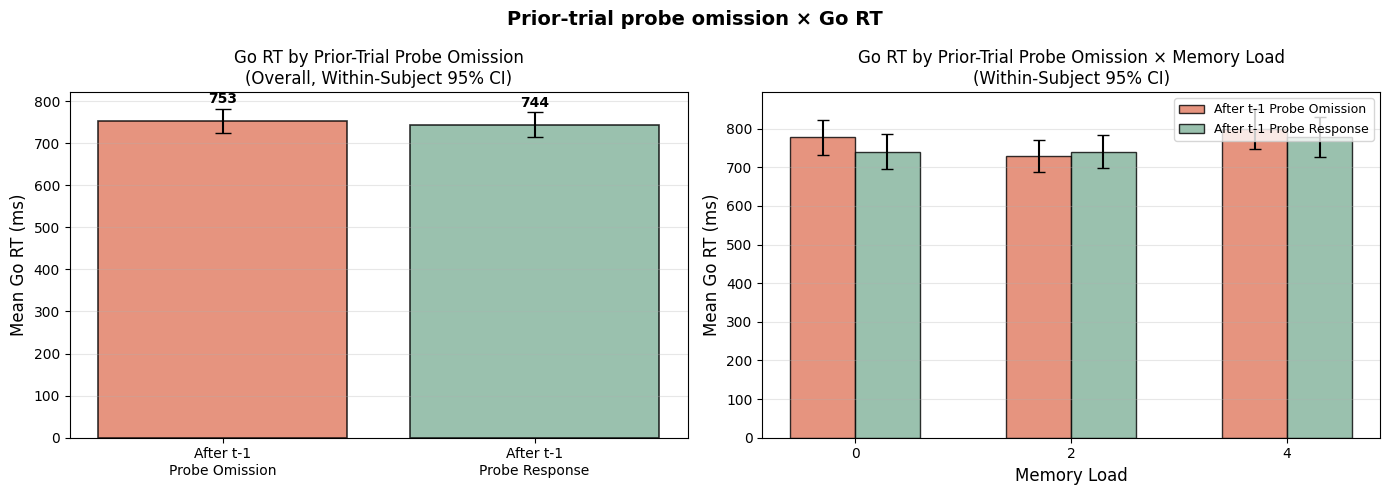


Note: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).


In [46]:
# === DOES PROBE OMISSION ON TRIAL t-1 PREDICT GO RT? ===
from scipy.stats import ttest_rel

trial_data_rt = trial_wise_data_wm.copy()
trial_data_rt = trial_data_rt.sort_values(['participant_id', 'block_num', 'current_trial']).reset_index(drop=True)

trial_data_rt['probe_omission'] = trial_data_rt['memory_recognition_rt'].isna().astype(int)
trial_data_rt['prev_probe_omission'] = (
    trial_data_rt.groupby(['participant_id', 'block_num'])['probe_omission'].shift(1)
)

trial_data_rt['is_go'] = (trial_data_rt['stop_trial_SS_trial_type'] == 'go')
trial_data_rt['go_rt'] = pd.to_numeric(trial_data_rt['stop_trial_rt'], errors='coerce')

# Only go trials with valid RT (exclude go omissions)
go_rt_data = trial_data_rt.loc[
    trial_data_rt['is_go'] & trial_data_rt['go_rt'].notna() & trial_data_rt['prev_probe_omission'].notna()
].copy()

print("=" * 70)
print("DOES PROBE OMISSION ON TRIAL t-1 PREDICT GO RT?")
print("=" * 70)
print("\n--- OVERALL (collapsed across WM load) ---\n")

subj_rt = (
    go_rt_data
    .groupby(['participant_id', 'prev_probe_omission'])
    .agg(mean_go_rt=('go_rt', 'mean'), n_trials=('go_rt', 'count'))
    .reset_index()
)

rt_after_om = subj_rt.loc[subj_rt['prev_probe_omission'] == 1].set_index('participant_id')
rt_after_resp = subj_rt.loc[subj_rt['prev_probe_omission'] == 0].set_index('participant_id')
common_rt = rt_after_om.index.intersection(rt_after_resp.index)
rao = rt_after_om.loc[common_rt]
rar = rt_after_resp.loc[common_rt]

n_rt = len(common_rt)
print(f"Subjects with data in both conditions: {n_rt}")
print(f"\nAfter t-1 Probe OMISSION: M = {rao['mean_go_rt'].mean():.0f} ms, SD = {rao['mean_go_rt'].std():.0f}")
print(f"After t-1 Probe RESPONSE: M = {rar['mean_go_rt'].mean():.0f} ms, SD = {rar['mean_go_rt'].std():.0f}")

t_rt, p_rt = ttest_rel(rao['mean_go_rt'], rar['mean_go_rt'])
diff_rt = rao['mean_go_rt'].values - rar['mean_go_rt'].values
cd_rt = diff_rt.mean() / diff_rt.std() if diff_rt.std() > 0 else np.nan
print(f"\nPaired t-test: t({n_rt - 1}) = {t_rt:.3f}, p = {p_rt:.4f}, Cohen's d = {cd_rt:.3f}")

# Per-participant t-1 probe omission trial counts
print("\n--- t-1 Probe Omission trials per participant (Section 24: go RT trials) ---")
rao_n = rao[['n_trials']].copy()
rao_n.columns = ['t-1_probe_omission_trials']
print(rao_n.sort_values('t-1_probe_omission_trials', ascending=False).to_string())

# --- By WM Load ---
print("\n" + "=" * 70)
print("BY MEMORY LOAD LEVEL")
print("=" * 70)

wm_loads_rt = [0, 2, 4]
results_by_load_rt = {}

for wm_load in wm_loads_rt:
    print(f"\n--- WM Load = {wm_load} ---\n")
    load_data = go_rt_data.loc[go_rt_data['memory_trial_stimLength'] == wm_load]
    load_subj = (
        load_data.groupby(['participant_id', 'prev_probe_omission'])
        .agg(mean_go_rt=('go_rt', 'mean'), n_trials=('go_rt', 'count'))
        .reset_index()
    )
    loc = load_subj.loc[load_subj['prev_probe_omission'] == 1].set_index('participant_id')
    lorc = load_subj.loc[load_subj['prev_probe_omission'] == 0].set_index('participant_id')
    lc_rt = loc.index.intersection(lorc.index)
    loc_c = loc.loc[lc_rt]
    lorc_c = lorc.loc[lc_rt]

    results_by_load_rt[wm_load] = {
        'after_omission': {'mean': loc_c['mean_go_rt'].mean(), 'ci': 0},
        'after_response': {'mean': lorc_c['mean_go_rt'].mean(), 'ci': 0},
    }

    if len(lc_rt) > 2:
        wm_matrix = pd.DataFrame({
            'omission': loc_c['mean_go_rt'].values,
            'response': lorc_c['mean_go_rt'].values,
        })
        ws_ci_wm = calculate_within_subject_ci(wm_matrix)
        results_by_load_rt[wm_load]['after_omission']['ci'] = np.asarray(ws_ci_wm)[0]
        results_by_load_rt[wm_load]['after_response']['ci'] = np.asarray(ws_ci_wm)[1]
        t_l, p_l = ttest_rel(loc_c['mean_go_rt'], lorc_c['mean_go_rt'])
        d_l = loc_c['mean_go_rt'].values - lorc_c['mean_go_rt'].values
        cd_l = d_l.mean() / d_l.std() if d_l.std() > 0 else np.nan
        print(f"  Subjects with both conditions: {len(lc_rt)}")
        print(f"  After t-1 Omission: M = {loc_c['mean_go_rt'].mean():.0f} ms")
        print(f"  After t-1 Response: M = {lorc_c['mean_go_rt'].mean():.0f} ms")
        print(f"  Paired t-test: t({len(lc_rt)-1}) = {t_l:.3f}, p = {p_l:.4f}, Cohen's d = {cd_l:.3f}")

# --- Visualization ---
print("\n" + "=" * 70)
print("VISUALIZATION")
print("=" * 70)

colors_rt = ['#E07A5F', '#81B29A']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Prior-trial probe omission × Go RT', fontsize=14, fontweight='bold')

overall_matrix_rt = pd.DataFrame({
    't-1 Omission': rao['mean_go_rt'].values,
    't-1 Response': rar['mean_go_rt'].values,
})
ws_ci_rt = calculate_within_subject_ci(overall_matrix_rt)
means_rt = [overall_matrix_rt.iloc[:, c].mean() for c in range(2)]
cis_rt = [np.asarray(ws_ci_rt)[c] for c in range(2)]

cond_labels = ['After t-1\nProbe Omission', 'After t-1\nProbe Response']
ax1 = axes[0]
bars = ax1.bar(cond_labels, means_rt, yerr=cis_rt, capsize=6, color=colors_rt, alpha=0.8,
               edgecolor='black', linewidth=1.2, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax1.set_ylabel('Mean Go RT (ms)', fontsize=12)
ax1.set_title('Go RT by Prior-Trial Probe Omission\n(Overall, Within-Subject 95% CI)', fontsize=12)
ax1.grid(True, alpha=0.3, axis='y')
for bar, mean, ci in zip(bars, means_rt, cis_rt):
    ax1.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + ci + 5,
             f'{mean:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2 = axes[1]
x = np.arange(len(wm_loads_rt))
width = 0.3
omission_means = [results_by_load_rt[wm]['after_omission']['mean'] for wm in wm_loads_rt]
response_means = [results_by_load_rt[wm]['after_response']['mean'] for wm in wm_loads_rt]
omission_cis = [results_by_load_rt[wm]['after_omission']['ci'] for wm in wm_loads_rt]
response_cis = [results_by_load_rt[wm]['after_response']['ci'] for wm in wm_loads_rt]

ax2.bar(x - width/2, omission_means, width, yerr=omission_cis, capsize=4,
        label='After t-1 Probe Omission', color=colors_rt[0], alpha=0.8,
        edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax2.bar(x + width/2, response_means, width, yerr=response_cis, capsize=4,
        label='After t-1 Probe Response', color=colors_rt[1], alpha=0.8,
        edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax2.set_xlabel('Memory Load', fontsize=12)
ax2.set_ylabel('Mean Go RT (ms)', fontsize=12)
ax2.set_title('Go RT by Prior-Trial Probe Omission × Memory Load\n(Within-Subject 95% CI)', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(['0', '2', '4'])
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print("\nNote: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).")

## 25. Does a Probe Omission on Trial t-1 Predict SSD?

Sequential dependency analysis: does a probe omission (no response) on trial t-1 predict **mean SSD** (stop-signal delay) on a stop trial at trial t?

- **t-1 Probe Omission → Stop trial t**: mean SSD (ms)
- **t-1 Probe Response → Stop trial t**: mean SSD (ms)

Only consecutive trials *within the same block* are considered.

DOES PROBE OMISSION ON TRIAL t-1 PREDICT SSD?

--- OVERALL (collapsed across WM load) ---

Subjects with data in both conditions: 25

After t-1 Probe OMISSION: M = 467 ms, SD = 179
After t-1 Probe RESPONSE: M = 466 ms, SD = 143

Paired t-test: t(24) = 0.085, p = 0.9332, Cohen's d = 0.017

--- t-1 Probe Omission trials per participant (Section 25: stop trials) ---
                          t-1_probe_omission_trials
participant_id                                     
676a24c4766af0941f2060db                         28
63f82a4ff43ec144ca3622a8                         16
6838df8389ee2a2823f6964a                         15
665762fdab6df18f5032505b                         13
67cb51b23d74b436185a20eb                         11
583b397f54686200010f1d20                         11
665f21efc77b50aba76c3258                          8
60c6cd8bacdf5d1f27924048                          7
644f162cac2c2b8aa0583b89                          6
66fd930f1849a200d65a6996                          6
5a09ebdf08

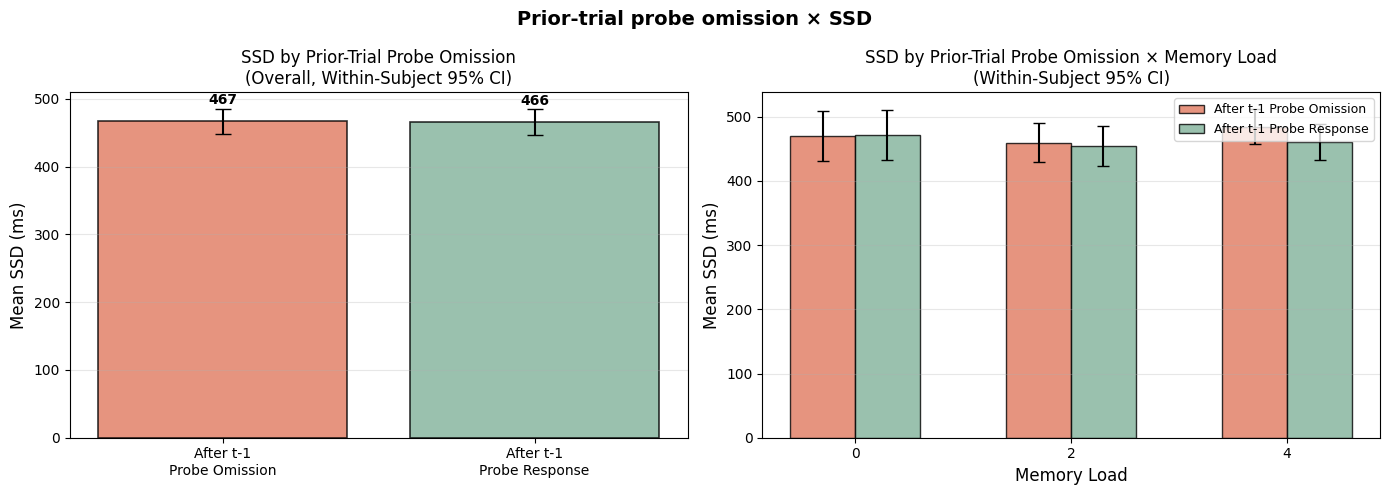


Note: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).


In [47]:
# === DOES PROBE OMISSION ON TRIAL t-1 PREDICT SSD? ===
from scipy.stats import ttest_rel

trial_data_ssd = trial_wise_data_wm.copy()
trial_data_ssd = trial_data_ssd.sort_values(['participant_id', 'block_num', 'current_trial']).reset_index(drop=True)

trial_data_ssd['probe_omission'] = trial_data_ssd['memory_recognition_rt'].isna().astype(int)
trial_data_ssd['prev_probe_omission'] = (
    trial_data_ssd.groupby(['participant_id', 'block_num'])['probe_omission'].shift(1)
)

trial_data_ssd['is_stop'] = (trial_data_ssd['stop_trial_SS_trial_type'] == 'stop')
trial_data_ssd['SSD'] = pd.to_numeric(trial_data_ssd['stop_trial_SSD'], errors='coerce')

stop_ssd_data = trial_data_ssd.loc[
    trial_data_ssd['is_stop'] & trial_data_ssd['SSD'].notna() & trial_data_ssd['prev_probe_omission'].notna()
].copy()

print("=" * 70)
print("DOES PROBE OMISSION ON TRIAL t-1 PREDICT SSD?")
print("=" * 70)
print("\n--- OVERALL (collapsed across WM load) ---\n")

subj_ssd = (
    stop_ssd_data
    .groupby(['participant_id', 'prev_probe_omission'])
    .agg(mean_SSD=('SSD', 'mean'), n_trials=('SSD', 'count'))
    .reset_index()
)

ssd_after_om = subj_ssd.loc[subj_ssd['prev_probe_omission'] == 1].set_index('participant_id')
ssd_after_resp = subj_ssd.loc[subj_ssd['prev_probe_omission'] == 0].set_index('participant_id')
common_ssd = ssd_after_om.index.intersection(ssd_after_resp.index)
sao = ssd_after_om.loc[common_ssd]
sar = ssd_after_resp.loc[common_ssd]

n_ssd = len(common_ssd)
print(f"Subjects with data in both conditions: {n_ssd}")
print(f"\nAfter t-1 Probe OMISSION: M = {sao['mean_SSD'].mean():.0f} ms, SD = {sao['mean_SSD'].std():.0f}")
print(f"After t-1 Probe RESPONSE: M = {sar['mean_SSD'].mean():.0f} ms, SD = {sar['mean_SSD'].std():.0f}")

t_ssd, p_ssd = ttest_rel(sao['mean_SSD'], sar['mean_SSD'])
diff_ssd = sao['mean_SSD'].values - sar['mean_SSD'].values
cd_ssd = diff_ssd.mean() / diff_ssd.std() if diff_ssd.std() > 0 else np.nan
print(f"\nPaired t-test: t({n_ssd - 1}) = {t_ssd:.3f}, p = {p_ssd:.4f}, Cohen's d = {cd_ssd:.3f}")

# Per-participant t-1 probe omission trial counts
print("\n--- t-1 Probe Omission trials per participant (Section 25: stop trials) ---")
sao_n = sao[['n_trials']].copy()
sao_n.columns = ['t-1_probe_omission_trials']
print(sao_n.sort_values('t-1_probe_omission_trials', ascending=False).to_string())

# --- By WM Load ---
print("\n" + "=" * 70)
print("BY MEMORY LOAD LEVEL")
print("=" * 70)

wm_loads_ssd = [0, 2, 4]
results_by_load_ssd = {}

for wm_load in wm_loads_ssd:
    print(f"\n--- WM Load = {wm_load} ---\n")
    load_data = stop_ssd_data.loc[stop_ssd_data['memory_trial_stimLength'] == wm_load]
    load_subj = (
        load_data.groupby(['participant_id', 'prev_probe_omission'])
        .agg(mean_SSD=('SSD', 'mean'), n_trials=('SSD', 'count'))
        .reset_index()
    )
    loc = load_subj.loc[load_subj['prev_probe_omission'] == 1].set_index('participant_id')
    lorc = load_subj.loc[load_subj['prev_probe_omission'] == 0].set_index('participant_id')
    lc_ssd = loc.index.intersection(lorc.index)
    loc_c = loc.loc[lc_ssd]
    lorc_c = lorc.loc[lc_ssd]

    results_by_load_ssd[wm_load] = {
        'after_omission': {'mean': loc_c['mean_SSD'].mean(), 'ci': 0},
        'after_response': {'mean': lorc_c['mean_SSD'].mean(), 'ci': 0},
    }

    if len(lc_ssd) > 2:
        wm_matrix = pd.DataFrame({
            'omission': loc_c['mean_SSD'].values,
            'response': lorc_c['mean_SSD'].values,
        })
        ws_ci_wm = calculate_within_subject_ci(wm_matrix)
        results_by_load_ssd[wm_load]['after_omission']['ci'] = np.asarray(ws_ci_wm)[0]
        results_by_load_ssd[wm_load]['after_response']['ci'] = np.asarray(ws_ci_wm)[1]
        t_l, p_l = ttest_rel(loc_c['mean_SSD'], lorc_c['mean_SSD'])
        d_l = loc_c['mean_SSD'].values - lorc_c['mean_SSD'].values
        cd_l = d_l.mean() / d_l.std() if d_l.std() > 0 else np.nan
        print(f"  Subjects with both conditions: {len(lc_ssd)}")
        print(f"  After t-1 Omission: M = {loc_c['mean_SSD'].mean():.0f} ms")
        print(f"  After t-1 Response: M = {lorc_c['mean_SSD'].mean():.0f} ms")
        print(f"  Paired t-test: t({len(lc_ssd)-1}) = {t_l:.3f}, p = {p_l:.4f}, Cohen's d = {cd_l:.3f}")

# --- Visualization ---
print("\n" + "=" * 70)
print("VISUALIZATION")
print("=" * 70)

colors_ssd = ['#E07A5F', '#81B29A']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Prior-trial probe omission × SSD', fontsize=14, fontweight='bold')

overall_matrix_ssd = pd.DataFrame({
    't-1 Omission': sao['mean_SSD'].values,
    't-1 Response': sar['mean_SSD'].values,
})
ws_ci_ssd = calculate_within_subject_ci(overall_matrix_ssd)
means_ssd = [overall_matrix_ssd.iloc[:, c].mean() for c in range(2)]
cis_ssd = [np.asarray(ws_ci_ssd)[c] for c in range(2)]

cond_labels = ['After t-1\nProbe Omission', 'After t-1\nProbe Response']
ax1 = axes[0]
bars = ax1.bar(cond_labels, means_ssd, yerr=cis_ssd, capsize=6, color=colors_ssd, alpha=0.8,
               edgecolor='black', linewidth=1.2, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax1.set_ylabel('Mean SSD (ms)', fontsize=12)
ax1.set_title('SSD by Prior-Trial Probe Omission\n(Overall, Within-Subject 95% CI)', fontsize=12)
ax1.grid(True, alpha=0.3, axis='y')
for bar, mean, ci in zip(bars, means_ssd, cis_ssd):
    ax1.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + ci + 2,
             f'{mean:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2 = axes[1]
x = np.arange(len(wm_loads_ssd))
width = 0.3
omission_means = [results_by_load_ssd[wm]['after_omission']['mean'] for wm in wm_loads_ssd]
response_means = [results_by_load_ssd[wm]['after_response']['mean'] for wm in wm_loads_ssd]
omission_cis = [results_by_load_ssd[wm]['after_omission']['ci'] for wm in wm_loads_ssd]
response_cis = [results_by_load_ssd[wm]['after_response']['ci'] for wm in wm_loads_ssd]

ax2.bar(x - width/2, omission_means, width, yerr=omission_cis, capsize=4,
        label='After t-1 Probe Omission', color=colors_ssd[0], alpha=0.8,
        edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax2.bar(x + width/2, response_means, width, yerr=response_cis, capsize=4,
        label='After t-1 Probe Response', color=colors_ssd[1], alpha=0.8,
        edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax2.set_xlabel('Memory Load', fontsize=12)
ax2.set_ylabel('Mean SSD (ms)', fontsize=12)
ax2.set_title('SSD by Prior-Trial Probe Omission × Memory Load\n(Within-Subject 95% CI)', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(['0', '2', '4'])
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print("\nNote: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).")

## 26. Does a Probe Omission on Trial t-1 Predict Next Probe Omission?

Sequential dependency analysis: does a probe omission (no response) on trial t-1 predict whether the participant omits on the **next** probe trial (trial t)?

- **t-1 Probe Omission → Probe trial t**: probe omission rate
- **t-1 Probe Response → Probe trial t**: probe omission rate

Only consecutive trials *within the same block* are considered. All trials have a probe; outcome = whether the participant responded on trial t.

DOES PROBE OMISSION ON TRIAL t-1 PREDICT NEXT PROBE OMISSION?

--- OVERALL (collapsed across WM load) ---

Subjects with data in both conditions: 32

After t-1 Probe OMISSION: M = 0.135, SD = 0.249
After t-1 Probe RESPONSE: M = 0.024, SD = 0.029

Paired t-test: t(31) = 2.569, p = 0.0153, Cohen's d = 0.461

--- t-1 Probe Omission trials per participant (Section 26: probe trials) ---
                          t-1_probe_omission_trials
participant_id                                     
676a24c4766af0941f2060db                         80
644f162cac2c2b8aa0583b89                         49
6838df8389ee2a2823f6964a                         48
63f82a4ff43ec144ca3622a8                         43
67cb51b23d74b436185a20eb                         35
665762fdab6df18f5032505b                         35
665f21efc77b50aba76c3258                         24
66fd930f1849a200d65a6996                         22
663a6a13c0b6b4aff21552f8                         16
583b397f54686200010f1d20                   

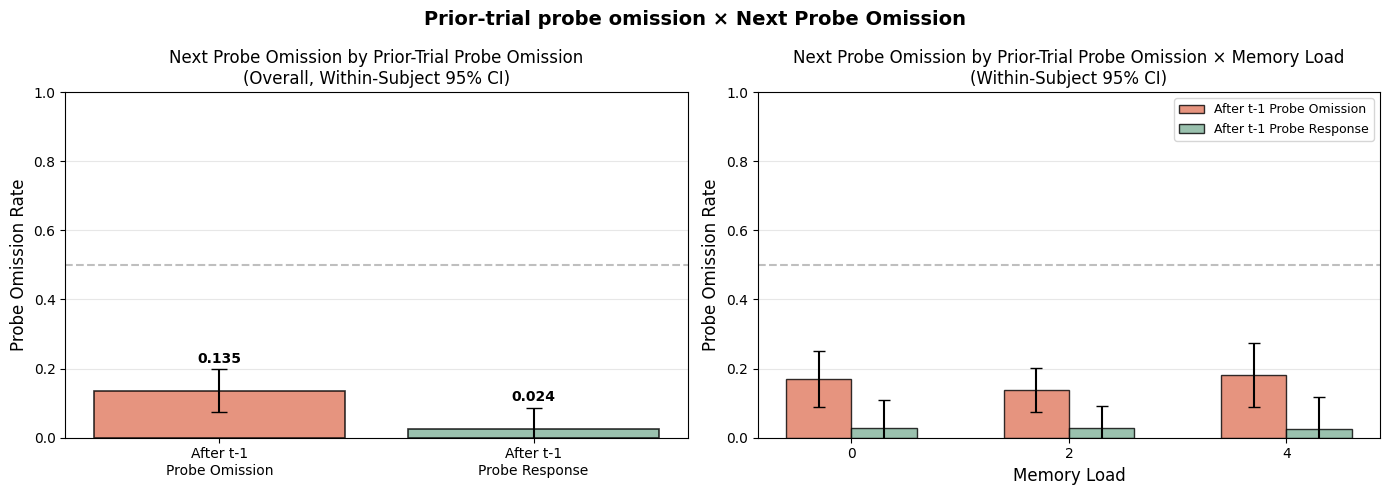


Note: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).


In [48]:
# === DOES PROBE OMISSION ON TRIAL t-1 PREDICT NEXT PROBE OMISSION? ===
from scipy.stats import ttest_rel

trial_data_next = trial_wise_data_wm.copy()
trial_data_next = trial_data_next.sort_values(['participant_id', 'block_num', 'current_trial']).reset_index(drop=True)

trial_data_next['probe_omission'] = trial_data_next['memory_recognition_rt'].isna().astype(int)
trial_data_next['prev_probe_omission'] = (
    trial_data_next.groupby(['participant_id', 'block_num'])['probe_omission'].shift(1)
)

probe_next_data = trial_data_next.loc[trial_data_next['prev_probe_omission'].notna()].copy()

print("=" * 70)
print("DOES PROBE OMISSION ON TRIAL t-1 PREDICT NEXT PROBE OMISSION?")
print("=" * 70)
print("\n--- OVERALL (collapsed across WM load) ---\n")

subj_next = (
    probe_next_data
    .groupby(['participant_id', 'prev_probe_omission'])
    .agg(probe_omission_rate=('probe_omission', 'mean'), n_trials=('probe_omission', 'count'))
    .reset_index()
)

next_after_om = subj_next.loc[subj_next['prev_probe_omission'] == 1].set_index('participant_id')
next_after_resp = subj_next.loc[subj_next['prev_probe_omission'] == 0].set_index('participant_id')
common_next = next_after_om.index.intersection(next_after_resp.index)
nao = next_after_om.loc[common_next]
nar = next_after_resp.loc[common_next]

n_next = len(common_next)
print(f"Subjects with data in both conditions: {n_next}")
print(f"\nAfter t-1 Probe OMISSION: M = {nao['probe_omission_rate'].mean():.3f}, SD = {nao['probe_omission_rate'].std():.3f}")
print(f"After t-1 Probe RESPONSE: M = {nar['probe_omission_rate'].mean():.3f}, SD = {nar['probe_omission_rate'].std():.3f}")

t_next, p_next = ttest_rel(nao['probe_omission_rate'], nar['probe_omission_rate'])
diff_next = nao['probe_omission_rate'].values - nar['probe_omission_rate'].values
cd_next = diff_next.mean() / diff_next.std() if diff_next.std() > 0 else np.nan
print(f"\nPaired t-test: t({n_next - 1}) = {t_next:.3f}, p = {p_next:.4f}, Cohen's d = {cd_next:.3f}")

print("\n--- t-1 Probe Omission trials per participant (Section 26: probe trials) ---")
nao_n = nao[['n_trials']].copy()
nao_n.columns = ['t-1_probe_omission_trials']
print(nao_n.sort_values('t-1_probe_omission_trials', ascending=False).to_string())

print("\n" + "=" * 70)
print("BY MEMORY LOAD LEVEL")
print("=" * 70)

wm_loads_next = [0, 2, 4]
results_by_load_next = {}

for wm_load in wm_loads_next:
    print(f"\n--- WM Load = {wm_load} ---\n")
    load_data = probe_next_data.loc[probe_next_data['memory_trial_stimLength'] == wm_load]
    load_subj = (
        load_data.groupby(['participant_id', 'prev_probe_omission'])
        .agg(probe_omission_rate=('probe_omission', 'mean'), n_trials=('probe_omission', 'count'))
        .reset_index()
    )
    loc = load_subj.loc[load_subj['prev_probe_omission'] == 1].set_index('participant_id')
    lorc = load_subj.loc[load_subj['prev_probe_omission'] == 0].set_index('participant_id')
    lc_next = loc.index.intersection(lorc.index)
    loc_c = loc.loc[lc_next]
    lorc_c = lorc.loc[lc_next]

    results_by_load_next[wm_load] = {
        'after_omission': {'mean': loc_c['probe_omission_rate'].mean(), 'ci': 0},
        'after_response': {'mean': lorc_c['probe_omission_rate'].mean(), 'ci': 0},
    }

    if len(lc_next) > 2:
        wm_matrix = pd.DataFrame({
            'omission': loc_c['probe_omission_rate'].values,
            'response': lorc_c['probe_omission_rate'].values,
        })
        ws_ci_wm = calculate_within_subject_ci(wm_matrix)
        results_by_load_next[wm_load]['after_omission']['ci'] = np.asarray(ws_ci_wm)[0]
        results_by_load_next[wm_load]['after_response']['ci'] = np.asarray(ws_ci_wm)[1]
        t_l, p_l = ttest_rel(loc_c['probe_omission_rate'], lorc_c['probe_omission_rate'])
        d_l = loc_c['probe_omission_rate'].values - lorc_c['probe_omission_rate'].values
        cd_l = d_l.mean() / d_l.std() if d_l.std() > 0 else np.nan
        print(f"  Subjects with both conditions: {len(lc_next)}")
        print(f"  After t-1 Omission: M = {loc_c['probe_omission_rate'].mean():.3f}")
        print(f"  After t-1 Response: M = {lorc_c['probe_omission_rate'].mean():.3f}")
        print(f"  Paired t-test: t({len(lc_next)-1}) = {t_l:.3f}, p = {p_l:.4f}, Cohen's d = {cd_l:.3f}")

print("\n" + "=" * 70)
print("VISUALIZATION")
print("=" * 70)

colors_next = ['#E07A5F', '#81B29A']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Prior-trial probe omission × Next Probe Omission', fontsize=14, fontweight='bold')

overall_matrix_next = pd.DataFrame({
    't-1 Omission': nao['probe_omission_rate'].values,
    't-1 Response': nar['probe_omission_rate'].values,
})
ws_ci_next = calculate_within_subject_ci(overall_matrix_next)
means_next = [overall_matrix_next.iloc[:, c].mean() for c in range(2)]
cis_next = [np.asarray(ws_ci_next)[c] for c in range(2)]

cond_labels = ['After t-1\nProbe Omission', 'After t-1\nProbe Response']
ax1 = axes[0]
bars = ax1.bar(cond_labels, means_next, yerr=cis_next, capsize=6, color=colors_next, alpha=0.8,
               edgecolor='black', linewidth=1.2, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax1.set_ylabel('Probe Omission Rate', fontsize=12)
ax1.set_title('Next Probe Omission by Prior-Trial Probe Omission\n(Overall, Within-Subject 95% CI)', fontsize=12)
ax1.set_ylim(0, 1)
ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax1.grid(True, alpha=0.3, axis='y')
for bar, mean, ci in zip(bars, means_next, cis_next):
    ax1.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + ci + 0.01,
             f'{mean:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2 = axes[1]
x = np.arange(len(wm_loads_next))
width = 0.3
omission_means = [results_by_load_next[wm]['after_omission']['mean'] for wm in wm_loads_next]
response_means = [results_by_load_next[wm]['after_response']['mean'] for wm in wm_loads_next]
omission_cis = [results_by_load_next[wm]['after_omission']['ci'] for wm in wm_loads_next]
response_cis = [results_by_load_next[wm]['after_response']['ci'] for wm in wm_loads_next]

ax2.bar(x - width/2, omission_means, width, yerr=omission_cis, capsize=4,
        label='After t-1 Probe Omission', color=colors_next[0], alpha=0.8,
        edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax2.bar(x + width/2, response_means, width, yerr=response_cis, capsize=4,
        label='After t-1 Probe Response', color=colors_next[1], alpha=0.8,
        edgecolor='black', linewidth=1.0, error_kw={'linewidth': 1.5, 'ecolor': 'black'})
ax2.set_xlabel('Memory Load', fontsize=12)
ax2.set_ylabel('Probe Omission Rate', fontsize=12)
ax2.set_title('Next Probe Omission by Prior-Trial Probe Omission × Memory Load\n(Within-Subject 95% CI)', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(['0', '2', '4'])
ax2.set_ylim(0, 1)
ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print("\nNote: Error bars represent within-subject 95% confidence intervals (Cousineau-Morey method).")